<h1>Quantum Algorithms for Collective Neutrino Oscillations</h1>

Joachim Kopp (CERN and JGU Mainz)<br>
arXiv:24XX.YYYYY<br>
jkopp@cern.ch

## Usage Information

<h3>License</h3>

Copyright (C) 205 Joachim Kopp (jkopp@cern.ch), Malte Buschmann (m.s.a.buschmann@uva.nl)

This program is free software: you can redistribute it and/or modify
it under the terms of the GNU General Public License as published by
the Free Software Foundation, either version 3 of the License, or
(at your option) any later version.

This program is distributed in the hope that it will be useful,
but WITHOUT ANY WARRANTY; without even the implied warranty of
MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
GNU General Public License for more details.

You should have received a copy of the GNU General Public License
along with this program.  If not, see <https://www.gnu.org/licenses/>.

<h3>Overview</h3>

if we had an idea what we're doing, it would be explained here :-)

## Initialization

In [1]:
%load_ext autoreload
%autoreload 2
%autosave 0
%precision %g

import sys, os, glob, time
import re
import pickle
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.lines as lines
import cycler
import functools as ft
import numpy as np
import numpy.random as rnd
import scipy.linalg as linalg
import scipy.integrate as integ
import scipy.optimize as opt
import scipy.special as sf
import pandas as pd
import qiskit as qk
import qiskit_aer as aer
import qiskit_algorithms as qalgo
import qiskit_ibm_runtime as qkrun
import qiskit_experiments as qkexp
import qiskit_braket_provider as braket
import quimb.tensor as qtn
import cotengra as ctg

# Launch Wolfram language interface
# from wolframclient.evaluation import WolframLanguageSession
# from wolframclient.language import wl, wlexpr
# wl_session = WolframLanguageSession()

# Directories
if os.uname().sysname == 'Linux':
    base_dir = os.path.expanduser("~/sn-quant/")
else:
    base_dir = os.path.expanduser("~/Dropbox/sn-quant/jk/")
os.chdir(base_dir)

# set up matplotlib
%matplotlib inline
matplotlib.rcParams['text.usetex']    = True
matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{amsmath,amssymb}'
matplotlib.rcParams['font.family']    = 'serif'
matplotlib.rcParams['font.size']      = '16'
matplotlib.rcParams['figure.figsize'] = 6.4, 4.8

# Unit conversion and physical constants
class my_units:
    # Energy and mass
    eV     = 1.
    keV    = 1.e3
    MeV    = 1.e6
    GeV    = 1.e9
    TeV    = 1.e12
    PeV    = 1.e15
    kg     = 5.62e35*eV
    grams  = 0.001*kg
    Kelvin = 8.617333262e-5       # PDG 2022
    Joule  = 1/1.602176634e-19*eV # PDG 2022 [exact]
    erg    = 1e-7*Joule
    
    # Length and time
    m     = 5.076e6
    meter = m
    km    = 1000*m
    cm    = 0.01*m
    nm    = 1.e-9*m
    fm    = 1.e-15*m
    AU    = 1.4960e11*m
    pc    = 30.857e15*m
    kpc   = 1.e3*pc
    Mpc   = 1.e6*pc
    Gpc   = 1.e9*pc
    ly    = 9460730472580800*m  # light year
    sec   = 1.523e15
    hours = 3600*sec
    days  = 24*hours
    yrs   = 365*days
    Hz    = 1./sec
    kHz   = 1.e3*Hz
    MHz   = 1.e6*Hz
    GHz   = 1.e9*Hz
    
    barn  = 1.e-24*cm**2
    pb    = 1.e-36*cm**2
    fb    = 1.e-39*cm**2
    
    # Various astrophysical constants
    GN    = 6.708e-39/1e18  # eV^-2, Newton's constant
    MPl   = 1.22093e19*GeV   # Planck mass, PDG 2013
    Msun  = 1.989e30*kg
    Rsun  = 6.9551e8*meter
    
    # cosmology
    h        = 0.674                         # according to Planck 2018
    H0       = h * 100. * km / sec/ Mpc      # Hubble parameter
    rho_c0   = 3. * H0**2/(8. * np.pi * GN)  # critical density today, Kolb Turner eq. (3.14)
    Omega_dm = 0.12 / h**2                   # dark matter density, Planck 2018
    
    # particle physics
    alpha_em = (1./137.035999139)            # electromagnetic fine structure constant (PDG 2018)
    GF       = 1.166378e-5 / GeV**2          # Fermi constant (PDG 2022)
    s2thW    = 1.03232 * 0.23121             # sin^2 \theta_W(M_Z) from PDG 2022; \kappa from https://arxiv.org/abs/1608.02671
    m_e      = 0.5109989461 * MeV            # electron mass (PDG 2018)
    m_mu     = 105.6583745 * MeV             # muon mass (PDG 2018)
    m_tau    = 1776.86 * MeV                 # tau mass (PDG 2018)
    m_p      = 938.2720813 * MeV             # proton mass (PDG 2018)
    m_n      = 939.565413 * MeV              # neutron mass (PDG 2018)
    m_u      = 931.4940954 * MeV             # atomic mass unit (PDG 2018)
    m_pi0    = 134.9768 * MeV                # neutral pion mass (PDG 2020)
    tau_mu   = 2.1969811e-6 * sec            # muon lifetime (PDG 2018)
    gA       = 1.26                          # axial coupling constant of the proton
    
    # PDG codes
    pdg_nu_e      = 12
    pdg_nu_mu     = 14
    pdg_nu_tau    = 16
    pdg_e         = 11
    pdg_mu        = 13
    pdg_tau       = 15
    pdg_gamma     = 22
    pdg_pip       = 211
    pdg_pi0       = 111
    pdg_KL        = 130
    pdg_Kp        = 321
    pdg_Dp        = 411
    pdg_D0        = 421
    pdg_Dp2s_2460 = 415
    pdg_D02s_2460 = 425
    pdg_Dsp       = 431
    pdg_Dsps      = 433
    pdg_Ds2s_2573 = 435
    
u = my_units()

# Pauli matrices
sigma_0 = np.array([[1, 0],  [0,  1]])
sigma_1 = np.array([[0, 1],  [1,  0]])
sigma_2 = np.array([[0,-1j], [1j, 0]])
sigma_3 = np.array([[1, 0],  [0, -1]])


Autosave disabled


/Users/jkopp/.pyenv/versions/3.9.0/lib/python3.9/site-packages/cotengra/hyperoptimizers/hyper.py:54: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(
/Users/jkopp/.pyenv/versions/3.9.0/lib/python3.9/site-packages/cotengra/hyperoptimizers/hyper.py:36: UserWarning: Couldn't import `kahypar` - skipping from default hyper optimizer and using basic `labels` method instead.
  warnings.warn(
/Users/jkopp/.pyenv/versions/3.9.0/lib/python3.9/site-packages/cotengra/hyperoptimizers/hyper.py:73: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(


## Utility Functions

### Miscellaneous

In [2]:
def project_counts(counts):
    """
    Projects the counts of a multi-qubit system onto individual qubits.

    Args:
        counts (dict): A dictionary with keys as qubit states and values as counts.

    Returns:
        list: A list of dictionaries, where each dictionary contains the counts of '0' and '1' for each qubit.
    """
    num_qubits = len(next(iter(counts)))  # Get the number of qubits
    qubit_counts = [dict.fromkeys([0, 1], 0) for _ in range(num_qubits)]

    for state, count in counts.items():
        for qubit_index, qubit_state in enumerate(reversed(state)):
            qubit_counts[qubit_index][int(qubit_state)] += count

    return qubit_counts

def statevector_to_bra_ket(statevector):
    """Converts a Qiskit state vector to bra-ket notation."""
    
    n = int(np.log2(statevector.dim))  # number of qubits
    ket_str = ""
    for index, amplitude in enumerate(statevector):
        if not np.isclose(amplitude, 0):
            ket_str += f"{amplitude:.3f} |{index:03b}> + "
    return ket_str[:-n]  # Remove the last " + "


# -------------------------------- Error Correction Routines  -------------------------

def basis_state(*bits):
    """Return an 2^n-dim vector representing the state |bits>, e.g. bits=(0,0,1,1)"""
    idx = 0
    for b in bits:
        idx = (idx << 1) | b
    vec = np.zeros(2**len(bits), dtype=complex)
    vec[idx] = 1.0
    return vec

def replicate_circuit(qc, n, k):
    """
    Replicates the operations on the first n qubits of a circuit
    qc onto qubits [k..k+n-1].
    
    Parameters:
        qc (QuantumCircuit): The original n-qubit quantum circuit.
        n (int): Number of qubits in the original circuit.
        k (int): qubit index to which the circuit should be copied
    
    Returns:
        QuantumCircuit: The new quantum circuit with replicated operations.
    """
    
    # Extract operations on the first n qubits
    sub_qc = qk.QuantumCircuit(n)
    for instr, qargs, cargs in qc.data:
        if all(q._index < n for q in qargs):
            sub_qc.append(instr, [q._index for q in qargs], cargs)
    
    # Convert the sub-circuit to an instruction
#    instruction = qk.transpile(sub_qc.to_instruction())

    # Append the instruction to qubits [n...2n-1]
    qc.compose(sub_qc, qubits=range(k,k+n), inplace=True)
#    qc.append(instruction, range(k, k+n))
    
# ------------------------------------------------------------------------------------
    
def cancel_jobs():
    """cancel all currently queued or running job belonging to the given
       Qiskit service."""

    global service
    for j in service.jobs():
        try:
            j.cancel()
        except qkrun.RuntimeInvalidStateError:
            pass


In [3]:
def wait_for_jobs(jobs):
    """
    Wait for all jobs to finish and print their status.
    
    Args:
        jobs (dict): A dictionary of job objects.
    """
    
    job_status = {}
    while True:
        done = True
        for job in jobs:
            if jobs[job].status() not in [qk.providers.jobstatus.JobStatus.DONE,
                                          qk.providers.jobstatus.JobStatus.CANCELLED,
                                          qk.providers.jobstatus.JobStatus.ERROR,
                                          'DONE', 'CANCELLED', 'ERROR']:
                done = False
            job_status[job] = jobs[job].status()
            if hasattr(job_status[job], 'name'): job_status[job] = job_status[job].name  # for simulators, status structure is different
        print('Jobs status: '
              f'{np.count_nonzero(np.array(list(job_status.values())) == "QUEUED")} QUEUED, '
            + f'{np.count_nonzero(np.array(list(job_status.values())) == "DONE")} DONE, '
            + f'{np.count_nonzero(np.array(list(job_status.values())) == "RUNNING")} RUNNING, '
            + f'{np.count_nonzero(np.array(list(job_status.values())) == "CANCELLED")} CANCELLED, '
            + f'{np.count_nonzero(np.array(list(job_status.values())) == "ERROR")} ERROR.')
        if done:
            break
        time.sleep(1)

    return job_status

In [ ]:
# [jobs[j]._api_client.job_get(jobs[j].job_id()) for j in jobs]

In [179]:
# save counts to file
from datetime import datetime
suffix = ''
if not hasattr(backend, 'configuration') or backend.configuration().simulator == True:
    suffix = '-sim'

output_file = "data/qiskit-counts-" + datetime.now().strftime("%Y-%m-%d-%H-%M-%S") + suffix + ".dat"
job_ids = [jobs[j]._api_client.job_get(jobs[j].job_id()) if hasattr(jobs[j],'_api_client') else jobs[j].job_id() for j in jobs]
with open(output_file, "wb") as f:
    pickle.dump([job_ids,
                 error_mitigation, noise_level, algorithm, vacuum_term, opt_level, # added 2024-09-17
                 qc, isa_qc_opt, # added 2024-09-17
                 theta, dmsq, Delta, J, # added 2024-09-17
                 L, t_steps, t_samples, n_flavors,
                 E_table, theta_table, phi_table,
                 n_modes, n_qubits,
                 all_counts, # added 2024-09-17
                 counts], f)

In [39]:
# load counts from file
#input_file = base_dir + "/data/qiskit-counts-sim.dat"
input_file = base_dir + "/data/qiskit-counts-2024-09-18-00-23-20.dat"
with open(input_file, "rb") as f:
    [job_ids,
     error_mitigation, noise_level, algorithm, vacuum_term, opt_level, # added 2024-09-17
     qc, isa_qc_opt, # added 2024-09-17
     theta, dmsq, Delta, J, # added 2024-09-17
     L, t_steps, t_samples, n_flavors,
     E_table, theta_table, phi_table,
     n_modes, n_qubits,
     all_counts, # added 2024-09-17
     counts] = pickle.load(f)

### Pauli Twirling

In [4]:
# Pauli Twirling
# --------------

# the following is based on https://docs.quantum.ibm.com/guides/custom-transpiler-pass
import typing
class PauliTwirl(qk.transpiler.basepasses.TransformationPass):
    """Add Pauli twirls to two-qubit gates."""
 
    def __init__(
        self,
        gates_to_twirl: typing.Optional[typing.Iterable[qk.circuit.Gate]] = None,
    ):
        """
        Args:
            gates_to_twirl: Names of gates to twirl. The default behavior is to twirl all
                two-qubit basis gates, `cx` and `ecr` for IBM backends.
        """
        if gates_to_twirl is None:
            gates_to_twirl = [qk.circuit.library.CXGate(), qk.circuit.library.ECRGate()]
        self.gates_to_twirl = gates_to_twirl
        self.build_twirl_set()
        super().__init__()
 
    def build_twirl_set(self):
        """
        Build a set of Paulis to twirl for each gate and store internally as .twirl_set.
        """
        self.twirl_set = {}
 
        # iterate through gates to be twirled
        for twirl_gate in self.gates_to_twirl:
            twirl_list = []
 
            # iterate through Paulis on left of gate to twirl
            for pauli_left in qk.quantum_info.pauli_basis(2):
 
                # iterature through Paulis on right of gate to twirl
                for pauli_right in qk.quantum_info.pauli_basis(2):
 
                    # save pairs that produce identical operation as gate to twirl
                    if (qk.quantum_info.Operator(pauli_left) @ qk.quantum_info.Operator(twirl_gate)).equiv(qk.quantum_info.Operator(twirl_gate) @ pauli_right):
                        twirl_list.append((pauli_left, pauli_right))
 
            self.twirl_set[twirl_gate.name] = twirl_list
 
    def run(
        self,
        dag: qk.dagcircuit.DAGCircuit,
    ) -> qk.dagcircuit.DAGCircuit:
 
        # collect all nodes in DAG and proceed if it is to be twirled
        twirling_gate_classes = tuple(gate.base_class for gate in self.gates_to_twirl)
        for node in dag.op_nodes():
            if not isinstance(node.op, twirling_gate_classes):
                continue
 
            # random integer to select Pauli twirl pair
            pidx = np.random.randint(0, len(self.twirl_set[node.op.name]),)
            twirl_pair = self.twirl_set[node.op.name][pidx]
 
            # instantiate mini_dag and attach quantum register
            mini_dag = qk.dagcircuit.DAGCircuit()
            register = qk.QuantumRegister(2)
            mini_dag.add_qreg(register)
 
            # apply left Pauli, gate to twirl, and right Pauli to empty mini-DAG
            mini_dag.apply_operation_back(twirl_pair[0].to_instruction(), [register[0], register[1]])
            mini_dag.apply_operation_back(node.op, [register[0], register[1]])
            mini_dag.apply_operation_back(twirl_pair[1].to_instruction(), [register[0], register[1]])
 
            # substitute gate to twirl node with twirling mini-DAG
            dag.substitute_node_with_dag(node, mini_dag)
 
        return dag

### Find the longest linear chain of qubits on a given hardware platform

In [5]:
# Find the longest linear chain of qubits on a given hardware platform
# --------------------------------------------------------------------

import networkx as nx     # library for handling graph problems

def dfs_longest_path(graph, node, visited=None):
    """
    Perform a depth-first search in the graph G to find the node that
    is farthest from a given node n.
    
    Parameters:
        graph:   A NetworkX graph object.
        node:    The current node in the DFS.
        visited: A set of visited nodes.
    
    Returns:
        The longest path starting from the given node."""
    
    if visited is None:
        visited = set()

    visited.add(node)
    longest_path = []
    
    for neighbor in graph.neighbors(node):
        if neighbor not in visited:
            current_path = dfs_longest_path(graph, neighbor, visited.copy())
            if len(current_path) > len(longest_path):
                longest_path = current_path
    
    # Include the current node in the path
    longest_path = [node] + longest_path
    return longest_path


def find_longest_chain(graph, start_node):
    """
    Find the longest path in an undirected graph using two-pass DFS.
    
    Parameters:
        graph:      A NetworkX graph object.
        start_node: (int) The node at which the search begins. This node must be
                    part of the longest path for the algorithm to succeed.
                    (Otherwise it finds the longest path containing start_node.)
    
    Returns:
        A list of nodes representing the longest path."""
    
    # Step 1: Perform DFS from an arbitrary node to find the farthest node  
    first_endpoint = dfs_longest_path(graph, start_node)[-1]
    
    # Step 2: Perform DFS from the first endpoint to get the longest path
    longest_path = dfs_longest_path(graph, first_endpoint)
    
    return longest_path

def longest_linear_qubit_chain(backend):
    """
    Find the longest linear chain of qubits (with nearest-neighbor couplings)
    available on the given backend.
    """

    # Convert the coupling map to an undirected NetworkX graph
    G = nx.Graph()
    G.add_edges_from(backend.coupling_map.get_edges())

    longest_chain = []
    for start_node in list(G.nodes)[:1]: # FIXME - looping over all start nodes would take too long.
        this_lc = find_longest_chain(G, start_node)
        if len(this_lc) > len(longest_chain):
            longest_chain = this_lc
          
    return longest_chain

In [ ]:
# find longest (or at least one sufficiently long linear chain of qubits)
backend   = qkrun.fake_provider.FakeSherbrooke()
qubit_map = longest_linear_qubit_chain(backend)

### Find optimum mapping onto physical qubits

In [6]:
import networkx as nx     # library for handling graph problems
import heapq              # heap queue (binary tree that allows to retrieve the smallest element)

def shortest_weighted_chain_in_graph(G, n):
    """
    Finds the shortest path of length n in graph G that has the smallest 
    sum of node and edge weights. The algorithm is based on Dijkstra's
    algorithm.

    Parameters:
        G (nx.Graph): Input NetworkX graph with node and edge weights.
        n (int): Desired length of the path.

    Returns:
        list: The shortest path of length n with the minimum sum of node and edge weights.
    """

    # Initialize queue of paths under consideration with all length=1 paths
    pq = []
    for this_node in G.nodes:
        start_cost = G.nodes[this_node].get('weight',1)
        heapq.heappush(pq, (start_cost, 1, this_node, [this_node]))  # (cost, length, end node, path)

    # explore all unvisited nodes
    while pq:
        # pick the node with the smallest cost
        current_cost, path_len, current_node, current_path = heapq.heappop(pq)
            
        # If the path has length n, we return it
        # if the cost is calculated in the "correct" way (see below) this is the shortest path
        # for the alternative, but faster, method of calculating, it is not guaranteed to be the shortest
        if path_len == n:
            return current_path

        # explore neighbours of the path's end node and extend the path
        for neighbor in G.neighbors(current_node):
            if neighbor in current_path:  # no path is allowed to visit a node twice
                continue
            new_path_len = path_len + 1
            edge_weight = G[current_node][neighbor].get('weight', 1)
            node_weight = G.nodes[neighbor].get('weight', 1)
            new_path = current_path + [neighbor]

            # this is the correct way of calculating the new cost
#            new_cost = current_cost + edge_weight + node_weight

            # and this is a faster way, though it is not guaranteed to find the true shortest path
            # (it means not exploring all paths of a given length before going to the next length,
            # but rather first extend a good path for as long as possible).
            # Choose this second method when looking for very long paths, choose the first one
            # when lookimg for short paths.
            new_cost = (current_cost*path_len + edge_weight + node_weight)/new_path_len
            
            # push this new path to the queue
            heapq.heappush(pq, (new_cost, new_path_len, neighbor, new_path))
        # end for (neighbors)
    # end while (pq)

    # if no path of length n was found, return None
    return None

def get_qubit_errors(backend):
    """
    Retrieve the gate errors on a given Qiskit backend and return them in the form of
    a Python dictionary.
    """
    
    # retrieve properties of single-qubit and 2-qubit gates
    qubit_errors = {}
    for gate in backend.properties().gates:
        g = gate.to_dict()
        for p in g['parameters']:
            if p['name'] == 'gate_error':
                if len(g['qubits']) == 1:
                    if not g['qubits'][0] in qubit_errors:
                        qubit_errors[g['qubits'][0]] = {}
                    qubit_errors[g['qubits'][0]][g['gate']] = p['value']
                elif len(g['qubits']) == 2:
                    if not (g['qubits'][0], g['qubits'][1]) in qubit_errors:
                        qubit_errors[g['qubits'][0], g['qubits'][1]] = {}
                    qubit_errors[g['qubits'][0], g['qubits'][1]][g['gate']] = p['value']
                    
    return qubit_errors

def shortest_weighted_chain_on_device(backend, n):
    """
    Finds the shortest linear chain of n qubits on the given backend, where "short"
    refers to the cost in terms of qubit errors

    Parameters:
        backend (qk.Backend): Qiskit backend
        n (int): Desired length of the chain.

    Returns:
        list: The shortest path of length n with the minimum sum of node and edge weights.
    """

    # retrieve properties of single-qubit and 2-qubit gates
    qubit_errors = get_qubit_errors(backend)
    
    # create graph representing the layout of the physical qubits
    G = nx.Graph()
    G.add_edges_from(backend.coupling_map.get_edges())

    # node weights: as our implementation of u_{ij} involves 5 RZ gates + 5 SX gates on one qubit,
    # and 7 RZ gates + 3 SX gates on the second, we assume the average - 6 RZ + 4 SX
    # edge weights: same logic, but using that our implemantation of u_{ij} contains 3 ECR gates
    g2 = next((x for x in backend.basis_gates if x in ['cx','cz','ecr']), None)  # the two-qubit gate supported by the backend
    if g2 is None:
        raise ValueError('No two-qubit gate supported by the backend.')
    nx.set_node_attributes(G, {x: 4*qubit_errors[x]['rz'] + 6*qubit_errors[x]['sx'] for x in G.nodes}, 'weight')
    for i, j in G.edges:  
        G[i][j]['weight'] = 3*qubit_errors[i,j][g2] if (i,j) in qubit_errors else 3*qubit_errors[j,i][g2]

    return shortest_weighted_chain_in_graph(G, n)

service = qkrun.QiskitRuntimeService(name='ibm-quantum-gmail', instance='ibm-q/open/main')
backend = service.backend('ibm_sherbrooke', instance='ibm-q/open/main')
shortest_weighted_chain_on_device(backend, 4)

/var/folders/mn/vwbz05810sq7zq664_pw0ll40000gn/T/ipykernel_73615/3959556334.py:117: DeprecationWarning: The "ibm_quantum" channel option is deprecated and will be sunset on 1 July. After this date, "ibm_cloud", "ibm_quantum_platform", and "local" will be the only valid channels. Open Plan users should migrate now.  All other users should review the migration guide (https://quantum.cloud.ibm.com/docs/migration-guides/classic-iqp-to-cloud-iqp)to learn when to migrate.
  service = qkrun.QiskitRuntimeService(name='ibm-quantum-gmail', instance='ibm-q/open/main')


[85, 84, 83, 82]

(array([22., 15., 32., 22., 13.,  8., 10.,  2.,  1.,  2.]),
 array([1.69324501e-05, 7.95499929e-05, 1.42167536e-04, 2.04785079e-04,
        2.67402621e-04, 3.30020164e-04, 3.92637707e-04, 4.55255250e-04,
        5.17872793e-04, 5.80490335e-04, 6.43107878e-04]),
 [<matplotlib.patches.Polygon at 0x12ef3a760>])

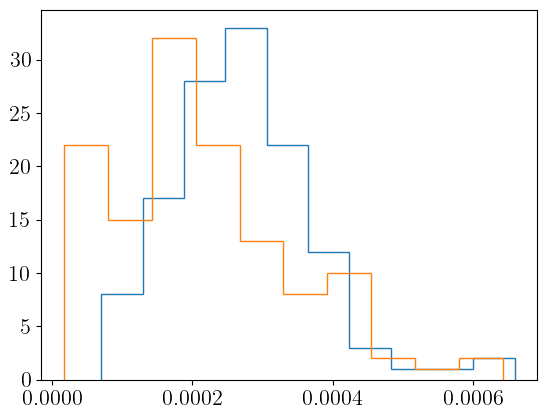

In [346]:
# t1/t2 errors
plt.hist([x.t1 for x in backend.qubit_properties(range(backend.num_qubits))], histtype='step')
plt.hist([x.t2 for x in backend.qubit_properties(range(backend.num_qubits))], histtype='step')

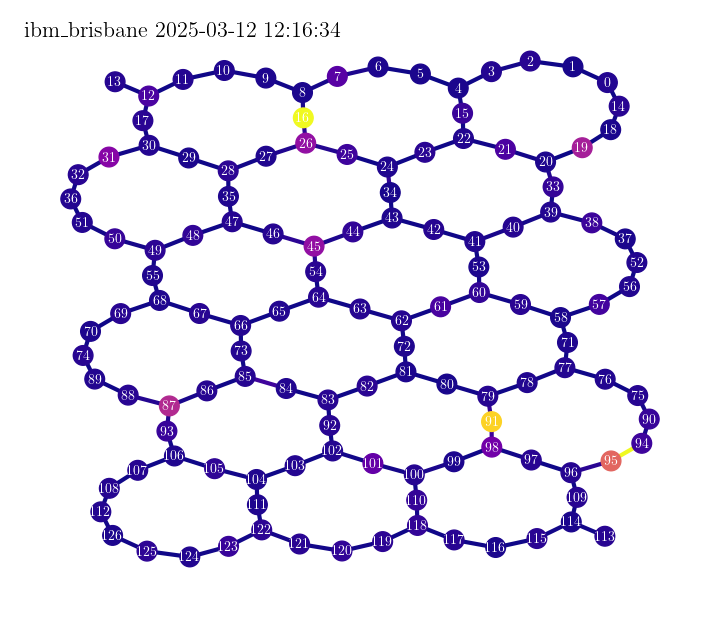

In [58]:
# draw machine layout; coloring based on gate errors
backend = service.backend('ibm_brisbane', instance='ibm-q/open/main')
qubit_errors = get_qubit_errors(backend)
G = nx.Graph()
G.add_edges_from(backend.coupling_map.get_edges())
node_errors  = np.array([ 4*qubit_errors[x]['rz'] + 6*qubit_errors[x]['sx'] for x in G.nodes ])
edge_errors  = np.array([ 3*qubit_errors[i,j]['ecr'] if (i,j) in qubit_errors else 3*qubit_errors[j,i]['ecr'] for (i,j) in G.edges ])

my_cmap = matplotlib.colormaps['plasma']
plt.figure(figsize=(7,6))
nx.draw_kamada_kawai(G, with_labels=True,
                     node_color=my_cmap(node_errors/max(node_errors)), node_size=200,
                     edge_color=my_cmap(edge_errors/max(edge_errors)), width=3,
                     font_color='white', font_size=10)
plt.annotate(backend.name + ' ' + backend.properties().gates[0].parameters[0].date.strftime("%Y-%m-%d %H:%M:%S"),
             (0.02,0.98), xycoords='axes fraction', ha='left', va='top')
plt.show()

### Optimized $u_{ij}$ operator

In [7]:
# Optimized u_{ij} operator
# -------------------------
# This introduces no global phase:
# u_ij(theta) = exp(-i theta/2 * (XX + YY + ZZ))
def u_ij(qc, p, q, theta, nonlocal_gate='ecr', connections=None, qubit_map=None):
    """
    Add the optimized u_{ij} = exp(-i theta/2 * (XX + YY + ZZ))
    operator to a quantum circuit.
    
    Parameters:
        qc:    the circuit
        p, q:  the qubits concerned
        theta: the rotation angle
        nonlocal_gate: which non-local gate to use ('ecr' or 'cx')
        connections:   A list of qubit pairs that are connected to one another,
                       including the direction. Will be used for checking that the
                       desired u_{ij} operation is possible on this hardware
                       and reorders qubits to ensure proper directionality
        qubit_map:     The map from logical to physical qubits. If not None,
                       connections is interpreted as a list of physical connections,
                       while p, q are interpreted as logical qubit indices.
    """
    
    if nonlocal_gate.upper() == 'ECR':
        # Reassign p, q to match ECR gate orientation 
        if connections is not None:
            if qubit_map is None:
                if (p, q) not in connections:
                    if (q, p) in connections:
                        p, q = q, p
                    else:
                        raise ValueError(f'Qubits {p} and {q} are not connected on the device.')
            else:
                if (qubit_map[p], qubit_map[q]) not in connections:
                    if (qubit_map[q], qubit_map[p]) in connections:
                        p, q = q, p
                    else:
                        raise ValueError(f'Qubits {qubit_map[p]} and {qubit_map[q]} are not connected on the device.')
        
        qc.rz(-np.pi/2, p)
        qc.sx(p)

        qc.rz(np.pi/2, q)
        qc.sx(q)
        qc.rz(-np.pi, q)
        #---------------------
        qc.ecr(p, q)
        #---------------------
        qc.sx(p)
        qc.rz(-theta, p)
        qc.sx(p)
        qc.rz(-np.pi/2, p)

        qc.sx(q)
        qc.rz(theta, q)
        qc.sx(q)
        qc.rz(-np.pi/2, q)
        #---------------------
        qc.ecr(p, q)
        #---------------------
        qc.sx(p)
        qc.rz(-theta, p)
        qc.sx(p)

        qc.rz(-np.pi/2, q)
        #---------------------
        qc.ecr(p, q)
        #---------------------
        qc.rz(-np.pi/2, p)
        qc.sx(p)
        qc.rz(np.pi/2, p)

        qc.rz(np.pi/2, q)
        qc.sx(q)
        qc.rz(-np.pi/2, q)
        
    elif nonlocal_gate.upper() == 'CX':
        raise ValueError('representation of u_{ij} in terms of CX not implemented yet.')
        
    elif nonlocal_gate.upper() == 'CZ':
        # Reassign p, q to match CZ gate orientation 
        if connections is not None:
            if qubit_map is None:
                if (p, q) not in connections:
                    if (q, p) in connections:
                        p, q = q, p
                    else:
                        raise ValueError(f'Qubits {p} and {q} are not connected on the device.')
            else:
                if (qubit_map[p], qubit_map[q]) not in connections:
                    if (qubit_map[q], qubit_map[p]) in connections:
                        p, q = q, p
                    else:
                        raise ValueError(f'Qubits {qubit_map[p]} and {qubit_map[q]} are not connected on the device.')


        qc.rz(-np.pi/2, p)
        qc.sx(p)
        qc.rz(np.pi/2, p)
        
        qc.sx(q)
        qc.rz(-np.pi, q)
        #---------------------
        qc.cz(p, q)
        #---------------------
        qc.x(p)
        qc.sx(p)
        qc.rz(-theta, p)
        qc.sx(p)

        qc.rz(-np.pi/2, q)
        qc.sx(q)
        qc.rz(-theta, q)
        #---------------------
        qc.cz(p, q)
        #---------------------
        qc.sx(p)
        qc.rz(-np.pi+theta, p)
        qc.sx(p)
        qc.rz(-np.pi/2, p)

        qc.rz(np.pi/2, q)
        qc.sx(q)
        #---------------------
        qc.cz(p, q)
        #---------------------
        qc.rz(-np.pi/2, p)
        qc.sx(p)
        qc.rz(-np.pi/2, p)

        qc.rz(np.pi/2, q)
        
    else:
        raise ValueError(f'invalid basis gate: {nonlocal_gate}')

In [813]:
# check that changing theta -> theta-np.pi/2 implements an extra SWAP
theta = 0.1
qc = qk.QuantumCircuit(2)
u_ij(qc, 0, 1, theta)
# qc.rxx(theta, 0, 1)
# qc.ryy(theta, 0, 1)
# qc.rzz(theta, 0, 1)
#display(qc.draw())
op1 = np.array(qk.quantum_info.Operator(qc))
op1.real[abs(op1.real)<1e-13]=0
op1.imag[abs(op1.imag)<1e-13]=0

qc = qk.QuantumCircuit(2)
u_ij(qc, 0, 1, theta-np.pi/2)
# qc.rxx(theta-np.pi/2, 0, 1)
# qc.ryy(theta-np.pi/2, 0, 1)
# qc.rzz(theta-np.pi/2, 0, 1)
#display(qc.draw())
op2 = np.array(qk.quantum_info.Operator(qc))
op2.real[abs(op2.real)<1e-13]=0
op2.imag[abs(op2.imag)<1e-13]=0

np.set_printoptions(precision=3)
print(op1)
print((np.array([[1,0,0,0],[0,0,1,0],[0,1,0,0],[0,0,0,1]]) @ op1) * np.exp(1j*np.pi/4))
print(op2)
np.set_printoptions(precision=8)

[[0.999-0.05j 0.   +0.j   0.   +0.j   0.   +0.j  ]
 [0.   +0.j   0.994+0.05j 0.005-0.1j  0.   +0.j  ]
 [0.   +0.j   0.005-0.1j  0.994+0.05j 0.   +0.j  ]
 [0.   +0.j   0.   +0.j   0.   +0.j   0.999-0.05j]]
[[0.742+0.671j 0.   +0.j    0.   +0.j    0.   +0.j   ]
 [0.   +0.j    0.074-0.067j 0.668+0.738j 0.   +0.j   ]
 [0.   +0.j    0.668+0.738j 0.074-0.067j 0.   +0.j   ]
 [0.   +0.j    0.   +0.j    0.   +0.j    0.742+0.671j]]
[[0.742+0.671j 0.   +0.j    0.   +0.j    0.   +0.j   ]
 [0.   +0.j    0.074-0.067j 0.668+0.738j 0.   +0.j   ]
 [0.   +0.j    0.668+0.738j 0.074-0.067j 0.   +0.j   ]
 [0.   +0.j    0.   +0.j    0.   +0.j    0.742+0.671j]]


In [963]:
# check behavior for theta=0
theta = 0.
qc = qk.QuantumCircuit(2)
u_ij(qc, 0, 1, theta-np.pi/2)
display(qk.transpile(qc,basis_gates=['x','sx','rz','ecr']).draw(idle_wires=False))
op1 = np.array(qk.quantum_info.Operator(qc)) * np.exp(-1j*np.pi/4)
op1.real[abs(op1.real)<1e-13]=0
op1.imag[abs(op1.imag)<1e-13]=0
print(op1)

global phase: π/2
     ┌──────────┐┌────┐          ┌──────┐┌─────────┐ ┌────┐          ┌──────┐»
q_0: ┤ Rz(-π/2) ├┤ √X ├──────────┤0     ├┤ Rz(π/2) ├─┤ √X ├──────────┤0     ├»
     ├─────────┬┘├────┤┌────────┐│  Ecr │├─────────┴┐├────┤┌────────┐│  Ecr │»
q_1: ┤ Rz(π/2) ├─┤ √X ├┤ Rz(-π) ├┤1     ├┤ Rz(-π/2) ├┤ √X ├┤ Rz(-π) ├┤1     ├»
     └─────────┘ └────┘└────────┘└──────┘└──────────┘└────┘└────────┘└──────┘»
«        ┌────┐   ┌─────────┐┌────┐┌──────┐┌──────────┐┌────┐┌─────────┐ 
«q_0: ───┤ √X ├───┤ Rz(π/2) ├┤ √X ├┤0     ├┤ Rz(-π/2) ├┤ √X ├┤ Rz(π/2) ├─
«     ┌──┴────┴──┐└─────────┘└────┘│  Ecr │├─────────┬┘├────┤├─────────┴┐
«q_1: ┤ Rz(-π/2) ├─────────────────┤1     ├┤ Rz(π/2) ├─┤ √X ├┤ Rz(-π/2) ├
«     └──────────┘                 └──────┘└─────────┘ └────┘└──────────┘

[[1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j]]


In [8]:
# Test our implementation of u_{ij}: first the conventional implementation ...
theta = 0.1
qc = qk.QuantumCircuit(2)
qc.rxx(theta, 0, 1)
qc.ryy(theta, 0, 1)
qc.rzz(theta, 0, 1)

my_map = [0,1]
backend = qkrun.fake_provider.FakeSherbrooke()
isa_qc  = qk.transpile(qc, backend, optimization_level=3, initial_layout=my_map)
display(isa_qc.draw(idle_wires=False, fold=14600, plot_barriers=True))

# ... then our implementation, which should be identical
qc = qk.QuantumCircuit(2)
u_ij(qc, 0, 1, theta, qubit_map=my_map, connections=backend.coupling_map.get_edges()[:])
isa_qc = qk.transpile(qc, backend, optimization_level=0, initial_layout=my_map)
display(isa_qc.draw(idle_wires=False, fold=14600, plot_barriers=True))

global phase: 0
         ┌─────────┐ ┌────┐┌────────┐┌──────┐┌────┐┌─────────┐ ┌────┐┌──────────┐┌──────┐┌──────────┐                  ┌──────┐┌─────────┐ ┌────┐┌──────────┐
q_0 -> 0 ┤ Rz(π/2) ├─┤ √X ├┤ Rz(-π) ├┤1     ├┤ √X ├┤ Rz(0.1) ├─┤ √X ├┤ Rz(-π/2) ├┤1     ├┤ Rz(-π/2) ├──────────────────┤1     ├┤ Rz(π/2) ├─┤ √X ├┤ Rz(-π/2) ├
         ├─────────┴┐├────┤└────────┘│  Ecr │├────┤├─────────┴┐├────┤├──────────┤│  Ecr │└──┬────┬──┘┌──────────┐┌────┐│  Ecr │├─────────┴┐├────┤├─────────┬┘
q_1 -> 1 ┤ Rz(-π/2) ├┤ √X ├──────────┤0     ├┤ √X ├┤ Rz(-0.1) ├┤ √X ├┤ Rz(-π/2) ├┤0     ├───┤ √X ├───┤ Rz(-0.1) ├┤ √X ├┤0     ├┤ Rz(-π/2) ├┤ √X ├┤ Rz(π/2) ├─
         └──────────┘└────┘          └──────┘└────┘└──────────┘└────┘└──────────┘└──────┘   └────┘   └──────────┘└────┘└──────┘└──────────┘└────┘└─────────┘

┌─────────┐ ┌────┐┌────────┐┌──────┐┌────┐┌─────────┐ ┌────┐┌──────────┐┌──────┐┌──────────┐                  ┌──────┐┌─────────┐ ┌────┐┌──────────┐
q_0 -> 0 ┤ Rz(π/2) ├─┤ √X ├┤ Rz(-π) ├┤1     ├┤ √X ├┤ Rz(0.1) ├─┤ √X ├┤ Rz(-π/2) ├┤1     ├┤ Rz(-π/2) ├──────────────────┤1     ├┤ Rz(π/2) ├─┤ √X ├┤ Rz(-π/2) ├
         ├─────────┴┐├────┤└────────┘│  Ecr │├────┤├─────────┴┐├────┤├──────────┤│  Ecr │└──┬────┬──┘┌──────────┐┌────┐│  Ecr │├─────────┴┐├────┤├─────────┬┘
q_1 -> 1 ┤ Rz(-π/2) ├┤ √X ├──────────┤0     ├┤ √X ├┤ Rz(-0.1) ├┤ √X ├┤ Rz(-π/2) ├┤0     ├───┤ √X ├───┤ Rz(-0.1) ├┤ √X ├┤0     ├┤ Rz(-π/2) ├┤ √X ├┤ Rz(π/2) ├─
         └──────────┘└────┘          └──────┘└────┘└──────────┘└────┘└──────────┘└──────┘   └────┘   └──────────┘└────┘└──────┘└──────────┘└────┘└─────────┘

### Implementation of Logical Qubits in the Bell Basis

In [8]:
# Elementary gates in the Bell basis, where each logical qubit is encoded
# in the two Bell states of two physical qubits.

def rx_bell(qc, theta, p):
    """
    Add a logical RX gate to a quatum circuit in the Bell basis.
    
    Parameters:
        qc:    the circuit
        theta: the rotation angle
        p:     the (logical) qubit concerned. It is assued that the
               corresponding physical qubits are 2p, 2p+1.
    """
    qc.rz(theta, 2*p)
    
def rz_bell(qc, theta, p):
    """
    Add a logical RZ gate to a quatum circuit in the Bell basis.
    
    Parameters:
        qc:    the circuit
        theta: the rotation angle
        p:     the (logical) qubit concerned. It is assued that the
               corresponding physical qubits are 2p, 2p+1.
    """
    qc.rxx(theta, 2*p, 2*p+1)

def x_bell(qc, p):
    """
    Add a logical X gate to a quatum circuit in the Bell basis.
    
    Parameters:
        qc:    the circuit
        p:     the (logical) qubit concerned. It is assued that the
               corresponding physical qubits are 2p, 2p+1.
    """
    qc.z(2*p)

def sx_bell(qc, p):
    """
    Add a logical SX gate to a quatum circuit in the Bell basis.
    
    Parameters:
        qc:    the circuit
        p:     the (logical) qubit concerned. It is assued that the
               corresponding physical qubits are 2p, 2p+1.
    """
    qc.rz(np.pi/2, 2*p)

def rxx_bell(qc, theta, p, q):
    """
    Add a logical RXX gate to a quatum circuit in the Bell basis.
    
    Parameters:
        qc:    the circuit
        theta: the rotation angle
        p, q:  the (logical) qubits concerned. It is assued that the
               corresponding physical qubits are 2p, 2p+1, 2q, 2q+2.
    """
    qc.rzz(theta, 2*p, 2*q)
    
def ryy_bell(qc, theta, p, q):
    """
    Add a logical RYY gate to a quatum circuit in the Bell basis.
    
    Parameters:
        qc:    the circuit
        theta: the rotation angle
        p, q:  the (logical) qubits concerned. It is assued that the
               corresponding physical qubits are 2p, 2p+1, 2q, 2q+2.
    """
    qc.sdg(2*p)           # Basis change: Y->Z and X->Z
    qc.h(2*p)             # Y -> Z (qubit 0)
    qc.h(2*p+1)           # X -> Z (qubit 1)
    qc.sdg(2*q)
    qc.h(2*q)             # Y -> Z (qubit 2)
    qc.h(2*q+1)           # X -> Z (qubit 3)
    qc.cx(2*p, 2*p+1)     # CNOT cascade to encode parity on qubit 3
    qc.cx(2*p+1, 2*q)
    qc.cx(2*q, 2*q+1)
    qc.rz(theta, 2*q+1)   # Apply central RZ rotation
    qc.cx(2*q, 2*q+1)     # Reverse CNOT cascade
    qc.cx(2*p+1, 2*q)
    qc.cx(2*p, 2*p+1)
    qc.h(2*q+1)           # Reverse basis change
    qc.h(2*q)
    qc.s(2*q)
    qc.h(2*p+1)
    qc.h(2*p)
    qc.s(2*p)

def rzz_bell(qc, theta, p, q):
    """
    Add a logical RZZ gate to a quatum circuit in the Bell basis.
    
    Parameters:
        qc:    the circuit
        theta: the rotation angle
        p, q:  the (logical) qubits concerned. It is assued that the
               corresponding physical qubits are 2p, 2p+1, 2q, 2q+2.
    """
    qc.h([2*p, 2*p+1, 2*q, 2*q+1])
    qc.cx(2*p, 2*p+1)              # CNOT cascade to gather parity onto qubit 3
    qc.cx(2*p+1, 2*q)
    qc.cx(2*q, 2*q+1)
    qc.rz(theta, 2*q+1)            # Apply RZ rotation (central gate)
    qc.cx(2*q, 2*q+1)              # Reverse CNOT cascade
    qc.cx(2*p+1, 2*q)
    qc.cx(2*p, 2*p+1)
    qc.h([2*p, 2*p+1, 2*q, 2*q+1]) # Revert Hadamard basis change

def cz_bell(qc, p, q):
    """
    Add a logical CZ gate to a quatum circuit in the Bell basis.
    
    Parameters:
        qc:    the circuit
        p, q:  the (logical) qubits concerned. It is assued that the
               corresponding physical qubits are 2p, 2p+1, 2q, 2q+2.
    """

    # RXX(-π/2) between (a1,a2) and (b1,b2)
    qc.rxx(-np.pi/2, 2*p, 2*p+1)
    qc.rxx(-np.pi/2, 2*q, 2*q+1)

    # Add logical RZZ gate at π/2 (X.X.X.X interaction):
    rzz_bell(qc, np.pi/2, p, q)

# ------------------------------------------------------------------------

def u_ij_bell(qc, theta, p, q, nonlocal_gate='cz', connections=None, qubit_map=None):
    """
    Add the optimized u_{ij} = exp(-i theta/2 * (XX + YY + ZZ))
    operator to a quantum circuit, assuming that each logical qubit
    is encoded in the two Bell states of two physical qubits
    
    Parameters:
        qc:    the circuit
        p, q:  the (logical) qubits concerned. It is assued that the
               corresponding physical qubits are 2p, 2p+1, 2q, 2q+1.
        theta: the rotation angle
        nonlocal_gate: which non-local gate to use ('ecr' or 'cx')
        connections:   A list of qubit pairs that are connected to one another,
                       including the direction. Will be used for checking that the
                       desired u_{ij} operation is possible on this hardware
                       and reorders qubits to ensure proper directionality
        qubit_map:     The map from logical to physical qubits. If not None,
                       connections is interpreted as a list of physical connections,
                       while p, q are interpreted as logical qubit indices.
    """
    
    if nonlocal_gate.upper() == 'ECR':
        raise ValueError('representation of u_{ij} in terms of ECR not implemented yet.')
        
    elif nonlocal_gate.upper() == 'CX':
        raise ValueError('representation of u_{ij} in terms of CX not implemented yet.')
        
    elif nonlocal_gate.upper() == 'CZ':
        # Reassign p, q to match CZ gate orientation 
        if connections is not None:
            if qubit_map is None:
                if (p, q) not in connections:
                    if (q, p) in connections:
                        p, q = q, p
                    else:
                        raise ValueError(f'Qubits {p} and {q} are not connected on the device.')
            else:
                if (qubit_map[p], qubit_map[q]) not in connections:
                    if (qubit_map[q], qubit_map[p]) in connections:
                        p, q = q, p
                    else:
                        raise ValueError(f'Qubits {qubit_map[p]} and {qubit_map[q]} are not connected on the device.')

        rz_bell(qc, -np.pi/2, p)
        sx_bell(qc, p)
        rz_bell(qc, np.pi/2, p)
        
        sx_bell(qc, q)
        rz_bell(qc, -np.pi, q)
        #---------------------
        cz_bell(qc, p, q)
        #---------------------
        x_bell(qc, p)
        sx_bell(qc, p)
        rz_bell(qc, -theta, p)
        sx_bell(qc, p)

        rz_bell(qc, -np.pi/2, q)
        sx_bell(qc, q)
        rz_bell(qc, -theta, q)
        #---------------------
        cz_bell(qc, p, q)
        #---------------------
        sx_bell(qc, p)
        rz_bell(qc, -np.pi+theta, p)
        sx_bell(qc, p)
        rz_bell(qc, -np.pi/2, p)

        rz_bell(qc, np.pi/2, q)
        sx_bell(qc, q)
        #---------------------
        cz_bell(qc, p, q)
        #---------------------
        rz_bell(qc, -np.pi/2, p)
        sx_bell(qc, p)
        rz_bell(qc, -np.pi/2, p)

        rz_bell(qc, np.pi/2, q)
    else:
        raise ValueError(f'invalid basis gate: {nonlocal_gate}')

In [473]:
# FIXME REMOVE
qc = qk.QuantumCircuit(2)
u_ij(qc, 0, 1, np.pi/7, nonlocal_gate='ecr')
u_ij(qc, 0, 1,-np.pi/7, nonlocal_gate='cz')
M = qk.quantum_info.Operator(qc).to_matrix()
M = M * np.exp(-1j*np.angle(M[0,0]))
Mr = np.real(M)
Mi = np.imag(M)
np.where(np.abs(Mr)>1e-10, Mr, 0) + 1j * np.where(np.abs(Mi)>1e-10, Mi, 0)

array([[1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j]])

In [93]:
# FIXME REMOVE
theta = 0.7
p=0
q=1
qc = qk.QuantumCircuit(4)
qc.h([2*p, 2*p+1, 2*q, 2*q+1])
qc.cx(2*p, 2*p+1)              # CNOT cascade to gather parity onto qubit 3
qc.cx(2*p+1, 2*q)
qc.cx(2*q, 2*q+1)
qc.rz(theta, 2*q+1)            # Apply RZ rotation (central gate)
qc.cx(2*q, 2*q+1)              # Reverse CNOT cascade
qc.cx(2*p+1, 2*q)
qc.cx(2*p, 2*p+1)
qc.h([2*p, 2*p+1, 2*q, 2*q+1]) # Revert Hadamard basis change

qc.h([2*p, 2*p+1, 2*q, 2*q+1])
qc.cx(2*p, 2*p+1)              # CNOT cascade to gather parity onto qubit 3
qc.cx(2*q+1, 2*q)
qc.cx(2*p+1, 2*q)
qc.rz(-theta, 2*q+1)            # Apply RZ rotation (central gate)
qc.cx(2*p+1, 2*q)
qc.cx(2*q+1, 2*q)              # Reverse CNOT cascade
qc.cx(2*p, 2*p+1)
qc.h([2*p, 2*p+1, 2*q, 2*q+1]) # Revert Hadamard basis change


# rxx_bell(qc, np.pi/2, p, q)
# ryy_bell(qc, np.pi/2, p, q)
# rzz_bell(qc, np.pi/2, p, q)
# u_ij_bell(qc, theta, p, q, nonlocal_gate='cz')

isa_qc = qk.transpile(qc, basis_gates=backend.basis_gates, optimization_level=2)
# isa_qc = qk.transpile(qc, backend=backend, optimization_level=2)
print(sum(1 for instr in isa_qc.data if len(instr.qubits) >= 2))
isa_qc.draw(idle_wires=False)

6


global phase: π
     ┌─────────┐┌────┐  ┌───────┐                                      »
q_0: ┤ Rz(π/2) ├┤ √X ├──┤ Rz(π) ├─────■────────────────────────────────»
     └─────────┘└────┘  └───────┘     │   ┌─────────┐┌────┐┌───────┐   »
q_1: ─────────────────────────────────■───┤ Rz(π/2) ├┤ √X ├┤ Rz(π) ├─■─»
                                          └─────────┘└────┘└───────┘ │ »
q_2: ────────────────────────────────────────────────────────────────■─»
     ┌─────────┐┌────┐┌────────────┐┌────┐                             »
q_3: ┤ Rz(π/2) ├┤ √X ├┤ Rz(1.6458) ├┤ √X ├─────────────────────────────»
     └─────────┘└────┘└────────────┘└────┘                             »
«                                                                      »
«q_0: ─────────────────────────────────────────────────────────────────»
«                                                                      »
«q_1: ─────────────────────────────────────────────────────────────────»
«     ┌─────────┐┌────┐┌────────┐   ┌───┐   ┌────────┐           ┌────┐»
«q_2: ┤ Rz(π/2) ├┤ √X ├┤ Rz(-π) ├─■─┤ X ├───┤ Rz(-π) ├─────────■─┤ √X ├»
«     └─────────┘└────┘└────────┘ │ ├───┴┐┌─┴────────┴─┐┌────┐ │ ├────┤»
«q_3: ────────────────────────────■─┤ √X ├┤ Rz(2.4416) ├┤ √X ├─■─┤ √X ├»
«                                   └────┘└────────────┘└────┘   └────┘»
«                                                   ┌────┐┌─────────┐
«q_0: ────────────────────────────────────────────■─┤ √X ├┤ Rz(π/2) ├
«                            ┌────┐   ┌─────────┐ │ └────┘└─────────┘
«q_1: ────────────────■──────┤ √X ├───┤ Rz(π/2) ├─■──────────────────
«      ┌──────────┐   │      └────┘   └─────────┘                    
«q_2: ─┤ Rz(-π/2) ├───■──────────────────────────────────────────────
«     ┌┴──────────┴┐┌────┐┌──────────┐                               
«q_3: ┤ Rz(2.3458) ├┤ √X ├┤ Rz(-π/2) ├───────────────────────────────
«     └────────────┘└────┘└──────────┘

In [94]:
qk.quantum_info.Operator(qc).to_matrix()

array([[0.88242109+0.j        , 0.        +0.j        ,
        0.        +0.j        , 0.        +0.j        ,
        0.        +0.j        , 0.        +0.j        ,
        0.        +0.j        , 0.11757891+0.j        ,
        0.        +0.32210884j, 0.        +0.j        ,
        0.        +0.j        , 0.        +0.j        ,
        0.        +0.j        , 0.        +0.j        ,
        0.        +0.j        , 0.        -0.32210884j],
       [0.        +0.j        , 0.88242109+0.j        ,
        0.        +0.j        , 0.        +0.j        ,
        0.        +0.j        , 0.        +0.j        ,
        0.11757891+0.j        , 0.        +0.j        ,
        0.        +0.j        , 0.        +0.32210884j,
        0.        +0.j        , 0.        +0.j        ,
        0.        +0.j        , 0.        +0.j        ,
        0.        -0.32210884j, 0.        +0.j        ],
       [0.        +0.j        , 0.        +0.j        ,
        0.88242109+0.j        , 0.        +0.j

In [268]:
# Verification of our Implementation of Operation ins the Bell Basis
# ------------------------------------------------------------------

theta = 0.7

# Normal circuit
# --------------
qc = qk.QuantumCircuit(2)
u_ij(qc, 0, 1, theta, nonlocal_gate='cz')
sv1 = qk.quantum_info.Statevector(qc)


# Circuit with Bell encoding
# --------------------------
qc = qk.QuantumCircuit(4)

# Bell encoding
qc.h(0)
qc.cx(0, 1)
qc.h(2)
qc.cx(2, 3)

u_ij_bell(qc, theta, 0, 1, nonlocal_gate='cz')

# Bell decoding
qc.cx(2, 3)
qc.h(2)
qc.cx(0, 1)
qc.h(0)
sv2 = qk.quantum_info.Statevector(qc)

def print_statevector(sv):
    """Print the statevector in a readable format."""
    M = np.array(sv)
    M = M * np.exp(-1j*np.angle(M[0]))
    Mr = np.real(M)
    Mi = np.imag(M)
    print(np.where(np.abs(Mr)>1e-10, Mr, 0) + 1j * np.where(np.abs(Mi)>1e-10, Mi, 0))
print_statevector(sv1)
print_statevector(sv2)


[1.+0.j 0.+0.j 0.+0.j 0.+0.j]
[1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]


### Remote Backend on lxplus

In [9]:
from qiskit.providers.backend import BackendV2
from qiskit.providers.options import Options
from qiskit.providers.models import BackendConfiguration
from qiskit.transpiler import Target, InstructionProperties
from qiskit.circuit import QuantumCircuit, Instruction
import qiskit.qasm2 as qasm
import requests

class RemoteSimulatorBackend(BackendV2):
    """A custom Qiskit backend for a remote quantum simulator accessed via HTTP.
       A tunnel to the backend should opened first via
           ssh -fNL 8080:localhost:8080 <host>
    """

    def __init__(self, url="http://localhost:8080/run"):
        """Initialize the remote backend with target properties."""
        super().__init__(name="remote_simulator")
        self.url = url
        self._target = self._build_target()

    def _build_target(self):
        """Builds the target, which describes the supported instructions and properties."""
        n_qubits = 30
        target = Target(num_qubits=n_qubits)

        # Define supported quantum instructions
        u_gate  = Instruction(name="u",  num_qubits=1, num_clbits=0, params=["theta", "phi", "lambda"])
        id_gate = Instruction(name="id", num_qubits=1, num_clbits=0, params=[])
        measure_gate = Instruction(name="measure", num_qubits=1, num_clbits=1, params=[])
        cx_gate = Instruction(name="cx", num_qubits=2, num_clbits=0, params=[])
        ecr_gate = Instruction(name="ecr", num_qubits=2, num_clbits=0, params=[])

        # Assign instructions to qubits
        target.add_instruction(
            u_gate,
            properties={ (q,): InstructionProperties(duration=0, error=0) for q in range(n_qubits) }
        )
        target.add_instruction(
            id_gate,
            properties={ (q,): InstructionProperties(duration=0, error=0) for q in range(n_qubits) }
        )
        target.add_instruction(
            measure_gate,
            properties={ (q,): InstructionProperties(duration=0, error=0) for q in range(n_qubits)}
        )
        target.add_instruction(
            cx_gate,
            properties={ (q1, q2): InstructionProperties(duration=0, error=0) for q1 in range(n_qubits) for q2 in range(n_qubits) if q1 != q2}
        )
        target.add_instruction(
            ecr_gate,
            properties={ (q1, q2): InstructionProperties(duration=0, error=0) for q1 in range(n_qubits) for q2 in range(n_qubits) if q1 != q2}
        )

        return target

    @property
    def target(self) -> Target:
        """Return the target description of the backend."""
        return self._target

    @property
    def num_qubits(self) -> int:
        """Return the number of qubits supported."""
        return 100  # Adjust as needed

    @property
    def is_simulator(self) -> bool:
        """Indicate that this is a simulator backend."""
        return True

    @property
    def max_circuits(self) -> int:
        """Return the maximum number of circuits the backend can execute in one job."""
        return None  # No explicit limit

    @classmethod
    def _default_options(cls) -> Options:
        """Define default backend options."""
        return Options(shots=1024)
    
    def configuration(self):
        """Returns a configuration object similar to IBM backends."""
        return BackendConfiguration(
            backend_name = self.name,
            backend_version = "1.0",
            n_qubits = self.num_qubits,
            basis_gates = ["u", "cx", "id", "rzx", "ecr"],  # Gates supported
            gates = [],
            local = False,
            simulator = True,
            conditional = False,
            open_pulse = False,
            memory = False,
            max_shots = 8192,
            coupling_map = [[i, j] for i in range(self.num_qubits) for j in range(self.num_qubits) if i != j],
        )

    def run(self, run_input, **options):
        """
        Execute a circuit on the remote simulator.

        Args:
            run_input (QuantumCircuit or list): The quantum circuit(s) to execute.
            options: Additional execution options.

        Returns:
            dict: The execution results.
        """
        if isinstance(run_input, QuantumCircuit):
            circuits = [run_input]
        else:
            circuits = run_input

        results = []
        for circuit in circuits:
            data = {"qasm": qasm.dumps(circuit), "shots": options.get("shots", 1024)}
            response = requests.post(self.url, json=data)
            if response.status_code == 200:
                results.append(response.json())
            else:
                raise RuntimeError(f"Error from server: {response.json().get('error', 'Unknown error')}")

        return results if len(results) > 1 else results[0]


/var/folders/mn/vwbz05810sq7zq664_pw0ll40000gn/T/ipykernel_73615/4280902099.py:3: DeprecationWarning: qiskit.providers.models is deprecated since Qiskit 1.2 and will be removed in Qiskit 2.0. With the removal of Qobj, there is no need for these schema-conformant objects. If you still need to use them, it could be because you are using a BackendV1, which is also deprecated in favor of BackendV2.
  from qiskit.providers.models import BackendConfiguration


In [115]:
# Example usage
backend = RemoteSimulatorBackend()
qc = QuantumCircuit(3,3)
qc.h(0)
qc.cx(0, 1)
qc.rxx(0.1, 0, 1)
qc.measure([0,1,2],[0,1,2])
qc = qk.transpile(qc, backend=backend, optimization_level=0)
#qc = qk.transpile(qc, backend=backend)
result = backend.run(qc)
print(result)


{'counts': {'000': 520, '011': 504}}


### Access To Backends

In [10]:
def get_backend(backend_name):
    """create a backend of the given name.

       Arguments:
           backend_name: the name of the backend to create. Can be one of the following
                           fake_sherbrooke
                           fake_brisbane
                           fake_torino
                           aer - noiseless AER simulator
                           aer_noisy or noisy_aer - AER simulator with custom noise model
                           aer_chatgpt - AER simulator with noise model proposed by ChatGPT
                           remote - connect to a remote backend
                           MPS - noiseless AER matrix product state simulator
                           ibm_least_busy - the least busy QPU available
                           ibm_XXX - the corresponding real QPU
    """
    
    # Open plan (10m free per month)
    global service
    service = qkrun.QiskitRuntimeService(name='ibm-quantum-qti', instance='cern/neutrinooscillat/joachimproj') # quantum.ibm.com - CERN QTI access
    #service = qkrun.QiskitRuntimeService(name='ibm-quantum-cern', instance='ibm-q/open/main') # quantum.ibm.com - old
    #service = qkrun.QiskitRuntimeService(name='ibm-quantum-gmail', instance='ibm-q/open/main')  # quantum.ibm.com - old
    #service = qkrun.QiskitRuntimeService(name = 'ibm-cloud-cern') # full account info in ~/.qiskit/qiskit-ibm.json
    #service = qkrun.QiskitRuntimeService(name = 'ibm-cloud-gmail')
    #service = qkrun.QiskitRuntimeService(name = 'ibm-cloud-jgu')
    
    # Lite instance (simulators only)
    #service = qkrun.QiskitRuntimeService(channel='ibm_cloud',
    #                                    instance='crn:v1:bluemix:public:quantum-computing:us-east:a/f84bb16f3bd7413f81c8fdf20f2c69ab:4410365c-6659-41b1-9e7e-9301f54745b8::')
    
    # pay-as-you-go instance
    #raise ValueError('You are about to run on a paid plan. Make sure this is intentional')
    # service = qkrun.QiskitRuntimeService(channel='ibm_cloud',
    #                                      instance='crn:v1:bluemix:public:quantum-computing:us-east:a/f84bb16f3bd7413f81c8fdf20f2c69ab:fe205cb4-94d0-40dc-aabf-fbe1c238d1ab::',
    #                                      channel_strategy='q-ctrl')

    # IBM fake backends mimicking a real machine
    if backend_name == 'fake_sherbrooke':
        backend = qkrun.fake_provider.FakeSherbrooke()
    elif backend_name == 'fake_brisbane':
        backend = qkrun.fake_provider.FakeBrisbane()
    elif backend_name == 'fake_torino':
        backend = qkrun.fake_provider.FakeTorino()

    # noiseless AER backend
    elif backend_name == 'aer':
        backend = aer.Aer.get_backend('aer_simulator')
        if 'GPU' in backend.available_devices():
            backend.set_options(device='GPU')

    # AER simulator with custom noise model
    elif backend_name == 'aer_noisy' or backend_name == 'noisy_aer':
        noise_model = aer.noise.NoiseModel()
        #noise_model.add_all_qubit_quantum_error(aer.noise.depolarizing_error(0.01,1), ['rx','ry','rz','x']) # error for 1-qubit gates
        #noise_model.add_all_qubit_quantum_error(aer.noise.depolarizing_error(0.1,2), ['rxx','ryy','rzz'])   # error for 2-qubit gates
        #noise_model.add_all_qubit_quantum_error(aer.noise.thermal_relaxation_error(50e-6, 70e-6, 0.01), 'measure') # thermal relaxation in measurement
        #noise_model.add_all_qubit_quantum_error(aer.noise.phase_damping_error(0.02), ['rx','ry','rz','h','s','t','u1','u2','u3'])
        backend = aer.AerSimulator(noise_model=noise_model)
        if 'GPU' in backend.available_devices():
            backend.set_options(device='GPU')

    # AER simulator with noise model proposed by ChatGPT
    elif backend_name == 'aer_chatgpt':
        # noise model proposed by ChatGPT
        from concurrent.futures import ThreadPoolExecutor
        T1 = 100e3  # 100 µs                 # coherence times (T1, T2)
        T2 = 80e3   # 80 µs
        gate_time_1q = 50e-9  # 50 ns
        gate_time_2q = 250e-9  # 250 ns
        meas_time = 400e-9  # 400 ns
        single_qubit_error = 0.001  # 0.1%   # depolarizing error rates
        two_qubit_error = 0.01  # 1%
        single_qubit_error=0.01 # FIXME FIXME FIXME
        two_qubit_error=0.03 # FIXME FIXME FIXME
        readout_error_matrix = [[0.98, 0.02], [0.05, 0.95]]  # P(meas 1|0) = 2%, P(meas 0|1) = 5%   # measurement readout error (bit-flip probabilities)
        
        noise_model = aer.noise.NoiseModel()
        single_qubit_relaxation = aer.noise.thermal_relaxation_error(T1, T2, gate_time_1q)
        single_qubit_depol = aer.noise.depolarizing_error(single_qubit_error, 1)
        single_qubit_error = single_qubit_relaxation.compose(single_qubit_depol)
        two_qubit_relaxation = aer.noise.thermal_relaxation_error(T1, T2, gate_time_2q).tensor(aer.noise.thermal_relaxation_error(T1, T2, gate_time_2q))
        two_qubit_depol = aer.noise.depolarizing_error(two_qubit_error, 2)
        two_qubit_error = two_qubit_relaxation.compose(two_qubit_depol)
        readout_error = aer.noise.ReadoutError(readout_error_matrix)
        noise_model.add_all_qubit_quantum_error(single_qubit_error, ['u1', 'u2', 'u3'])  # Single-qubit gates
        noise_model.add_all_qubit_quantum_error(two_qubit_error, ['cx','ecr'])  # CNOT gate
        noise_model.add_all_qubit_readout_error(readout_error)
        backend = aer.AerSimulator(noise_model=noise_model)
        if 'GPU' in backend.available_devices():
            backend.set_options(device='GPU')

    # remote backend
    elif backend_name == 'remote':
        # (open SSH tunnel to the backend via ssh -fNL 8080:localhost:8080 <host>)
        backend = RemoteSimulatorBackend()
        opt_level = 0 # for some reason, the LxPlus backend breaks the optimizer

    # tensor network
    elif backend_name == 'MPS' or backend_name == 'mps':
        backend = aer.AerSimulator(method='matrix_product_state')
        if 'GPU' in backend.available_devices():
            backend.set_options(device='GPU')

    # IBM quantum hardware
    elif backend_name == 'ibm_least_busy':
        backend = service.least_busy(simulator=False, operational=True)
    elif re.match(r'ibm_[a-z]+', backend_name):
        backend = service.backend(backend_name)
    
    else:
        raise ValueError(f'Unknown backend: {backend_name}')

    return backend

## Neutrino Oscillations

### Raffelt–Sigl Polarization-Vector Approach to Collective Oscillations

In [11]:
def P_osc_RS(t_table, theta, Delta, lam, J, initial_flavors=None, alpha=None):
    """Compute an oscillation probability for collective oscillations
       in the Raffelt-Sigl 2-flavor polarization vector approach.
       
       Arguments:
           t_table: list of time steps
           theta:   vacuum mixing angle
           Delta:   vector of vacuum oscillation frequencies for each mode
           lam:     strength of ordinary matter effect
           J:       matrix of coupling strengths between modes
           initial_flavors: an array of length n_modes indicating the initial flavor of
                    each neutrino ('e', 'x', or 'a'). If any neutrino has flavor 'a',
                    an angle alpha must be specified.
           alpha:   initial superposition for neutrinos in flavor 'a'
    """
    
    n_modes = J.shape[0]
    
    # definition of the vectors B, D, L, P, H, e3m in the notation of
    # https://arxiv.org/abs/1001.2799 (Duan, Fuller Qian)
    u   = np.array([[np.cos(theta), np.sin(theta)], [-np.sin(theta), np.cos(theta)]])
    b   = 0.5 * np.diag([-1,1])
    b   = u @ b @ u.T
    l   = np.diag([1,0])
    
    Ee  = np.array([0, 0,  1.])
    Emu = np.array([0, 0, -1.])
    B   = np.real(np.array([np.trace(b@sigma_1), np.trace(b@sigma_2), np.trace(b@sigma_3)]))
    L   = np.real(np.array([np.trace(l@sigma_1), np.trace(l@sigma_2), np.trace(l@sigma_3)]))
    
    ini_state = np.where(Delta>0, Ee[:,None], Emu[:,None])
    if initial_flavors is not None:
        for f in initial_flavors:
            if f not in ['e','x','mu','a']:
                raise ValueError(f'Unknown flavor: {f}')
            if f == 'a' and alpha is None:
                raise ValueError('Initial superposition for neutrinos in flavor "a" not specified')
        ini_state[:,initial_flavors=='e']  = Ee[:,None]
        ini_state[:,initial_flavors=='x']  = Emu[:,None]
        ini_state[:,initial_flavors=='mu'] = Emu[:,None]
        ini_state[:,initial_flavors=='a']  = np.array([np.sin(2*alpha), 0, np.cos(2*alpha)])[:,None]
        # FIXME I'm not sure this is correct
        
    def f(t, P):
        """right-hand side of the evolution equation for the polarization vector P at time t."""
        
        res = np.zeros(3*n_modes)
        PP  = np.reshape(P, (n_modes,3)).T
        for k in range(n_modes):
            res[3*k:3*k+3] = np.cross(Delta[k]*B + lam*L + PP@J[k,:], PP[:,k])
        return res

    return integ.solve_ivp(f, (t_table[0],t_table[-1]), ini_state.T.flatten(), t_eval=t_table)

def P_osc_RS_bipolar(t_table, theta, Delta, lam, J, eps=0.1):
    """Compute an oscillation probability for collective oscillations
       in the Raffelt-Sigl 2-flavor polarization vector approach for
       a bipolar system.
       
       Arguments:
           t_table: list of time steps
           theta:   vacuum mixing angle
           Delta:   vector of vacuum oscillation frequencies for each mode
           lam:     strength of ordinary matter effect
           J:       matrix of coupling strengths between modes
           eps:     asymmetry between neutrinos and anti-neutrinos"""
    
    n_modes = J.shape[0]
    
    # definition of the vectors B, D, L, P, H, e3m in the notation of
    # https://arxiv.org/abs/1001.2799 (Duan, Fuller, Qian)
    u   = np.array([[np.cos(theta), np.sin(theta)], [-np.sin(theta), np.cos(theta)]])
    b   = 0.5 * np.diag([-1,1])
    b   = u @ b @ u.T
    l   = np.diag([1,0])
    
    Ee  = np.array([0, 0,  1+eps])
    Emu = np.array([0, 0, -1+eps])
    B   = np.array([np.trace(b@sigma_1), np.trace(b@sigma_2), np.trace(b@sigma_3)])
    L   = np.array([np.trace(l@sigma_1), np.trace(l@sigma_2), np.trace(l@sigma_3)])
    
    def f(t, P):
        """right-hand side of the evolution equation for the polarization vector P at time t."""
        
        res = (0+0j)*np.zeros(3*n_modes)
        PP  = np.reshape(P, (n_modes,3)).T
        for k in range(n_modes):
            s  = 1 if k < n_modes//2 else -1
            res[3*k:3*k+3] = np.cross(s*Delta[k]*B + lam*L + PP@J[k,:], PP[:,k])
        return res
            
    E0 = np.concatenate((np.tile(Ee,n_modes//2), np.tile(Emu,n_modes//2)))
    return integ.solve_ivp(f, (t_table[0],t_table[-1]), E0, t_eval=t_table)    


/Users/jkopp/.pyenv/versions/3.9.0/lib/python3.9/site-packages/scipy/integrate/_ivp/base.py:23: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(fun(t, y), dtype=dtype)


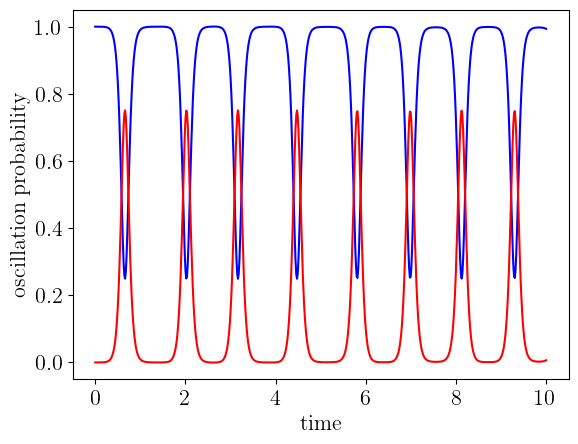

In [118]:
# test for bipolar oscillations
n_modes    = 2
n_nu       = 1
n_nubar    = 1
nu_mask    = np.array([True] *n_nu + [False]*n_nubar)
nubar_mask = np.array([False]*n_nu + [True] *n_nubar)
dmsq       = -1.0
E          = 0.1
J          = 10*np.ones((n_modes,n_modes))
#J[np.ix_(nu_mask,nubar_mask)] *= -1
#J[np.ix_(nubar_mask,nu_mask)] *= -1
t_table    = np.linspace(0,10,20*31)
sol        = P_osc_RS_bipolar(t_table, theta=0.01, Delta=dmsq/(2*E)*np.ones(n_modes), lam=0, J=J, eps=0)
P_table    = np.reshape(sol.y, (n_modes,3,len(t_table)))
for k in range(n_modes):
    plt.plot(t_table, 0.5*(1+P_table[k,2,:]), color='blue' if nu_mask[k] else 'red')
plt.xlabel('time')
plt.ylabel('oscillation probability')
plt.show()

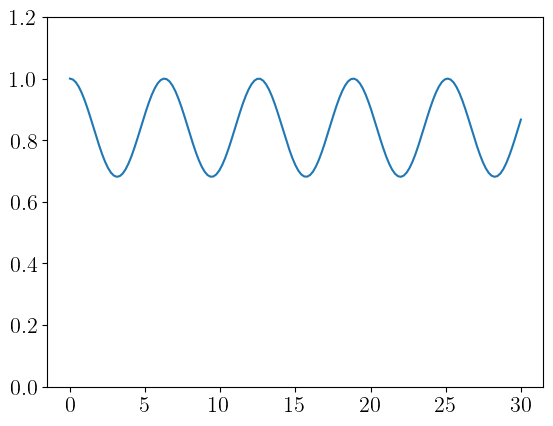

In [563]:
# test for vacuum oscillations
n_modes = 1
J       = np.zeros((n_modes,n_modes))
t_table = np.linspace(0,30,5*31)
sol = P_osc_RS(t_table, 0.3, 1.*np.ones(n_modes), 0, J)

t_table = sol.t
P_table = np.reshape(sol.y, (n_modes,3,len(t_table)))
for k in range(n_modes):
    plt.plot(t_table, 0.5*(1+P_table[k,2,:]))
plt.ylim(0,1.2)
plt.show()

### Vacuum Oscillations

In [41]:
n           = 4                       # number of quibits
L           = 8.                       # baseline
theta_table = np.array([np.pi/6])      # mixing angle
dmsq_table  = np.array([1.0])          # mass-squared difference
E_table     = np.linspace(0.5, 2, n)   # energies

theta = qk.circuit.Parameter("theta")  # mixing angle
phi   = qk.circuit.ParameterVector("phi", length=n)
                                       # oscillation phase \Delta m^2 L / (2E)
qr    = qk.QuantumRegister(n, 'q')
cr    = qk.ClassicalRegister(n, 'sq')
circ  = qk.QuantumCircuit(qr, cr)
for j in range(n):
    circ.rx(-2*theta, qr[j])
    circ.rz(phi[j], qr[j])
    circ.rx( 2*theta, qr[j])
    circ.measure(qr[j], cr[j])
#circ.measure_all()

# draw circuit
#circ.draw(output='mpl')

In [42]:
# loop over parameters / simulate
noise = False
for this_theta in theta_table:
    for this_dmsq in dmsq_table:
        c = circ.assign_parameters({theta: this_theta,
                                    phi:   this_dmsq*L/(2*E_table)})

        # Transpile for simulator
        if noise:
            backend = qk.providers.fake_provider.FakeManhattan() # IBM Manhattan - 65 qubits
            simulator = aer.AerSimulator.from_backend(backend)
        else:
            simulator = qk.Aer.get_backend('aer_simulator')
        c = qk.transpile(c, simulator)
#            c.draw()

        # Run and get counts
        result = simulator.run(c).result()
        counts = result.get_counts(c)

#qk.visualization.plot_histogram(counts)

In [52]:
# the same as above, but running in the cloud
import qiskit_ibm_runtime as qkrun
service = qkrun.QiskitRuntimeService(name="default-ibm-cloud")

for this_theta in theta_table:
    for this_dmsq in dmsq_table:
        c = circ.assign_parameters({theta: this_theta,
                                    phi:   this_dmsq*L/(2*E_table)})

        with qkrun.Session(service=service, backend="ibmq_qasm_simulator"):
            sampler = qkrun.Sampler()
            job = sampler.run(circuits=c)
            print(f"job id: {job.job_id()}")
            result = job.result()
            counts = {f'{k:0{n}b}': result.metadata[0]['shots']*result.quasi_dists[0][k]  for k in result.quasi_dists[0]}

job id: cll22461rkbghkgurmag


In [62]:
service.backends()

[<IBMBackend('ibmq_qasm_simulator')>,
 <IBMBackend('simulator_stabilizer')>,
 <IBMBackend('simulator_mps')>,
 <IBMBackend('simulator_extended_stabilizer')>,
 <IBMBackend('simulator_statevector')>]

In [66]:
backend = service.backend('ibmq_qasm_simulator')

In [67]:
?backend

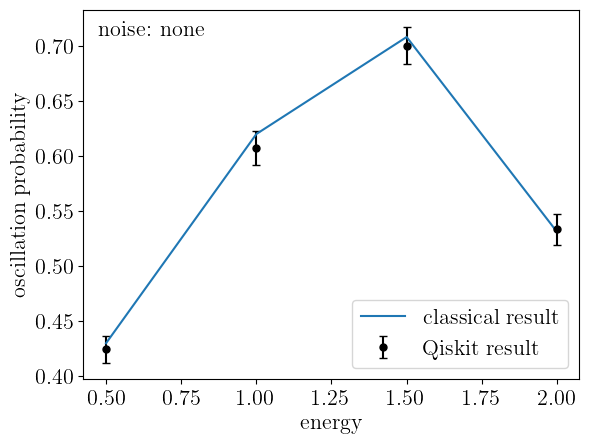

In [61]:
# plot oscillation proability
projected_counts = project_counts(counts)
P = [ p[1]/(p[0]+p[1]) for p in projected_counts ]  # oscillation probability
err = [ np.sqrt(p[1]/(p[0]+p[1])**2 + p[1]**2/(p[0]+p[1])**3)  for p in projected_counts ]
plt.errorbar(E_table, P, err, ls='', capsize=3, marker='.', markersize=10, color='black', label='Qiskit result')
plt.plot(E_table, np.sin(2*theta_table[0])**2 * np.sin(dmsq_table[0]*L/(4*E_table))**2, label='classical result')
plt.xlabel('energy')
plt.ylabel('oscillation probability')
plt.legend(loc='lower right')
plt.annotate('noise: {:s}'.format(str(backend) if noise else 'none'), (0.03,0.97), xycoords='axes fraction', ha='left', va='top')
#plt.savefig('fig/vacuum-osc.pdf')
plt.show()

In [6]:
# backend = provider.get_backend('ibmqx2')
#     noise_model = NoiseModel.from_backend(backend)
# # Get coupling map from backend
#     coupling_map = backend.configuration().coupling_map
# # Get basis gates from noise model
#     basis_gates = noise_model.basis_gates


### Vacuum Oscillations with Error Correction

In [84]:
# define simulation parameters
n_qubits    = 1                             # number of logical qubits
L           = 16.                            # baseline
theta       = np.pi/6                       # mixing angle
dmsq        = 1.0                           # mass-squared difference
E_table     = np.linspace(0.5, 2, n_qubits) # energies
Delta_table = dmsq / (2.*E_table)
b           = np.array([np.sin(2*theta), 0, -np.cos(2*theta)]) # structure of the vacuum Hamiltonian in the Pauli basis

t_steps     = 320
t_samples   = 10
dt          = L/t_steps

n_shots     = 1024                          # number of runs to collect statistics
ec_code     = '412'                         # error correction algorithm
                                            #   'none':  no error correction
                                            #   '2-bit': two physical qubits per logical qubit (this is not a real error correction code)
                                            #   '412': Leung-Nielsen-Chuang-Yamamoto [4,1,2] code from https://arxiv.org/abs/quant-ph/9704002
opt_level = 0                               # transpiler optimization level

In [151]:
def run_vacuum_osc(backend=None):
    """simulate vacuum oscillations with the globally defined parameters.
       Of relevance are in particular
           theta
           dmsq
           E_table
           L
           t_steps
           t_samples
           n_shots
           ec_code

        Arguments:
            backend: the backend on which to run the simulation.
                     default: None, in which case a noiseless AER simulator is used
    """
    
    # calculate derived parameters
    # ----------------------------
    Delta_table = dmsq / (2.*E_table)                              # oscillation frequency
    b           = np.array([np.sin(2*theta), 0, -np.cos(2*theta)]) # structure of the vacuum Hamiltonian in the Pauli basis
    dt          = L/t_steps                                        # time step
    
    # preparations for error correction
    # ---------------------------------
    n_logical = n_qubits
    if ec_code.lower() == 'none':
        n_phys = n_qubits
    elif ec_code.lower() == '2-bit':
        n_phys = 2 * n_qubits

        # define physical representations of the logical RX and RZ gates
        rx_log = lambda th: np.array([[    np.cos(0.5*th), 0, 0, -1j*np.sin(0.5*th)],
                                      [0,                  1, 0,                  0],
                                      [0,                  0, 1,                  0],
                                      [-1j*np.sin(0.5*th), 0, 0,     np.cos(0.5*th)]])
        rz_log = lambda lam: np.array([[np.exp(-0.5j*lam), 0, 0,                0],
                                       [0,                 1, 0,                0],
                                       [0,                 0, 1,                0],
                                       [0,                 0, 0, np.exp(0.5j*lam)]])
#    elif ec_code == '412':
    elif ec_code.lower() == '412' or ec_code.lower() == '412-test':
        n_phys = 5 * n_qubits  # we use a 5th, ancillary, qubit for error correction - a bit wasteful here, but easier to implement this way

        # Define the logical qubit code states
        zero_L = (basis_state(0,0,0,0) + basis_state(1,1,1,1)) / np.sqrt(2) # |0_L> = (|0000> + |1111>)/sqrt(2)
        one_L  = (basis_state(0,0,1,1) + basis_state(1,1,0,0)) / np.sqrt(2) # |1_L> = (|0011> + |1100>)/sqrt(2)
        U_LtoP = np.array([zero_L, one_L]).T  # matrix mapping a logical state onto a physical one
        rx_log = lambda th:  (U_LtoP @ np.array([[    np.cos(0.5*th), -1j*np.sin(0.5*th)],
                                                [-1j*np.sin(0.5*th),     np.cos(0.5*th)]]) @ U_LtoP.conj().T \
                           + np.identity(len(zero_L)) - U_LtoP @ U_LtoP.conj().T).round(10)
        rz_log = lambda lam: (U_LtoP @ np.array([[np.exp(-0.5j*lam),                0],
                                                [0,                 np.exp(0.5j*lam)]]) @ U_LtoP.conj().T \
                           + np.identity(len(zero_L)) - U_LtoP @ U_LtoP.conj().T).round(10)
        
    elif ec_code.lower() == 'bit-flip':
        n_phys = 5 * n_qubits  # we use separate ancillary qubits for each logical qubit
                                # ... not particularly efficient, but necessary given limited connectivity
        
        # Define the logical qubit code states
        zero_L = (basis_state(0,0,0) + basis_state(1,1,1)) / np.sqrt(2)   # logical 0 in 3-qubit subspace
        one_L  = (basis_state(0,0,0) - basis_state(1,1,1)) / np.sqrt(2)   # logical 1 in 3-qubit subspace

        U_LtoP = np.array([zero_L, one_L]).T  # matrix mapping a logical state onto a physical one
        rx_log = lambda th:  (U_LtoP @ np.array([[    np.cos(0.5*th), -1j*np.sin(0.5*th)],
                                                [-1j*np.sin(0.5*th),     np.cos(0.5*th)]]) @ U_LtoP.conj().T \
                           + np.identity(len(zero_L)) - U_LtoP @ U_LtoP.conj().T).round(10)
        rz_log = lambda lam: (U_LtoP @ np.array([[np.exp(-0.5j*lam),                0],
                                                [0,                 np.exp(0.5j*lam)]]) @ U_LtoP.conj().T \
                           + np.identity(len(zero_L)) - U_LtoP @ U_LtoP.conj().T).round(10)

    elif ec_code.lower() == 'shor':
        print("A") # FIXME
        n_phys = 11 * n_qubits  # we use separate ancillary qubits for each logical qubit
                                # ... not particularly efficient, but necessary given limited connectivity
        
        # Define the logical qubit code states
        zero_3 = (basis_state(0,0,0) + basis_state(1,1,1)) / np.sqrt(2)   # logical 0 in 3-qubit subspace
        one_3  = (basis_state(0,0,0) - basis_state(1,1,1)) / np.sqrt(2)   # logical 1 in 3-qubit subspace
        zero_L = np.kron(np.kron(zero_3, zero_3), zero_3)                 # logical 0 in full 9-qubit space
        one_L  = np.kron(np.kron(one_3,  one_3),  one_3)                  # logical 1 in full 9-qubit space

        U_LtoP = np.array([zero_L, one_L]).T  # matrix mapping a logical state onto a physical one
        rx_log = lambda th:  (U_LtoP @ np.array([[    np.cos(0.5*th), -1j*np.sin(0.5*th)],
                                                [-1j*np.sin(0.5*th),     np.cos(0.5*th)]]) @ U_LtoP.conj().T \
                           + np.identity(len(zero_L)) - U_LtoP @ U_LtoP.conj().T).round(10)
        rz_log = lambda lam: (U_LtoP @ np.array([[np.exp(-0.5j*lam),                0],
                                                [0,                 np.exp(0.5j*lam)]]) @ U_LtoP.conj().T \
                           + np.identity(len(zero_L)) - U_LtoP @ U_LtoP.conj().T).round(10)
        
        # transpile logical gates once so we can use directly the transpiled versions below
        print("B", U_LtoP.shape) # FIXME
        rx_log_t = {}
        for ql in range(n_qubits):
            dummy_qc = qk.QuantumCircuit(9)
            dummy_qc.unitary(rx_log(-dt*Delta_table[ql]*b[0]), range(9))
            rx_log_t[ql] = qk.transpile(dummy_qc, backend=backend, optimization_level=opt_level).to_instruction()
        rz_log_t = {}
        for ql in range(n_qubits):
            dummy_qc = qk.QuantumCircuit(9)
            dummy_qc.unitary(rz_log(-dt*Delta_table[ql]*b[2]), range(9))
            rz_log_t[ql] = qk.transpile(dummy_qc, backend=backend, optimization_level=opt_level).to_instruction()
        
    else:
        n_phys = None
        raise ValueError(f'unknown error correction code: {ec_code}')
        
    # set up backend
    # --------------
    print("C") # FIXME
    if backend is None:
        backend = aer.AerSimulator()
    
    # Loop over no. of steps to map out oscillations as function of L
    # ---------------------------------------------------------------
    global qc, isa_circ, jobs, result
    qc = {}
    isa_circ = {}
    counts = {}
    jobs = {}
    for j, this_t_step in enumerate(reversed(np.linspace(t_steps,t_steps//t_samples,t_samples,dtype=int))):
        sys.stdout.write(f't={this_t_step}\r')

        # the basic circuit with no error correction
        # ------------------------------------------
        if ec_code.lower() == 'none':
            qc[j] = qk.QuantumCircuit(n_phys, n_phys)

            # Trotterized time evolution
            for i in range(this_t_step):
                # add vacuum oscillation term for each qubit
                # note that b[1] = 0, so we can skip the ry rotation
                for ql in range(n_qubits):
                    qc[j].rx(-dt*Delta_table[ql]*b[0], ql)
                    qc[j].rz(-dt*Delta_table[ql]*b[2], ql)
                qc[j].barrier()


            # measurement
            qc[j].measure(range(n_qubits), range(n_qubits))

        # simple 2-qubit code (not real error correction, just duplication to test some concepts)
        # ---------------------------------------------------------------------------------------
        elif ec_code.lower() == '2-bit':
            qc[j] = qk.QuantumCircuit(n_phys, n_phys)

            # Trotterized time evolution
            for i in range(this_t_step):
                # add vacuum oscillation term for each qubit
                # note that b[1] = 0, so we can skip the ry rotation
                for ql in range(n_qubits):
                    qp = 2 * ql   # index of first physical qubit corresponding to logical qubit ql
                    qc[j].unitary(rx_log(-dt*Delta_table[ql]*b[0]), [qp,qp+1])
                    qc[j].unitary(rz_log(-dt*Delta_table[ql]*b[2]), [qp,qp+1]) 
                qc[j].barrier()

            # measurement
            qc[j].measure(range(n_qubits), range(n_qubits))

        # Leung-Nielsen-Chuang-Yamamoto [4,1,2] code from https://arxiv.org/abs/quant-ph/9704002
        # --------------------------------------------------------------------------------------
        elif ec_code.lower() == '412':
            qc[j] = qk.QuantumCircuit(n_phys, n_phys)

            # create entangled initial state
            for ql in range(n_qubits):
                qp = n_phys//n_logical * ql   # index of first physical qubit corresponding to logical qubit ql
                qc[j].ry(np.pi/2, qp)
                qc[j].cx(qp, qp+1)
                qc[j].cx(qp, qp+2)
                qc[j].cx(qp, qp+3)

            # Trotterized time evolution
            for i in range(this_t_step):
                # add vacuum oscillation term for each qubit
                # note that b[1] = 0, so we can skip the ry rotation
                for ql in range(n_qubits):
                    qp = n_phys//n_logical * ql   # index of first physical qubit corresponding to logical qubit ql
                    qc[j].unitary(rx_log(-dt*Delta_table[ql]*b[0]), [qp,qp+1,qp+2,qp+3])
                    qc[j].unitary(rz_log(-dt*Delta_table[ql]*b[2]), [qp,qp+1,qp+2,qp+3])
                qc[j].barrier()

            # decoding / diagonsis
            gamma = 0.001   # probability of losing a photon
            th1   = np.arctan((1-gamma)**2)
            th2   = np.arccos(1-gamma)
            for ql in range(n_qubits):
                qp = n_phys//n_logical * ql   # index of first physical qubit corresponding to logical qubit ql
                qc[j].cx(qp,   qp+1)
                qc[j].cx(qp+2, qp+3)
                qc[j].measure(qp+1, qp+1)
                qc[j].measure(qp+3, qp+3)
                with qc[j].if_test((qp+1,0)) as _else1:
                    with qc[j].if_test((qp+3,0)) as _else2:
                        qc[j].cx(qp+2, qp)
                        qc[j].ry(-2*th1, qp+2)
                        qc[j].cry(-2*(np.pi/4 - th1), qp, qp+2)
                        qc[j].measure(qp+2, qp+2)
                        qc[j].measure(qp, qp)     # this is the measurement we're interested in
                    with _else2:
                        qc[j].x(qp)
                        qc[j].cry(-2*(np.pi/4 - th2), qp, qp+4)
                        qc[j].measure(qp+4, qp+4)
                        qc[j].measure(qp, qp)     # this is the measurement we're interested in
                with _else1:
                    with qc[j].if_test((qp+3,0)) as _else2:
                        qc[j].x(qp+2)
                        qc[j].cry(-2*(np.pi/4 - th2), qp+2, qp+4)
                        qc[j].measure(qp+4, qp+4)
                        qc[j].measure(qp+2, qp)   # this is the measurement we're interested in
                    with _else2:
                        pass  # do nothing - these shots will be discarded in post-processing

        # ---------------------------------------------
        elif ec_code.lower() == '412-test':   # FIXME FIXME remove - this is w/o the actual EC step!
            qc[j] = qk.QuantumCircuit(n_phys, n_phys)

            # create entangled initial state
            for ql in range(n_qubits):
                qp = n_phys//n_logical * ql   # index of first physical qubit corresponding to logical qubit ql
                qc[j].cx(qp+2,qp+3)
                qc[j].ry(np.pi/2, qp)#FIXME
                qc[j].cx(qp, qp+1)
                qc[j].cx(qp, qp+2)
                qc[j].cx(qp, qp+3)

            # Trotterized time evolution
            for i in range(this_t_step):
                # add vacuum oscillation term for each qubit
                # note that b[1] = 0, so we can skip the ry rotation
                for ql in range(n_qubits):
                    qp = n_phys//n_logical * ql   # index of first physical qubit corresponding to logical qubit ql
                    qc[j].unitary(rx_log(-dt*Delta_table[ql]*b[0]), [qp,qp+1,qp+2,qp+3])
                    qc[j].unitary(rz_log(-dt*Delta_table[ql]*b[2]), [qp,qp+1,qp+2,qp+3])
                qc[j].barrier()

            # undo entanglement
            for ql in range(n_qubits):
                qp = n_phys//n_logical * ql
                qc[j].cx(qp,qp+3)
                qc[j].cx(qp,qp+2)
                qc[j].cx(qp,qp+1)
                qc[j].ry(-np.pi/2, qp)#FIXME
                qc[j].cx(qp+2,qp+3)

            # measurement
            qc[j].measure(range(n_phys), range(n_phys))
        
        # The 3-qubit subcode correcting bit flips (but not phase flips) of the [9,1,3] Shor code
        # see for instance https://en.wikipedia.org/wiki/Quantum_error_correction#Shor_code
        # and Nakahara, "Quantum Computing"
        # ---------------------------------------------------------------------------------
        elif ec_code.lower() == 'bit-flip':
            qc[j] = qk.QuantumCircuit(n_phys, n_phys)
            
            # create entangled initial state
            for ql in range(n_qubits):
                qp = n_phys//n_logical * ql   # index of first physical qubit corresponding to logical qubit ql
                qc[j].h(qp)
                qc[j].cx(qp,qp+1)
                qc[j].cx(qp,qp+2)

            # Trotterized time evolution
            for i in range(this_t_step):
                # add vacuum oscillation term for each qubit
                # note that b[1] = 0, so we can skip the ry rotation
                for ql in range(n_qubits):
                    qp = n_phys//n_logical * ql   # index of first physical qubit corresponding to logical qubit ql
#                     qc[j].unitary(rx_log(-dt*Delta_table[ql]*b[0]), range(qp,qp+3))
#                     qc[j].unitary(rz_log(-dt*Delta_table[ql]*b[2]), range(qp,qp+3))
#                 qc[j].barrier()
# FIXME

                # syndrome detection / error correction, see Nakahara, fig. 10.6
                # we do this every few time steps
                if i>0 and i%5==0:               
                    for ql in range(n_qubits):
                        qp = n_phys//n_logical * ql
                        anc = qp+3  # index of first ancillary qubit

                        # detect and correct bit flip errors
                        qc[j].reset([anc,anc+1])
                        qc[j].cx(qp,   anc)
                        qc[j].cx(qp+1, anc)
                        qc[j].cx(qp,   anc+1)
                        qc[j].cx(qp+2, anc+1)
                        qc[j].measure([anc,anc+1], [anc,anc+1])
                        with qc[j].if_test((anc,0)) as _else1:
                            with qc[j].if_test((anc+1,0)) as _else2:   # (A,B) = (0,0) -> no bit flip
                                pass
                            with _else2:                               # (A,B) = (0,1) -> bit flip in qubit 2
                                qc[j].x(qp+2)
                        with _else1:
                            with qc[j].if_test((anc+1,0)) as _else2:   # (A,B) = (1,0) -> bit flip in qubit 1
                                qc[j].x(qp+1)
                            with _else2:                               # (A,B) = (1,1) -> bit flip in qubit 0
                                qc[j].x(qp)                            

            # FIXME
#             for ql in range(n_qubits):
#                 qp = n_phys//n_logical * ql
#                 anc = qp+3  # index of first ancillary qubit

#                 # detect and correct bit flip errors
#                 qc[j].cx(qp,   anc)
#                 qc[j].cx(qp+1, anc)
#                 qc[j].cx(qp,   anc+1)
#                 qc[j].cx(qp+2, anc+1)
#                 qc[j].measure([anc,anc+1], [anc,anc+1])
#                 with qc[j].if_test((anc,0)) as _else1:
#                     with qc[j].if_test((anc+1,0)) as _else2:   # (A,B) = (0,0) -> no bit flip
#                         pass
#                     with _else2:                               # (A,B) = (0,1) -> bit flip in qubit 2
#                         qc[j].x(qp+2)
#                 with _else1:
#                     with qc[j].if_test((anc+1,0)) as _else2:   # (A,B) = (1,0) -> bit flip in qubit 1
#                         qc[j].x(qp+1)
#                     with _else2:                               # (A,B) = (1,1) -> bit flip in qubit 0
#                         qc[j].x(qp)                            
                                
            # undo entanglement according to Nakahara, fig. 10.7
            for ql in range(n_qubits):
                qp = n_phys//n_logical * ql
                qc[j].cx(qp,qp+2)
                qc[j].cx(qp,qp+1)
                qc[j].h(qp)
                
            # measurement
#             for ql in range(n_qubits):
#                 qp = n_phys//n_logical * ql
#                 qc[j].measure([qp,qp+1,qp+2],[qp,qp+1,qp+2])
            qc[j].measure(range(n_phys), range(n_phys))
                
        # The [9,1,3] Shor code
        # see for instance https://en.wikipedia.org/wiki/Quantum_error_correction#Shor_code
        # and Nakahara, "Quantum Computing"
        # ---------------------------------------------------------------------------------
        elif ec_code.lower() == 'shor':
            print("circuit construction") # FIXME
            qc[j] = qk.QuantumCircuit(n_phys, n_phys)
            
            # create entangled initial state
            for ql in range(n_qubits):
                qp = n_phys//n_logical * ql   # index of first physical qubit corresponding to logical qubit ql
                qc[j].cx(qp,qp+3)
                qc[j].cx(qp,qp+6)
                qc[j].h(qp)
                qc[j].h(qp+3)
                qc[j].h(qp+6)
                qc[j].cx(qp,qp+1)
                qc[j].cx(qp,qp+2)
                qc[j].cx(qp+3,qp+4)
                qc[j].cx(qp+3,qp+5)
                qc[j].cx(qp+6,qp+7)
                qc[j].cx(qp+6,qp+8)

            # Trotterized time evolution
            for i in range(this_t_step):
                # add vacuum oscillation term for each qubit
                # note that b[1] = 0, so we can skip the ry rotation
                for ql in range(n_qubits):
                    qp = n_phys//n_logical * ql   # index of first physical qubit corresponding to logical qubit ql
#                    qc[j].unitary(rx_log(-dt*Delta_table[ql]*b[0]), range(qp,qp+9))
#                    qc[j].unitary(rz_log(-dt*Delta_table[ql]*b[2]), range(qp,qp+9))
                    # use directly the transpiled gates
                    qc[j].append(rx_log_t[ql], range(qp,qp+9))
                    qc[j].append(rz_log_t[ql], range(qp,qp+9))
                qc[j].barrier()
                
                # syndrome detection / error correction, see Nakahara, fig. 10.6
                # we do this every couple of time steps
                if i>0 and i%5==0:                
                    for ql in range(n_qubits):
                        qp = n_phys//n_logical * ql
                        anc = qp+9  # index of first ancillary qubit

                        # detect and correct bit flip errors
                        for k in [0,3,6]:
                            qc[j].reset([anc,anc+1])
                            qc[j].cx(qp+k,   anc)
                            qc[j].cx(qp+k+1, anc)
                            qc[j].cx(qp+k,   anc+1)
                            qc[j].cx(qp+k+2, anc+1)
                            qc[j].measure([anc,anc+1], [anc,anc+1])
                            with qc[j].if_test((anc,0)) as _else1:
                                with qc[j].if_test((anc+1,0)) as _else2:   # (A,B) = (0,0) -> no bit flip
                                    pass
                                with _else2:                               # (A,B) = (0,1) -> bit flip in qubit 2
                                    qc[j].x(qp+k+2)
                            with _else1:
                                with qc[j].if_test((anc+1,0)) as _else2:   # (A,B) = (1,0) -> bit flip in qubit 1
                                    qc[j].x(qp+k+1)
                                with _else2:                               # (A,B) = (1,1) -> bit flip in qubit 0
                                    qc[j].x(qp+k)

                        for k in range(9):
                            qc[j].h(qp+k)

                        # detect and correct phase flip errors
                        for k in range(6):
                            qc[j].cx(qp+k, anc)        
                        for k in [0,1,2,6,7,8]:
                            qc[j].cx(qp+k, anc+1)        
                        for k in range(9):
                            qc[j].h(qp+k)
                        qc[j].measure([anc,anc+1], [anc,anc+1])
                        with qc[j].if_test((anc,0)) as _else1:
                            with qc[j].if_test((anc+1,0)) as _else2:   # (A,B) = (0,0) -> no phase flip
                                pass
                            with _else2:                               # (A,B) = (0,1) -> phase flip in 3rd triplet
                                qc[j].z(qp+6)
                        with _else1:
                            with qc[j].if_test((anc+1,0)) as _else2:   # (A,B) = (1,0) -> phase flip in 2nd triplet
                                qc[j].z(qp+3)
                            with _else2:                               # (A,B) = (1,1) -> phase flip in 1st triplet
                                qc[j].z(qp)
                
            # undo entanglement according to Nakahara, fig. 10.7
            for ql in range(n_qubits):
                qp = n_phys//n_logical * ql
                qc[j].cx(qp+6,qp+8)
                qc[j].cx(qp+6,qp+7)
                qc[j].cx(qp+3,qp+5)
                qc[j].cx(qp+3,qp+4)
                qc[j].cx(qp,qp+2)
                qc[j].cx(qp,qp+1)
                qc[j].h(qp+6)
                qc[j].h(qp+3)
                qc[j].h(qp)
                qc[j].cx(qp,qp+6)
                qc[j].cx(qp,qp+3)

            # measurement
            qc[j].measure(range(n_phys), range(n_phys))
                
        else:
            raise ValueError(f'unknown error correction code: {ec_code}')
#        print(qk.quantum_info.Statevector(qc[0]).to_dict()) # FIXME

        # transpile
        print("transpilation") # FIXME
        isa_circ[j] = qk.transpile(qc[j], backend=backend, optimization_level=opt_level)
#        isa_circ[j] = qk.transpile(qc[j], backend=backend)

        # running on IBM hardware
        print("running") # FIXME
        if hasattr(backend, 'configuration') and backend.configuration().simulator == False \
          and backend.name != 'fake_torino':  # for some reason, SamplerV2 with FakeTorino backend can't handle some instructions
            job_id = (this_t_step,)
            sampler = qkrun.SamplerV2(mode=backend, options={"default_shots": n_shots})
            #sampler.options.dynamical_decoupling.enable = True # can't be used with dynamical circuits
            #sampler.options.dynamical_decoupling.sequence_type = "XpXm"
            print(f"submitting to {backend.name} for time step #{this_t_step} ({n_logical} logical / {n_phys} physical) qubits")
            # if service._account.instance == 'ibm-q/open/main':
            #     while np.count_nonzero([jobs[j].status() in ['QUEUED','RUNNING'] for j in jobs]) >= 3:
            #         this_status = [jobs[j].status() for j in jobs if jobs[j].status() in ['QUEUED','RUNNING']]
            #         print(f'waiting for jobs to finish (status={this_status}')
            #         time.sleep(1)
            jobs[job_id] = sampler.run([isa_circ[j]])
            
        # running on Amazon AWS Braket
        elif type(backend.provider) == braket.providers.braket_provider.BraketProvider:
            braket_job = backend.run(isa_circ[j], shots=n_shots)
            braket_job.wait_for_final_state()
            result = braket_job.result()
            counts[(this_t_step,)] = result.get_counts()

        # running in a simulator
        else:
            result = backend.run(qc[j], shots=n_shots).result()
            counts[(this_t_step,)] = result.get_counts(qc[j])

    # if running on real hardware, wait for jobs to finish
    print('')   # print new line after we've overwritten the t=XXX line again and again
    if len(jobs) > 0:
        job_status = {}
        while True:
            done = True
            for job in jobs:
                if jobs[job].status() not in [qk.providers.jobstatus.JobStatus.DONE, qk.providers.jobstatus.JobStatus.CANCELLED, qk.providers.jobstatus.JobStatus.ERROR, 'DONE', 'CANCELLED', 'ERROR']:
                    done = False
                job_status[job] = jobs[job].status()
                if hasattr(job_status[job], 'name'): job_status[job] = job_status[job].name  # for simulators, status structure is different
            print('Jobs status: '
                  f'{np.count_nonzero(np.array(list(job_status.values())) == "QUEUED")} QUEUED, '
                + f'{np.count_nonzero(np.array(list(job_status.values())) == "DONE")} DONE, '
                + f'{np.count_nonzero(np.array(list(job_status.values())) == "RUNNING")} RUNNING, '
                + f'{np.count_nonzero(np.array(list(job_status.values())) == "CANCELLED")} CANCELLED, '
                + f'{np.count_nonzero(np.array(list(job_status.values())) == "ERROR")} ERROR.')
            if done:
                break
            time.sleep(1)

        # retrieve results
        for job_id in jobs:
            if jobs[job_id].status() in [qk.providers.jobstatus.JobStatus.DONE, 'DONE']:
                counts[job_id] = jobs[job_id].result()[0].data.c.get_counts()
                    # note: when using measure_all(), the results are stored in data.meas;
                    #       when using measure(), they are in data.c
    
    return counts
    
# ------------------------------------------------------------------------------
    
def compute_probabilities(counts, ec_code):
    """calculate oscillation probabilities and errors from the results of
       a quantum simulations, given as counts returned by run_vacuum_osc()
       
       Arguments:
           counts:  the table of measured outcome, as return by run_vacuum_osc()
           ec_code: the error correction scheme that was employed in the simulation
           
       Returns:
           P:   oscillation probabilities
           err: associated statistical uncertainties
    """
    
    projected_counts = {}
    P = {}
    err = {}
    if ec_code.lower() == 'none':
        for k in counts.keys():
            projected_counts[k] = project_counts(counts[k])
            P[k] = np.array([ p[1]/(p[0]+p[1]) for p in projected_counts[k] ])  # oscillation probability
            err[k] = np.array([ np.sqrt( p[1] * (1/(p[0]+p[1]) - p[1]/(p[0]+p[1])**2)**2
                                       + p[0] * (1/(p[0]+p[1])**2)**2 )  for p in projected_counts[k] ])
    elif ec_code.lower() == '2-bit':
        for k in counts.keys():
            projected_counts[k] = project_counts(counts[k])
            P[k] = np.array([ p[1]/(p[0]+p[1]) for p in projected_counts[k][::2] ])  # oscillation probability
            err[k] = np.array([ np.sqrt( p[1] * (1/(p[0]+p[1]) - p[1]/(p[0]+p[1])**2)**2
                                       + p[0] * (1/(p[0]+p[1])**2)**2 )  for p in projected_counts[k][::2] ])
    elif ec_code.lower() == '412-test': # FIXME FIXME
        for k in counts.keys():
            projected_counts[k] = project_counts(counts[k])
            P[k] = np.array([ p[1]/(p[0]+p[1]) for p in projected_counts[k][2::5] ])  # oscillation probability
            err[k] = np.array([ np.sqrt( p[1] * (1/(p[0]+p[1]) - p[1]/(p[0]+p[1])**2)**2
                                       + p[0] * (1/(p[0]+p[1])**2)**2 )  for p in projected_counts[k][2::5] ])
        
    elif ec_code.lower() == '412':
        for k in counts.keys():
            n_phys = len(next(iter(next(iter(counts.values())).keys())))
            n_logical = n_qubits
            s = n_phys // n_logical

            # extract probabilities, along the way discarding "invalid" shots
            # (i.e. those with an outcome that shouldn't occur)
            projected_counts[k] = [dict.fromkeys([0, 1], 0) for _ in range(n_phys)]
            for state, count in counts[k].items():
                rstate = list(reversed(state))
                if '1' in rstate[4::s]:  # ancillary qubit for error correction must be zero, see https://arxiv.org/abs/quant-ph/9704002
                    continue
                elif any(c1=='1' and c2=='1' for c1, c2 in zip(rstate[1::s], rstate[3::s])):
                    continue            # diagnostic measurements can't both be '1' (in theory)
                for qubit_index, qubit_state in enumerate(rstate):
                    projected_counts[k][qubit_index][int(qubit_state)] += count

            P[k] = np.array([ p[1]/(p[0]+p[1]) for p in projected_counts[k][::s] ])  # oscillation probability
            err[k] = np.array([ np.sqrt( p[1] * (1/(p[0]+p[1]) - p[1]/(p[0]+p[1])**2)**2
                                       + p[0] * (1/(p[0]+p[1])**2)**2 )  for p in projected_counts[k][::s] ])
    elif ec_code.lower() == 'bit-flip':
        for k in counts.keys():
            projected_counts[k] = project_counts(counts[k])
            P[k] = np.array([ p[1]/(p[0]+p[1]) for p in projected_counts[k][::5] ])  # oscillation probability
            err[k] = np.array([ np.sqrt( p[1] * (1/(p[0]+p[1]) - p[1]/(p[0]+p[1])**2)**2
                                       + p[0] * (1/(p[0]+p[1])**2)**2 )  for p in projected_counts[k][::5] ])
    elif ec_code.lower() == 'shor':
        for k in counts.keys():
            projected_counts[k] = project_counts(counts[k])
            P[k] = np.array([ p[1]/(p[0]+p[1]) for p in projected_counts[k][::11] ])  # oscillation probability
            err[k] = np.array([ np.sqrt( p[1] * (1/(p[0]+p[1]) - p[1]/(p[0]+p[1])**2)**2
                                       + p[0] * (1/(p[0]+p[1])**2)**2 )  for p in projected_counts[k][::11] ])
    else:
        raise ValueError(f'unknown error correction code: {ec_code}')
        
    return P, err

In [193]:
zero_L = (basis_state(0,0,0) + basis_state(1,1,1)) / np.sqrt(2)   # logical 0 in 3-qubit subspace
one_L  = (basis_state(0,0,0) - basis_state(1,1,1)) / np.sqrt(2)   # logical 1 in 3-qubit subspace

U_LtoP = np.array([zero_L, one_L]).T  # matrix mapping a logical state onto a physical one
rx_log = lambda th:  (U_LtoP @ np.array([[    np.cos(0.5*th), -1j*np.sin(0.5*th)],
                                        [-1j*np.sin(0.5*th),     np.cos(0.5*th)]]) @ U_LtoP.conj().T \
                   + np.identity(len(zero_L)) - U_LtoP @ U_LtoP.conj().T).round(5)
rz_log = lambda lam: (U_LtoP @ np.array([[np.exp(-0.5j*lam),                0],
                                        [0,                 np.exp(0.5j*lam)]]) @ U_LtoP.conj().T \
                   + np.identity(len(zero_L)) - U_LtoP @ U_LtoP.conj().T).round(5)
qc = qk.QuantumCircuit(3)
phi = qk.circuit.Parameter('phi')
qc.h(0)
qc.cx(0,1)
qc.cx(0,2)
qc.barrier()
qc.unitary(rx_log(np.pi), [0,1,2])
isa_circ = qk.transpile(qc, backend=backend, optimization_level=3)

In [198]:
# We'll create a new circuit that replicates the above
# but also includes save_statevector after each instruction.
qc_with_saves = qk.QuantumCircuit(isa_circ.num_qubits)

for i, (instr, qargs, cargs) in enumerate(isa_circ.data):
    # Append the same gate/instruction
#    print(instr)
    qc_with_saves.append(instr, qargs, cargs)
    # Insert a save_statevector with a unique label
    qc_with_saves.save_statevector(label=f"state_after_{i}")

# Now run this "annotated" circuit on the statevector simulator
sim = aer.AerSimulator(method='statevector')
transpiled = qk.transpile(qc_with_saves, sim)
result = sim.run(transpiled).result()

# You can retrieve each intermediate state by label:
for i in range(len(isa_circ.data)):
    state_label = f"state_after_{i}"
    state_vec = np.array(result.data(0)[state_label]).round(3)
    print(np.abs(state_vec))


[0.707 0.707 0.    0.    0.    0.    0.    0.   ]
[0.707 0.    0.    0.707 0.    0.    0.    0.   ]
[0.707 0.    0.    0.    0.    0.    0.    0.707]
[0.707 0.    0.    0.    0.    0.    0.    0.707]
[0.707 0.    0.    0.    0.    0.    0.    0.707]
[0.679 0.    0.196 0.    0.    0.196 0.    0.679]
[0.679 0.    0.196 0.    0.    0.679 0.    0.196]
[0.         0.67882251 0.         0.19657569 0.67882251 0.
 0.19657569 0.        ]
[0.         0.34180843 0.         0.61861862 0.34180843 0.
 0.61861862 0.        ]
[0.         0.61861862 0.         0.34180843 0.34180843 0.
 0.61861862 0.        ]
[0.61931737 0.         0.34169577 0.         0.         0.34200146
 0.         0.61900323]
[0.70678144 0.         0.         0.         0.         0.
 0.         0.70684723]
[0.70678144 0.         0.         0.         0.         0.
 0.         0.70711244]
[0.70678144 0.         0.         0.70711244 0.         0.
 0.         0.        ]
[0.70678144 0.         0.         0.70711244 0.         0.
 0

/var/folders/sd/hm2ph8vn5cl61qsssm31k1940000gn/T/ipykernel_80644/221291758.py:5: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  for i, (instr, qargs, cargs) in enumerate(isa_circ.data):


In [107]:
# basic noiseless simulator
# backend = aer.AerSimulator()

# AER simulator with custom noise model
# noise_model = aer.noise.NoiseModel()
# noise_model.add_all_qubit_quantum_error(aer.noise.amplitude_damping_error(0.01), ['rx','ry','rz','x']) # amplitude damping error for 1-qubit gates
# noise_model.add_all_qubit_quantum_error(aer.noise.depolarizing_error(0.01,1), ['rx','ry','rz','x']) # error for 1-qubit gates
# #noise_model.add_all_qubit_quantum_error(aer.noise.thermal_relaxation_error(50e-6, 70e-6, 0.01), 'measure') # thermal relaxation in measurement
# backend = aer.AerSimulator(noise_model=noise_model)
    
# noise model proposed by ChatGPT
from concurrent.futures import ThreadPoolExecutor
T1 = 100e3  # 100 µs                 # coherence times (T1, T2)
T2 = 80e3   # 80 µs
gate_time_1q = 50e-9  # 50 ns
gate_time_2q = 250e-9  # 250 ns
meas_time = 400e-9  # 400 ns
single_qubit_error = 0.001  # 0.1%   # depolarizing error rates
two_qubit_error = 0.01  # 1%
single_qubit_error=0.01 # FIXME FIXME FIXME
two_qubit_error=0.03 # FIXME FIXME FIXME
readout_error_matrix = [[0.98, 0.02], [0.05, 0.95]]  # P(meas 1|0) = 2%, P(meas 0|1) = 5%   # measurement readout error (bit-flip probabilities)

noise_model = aer.noise.NoiseModel()
single_qubit_relaxation = aer.noise.thermal_relaxation_error(T1, T2, gate_time_1q)
single_qubit_depol = aer.noise.depolarizing_error(single_qubit_error, 1)
single_qubit_error = single_qubit_relaxation.compose(single_qubit_depol)
two_qubit_relaxation = aer.noise.thermal_relaxation_error(T1, T2, gate_time_2q).tensor(aer.noise.thermal_relaxation_error(T1, T2, gate_time_2q))
two_qubit_depol = aer.noise.depolarizing_error(two_qubit_error, 2)
two_qubit_error = two_qubit_relaxation.compose(two_qubit_depol)
readout_error = aer.noise.ReadoutError(readout_error_matrix)
noise_model.add_all_qubit_quantum_error(single_qubit_error, ['u1', 'u2', 'u3'])  # Single-qubit gates
noise_model.add_all_qubit_quantum_error(two_qubit_error, ['cx'])  # CNOT gate
noise_model.add_all_qubit_readout_error(readout_error)
backend = aer.AerSimulator(noise_model=noise_model)
if 'GPU' in backend.available_devices():
    backend.set_options(device='GPU')

# IBM simulators
# service = qkrun.QiskitRuntimeService(name='ibm-quantum-gmail', instance='ibm-q/open/main')
# #backend = qkrun.fake_provider.FakeTorino()
# backend = qkrun.fake_provider.FakeSherbrooke() # FIXME
# #backend._setup_sim()
# #if 'GPU' in backend.sim.available_devices():
# #   backend.set_options(device='GPU')

# real IBM hardware
# service = qkrun.QiskitRuntimeService(name='ibm-quantum-gmail', instance='ibm-q/open/main')
# backend = service.backend('ibm_kyiv', instance='ibm-q/open/main')

# Amazon Braket backend
# provider = braket.BraketProvider()
# # backend = provider.get_backend("SV1")  # noisless state vector simulator - cloud-based
# backend = provider.get_backend("dm1")  # noisy simulator - cloud-based
# # backend = braket.providers.BraketLocalBackend(name='braket_dm') # noisy simulator - local

# ec_code = 'none'
# counts_0 = run_vacuum_osc(backend=backend)
# ec_code = '412'
# counts_412 = run_vacuum_osc(backend=backend)
# ec_code = 'bit-flip'
# counts_bit_flip = run_vacuum_osc(backend=backend)
ec_code = 'shor'
counts_shor = run_vacuum_osc(backend=backend)

A
B (512, 2)
C
circuit construction
transpilation


KeyboardInterrupt: 

In [ ]:
# plot results from quantum simulation
my_colors = [plt.rcParams['axes.prop_cycle'].by_key()['color'][j] for j in np.searchsorted(np.unique(E_table), E_table)]
L_table = np.array([ k[0]*L/t_steps for k in counts_0.keys() ])
if 'counts_0' in globals() and counts_0 is not None:
    P_0,   err_0     = compute_probabilities(counts_0, ec_code='none')
    for ql in range(n_qubits):
        plt.errorbar(L_table, [P_0[k][ql] for k in counts_0.keys()], [err_0[k][ql] for k in counts_0.keys()],
                     color=my_colors[ql], ls='-', capsize=3, marker='.', markersize=8, label='no EC' if ql==0 else None)
if 'counts_412' in globals() and counts_412 is not None:
    P_412, err_412   = compute_probabilities(counts_412, ec_code='412')
    #P_412, err_412 = compute_probabilities(counts_412, ec_code='412-test') # FIXME FIXME
    for ql in range(n_qubits):
        plt.errorbar(L_table, [P_412[k][ql] for k in counts_412.keys()], [err_412[k][ql] for k in counts_412.keys()],
                     color=my_colors[ql], ls='--', capsize=3, marker='s', markersize=5, label='[4,1,2]' if ql==0 else None)
if 'counts_bit_flip' in globals() and counts_bit_flip is not None:
    P_bit_flip, err_bit_flip = compute_probabilities(counts_bit_flip, ec_code='bit-flip')
    for ql in range(n_qubits):
        plt.errorbar(L_table, [P_bit_flip[k][ql] for k in counts_bit_flip.keys()], [err_bit_flip[k][ql] for k in counts_bit_flip.keys()],
                     color=my_colors[ql], ls=':', capsize=3, marker='*', markersize=5, label='bit-flip corr.' if ql==0 else None)
if 'counts_shor' in globals() and counts_shor is not None:
    P_shor, err_shor = compute_probabilities(counts_shor, ec_code='shor')
    for ql in range(n_qubits):
        plt.errorbar(L_table, [P_shor[k][ql] for k in counts_shor.keys()], [err_shor[k][ql] for k in counts_shor.keys()],
                     color=my_colors[ql], ls=':', capsize=3, marker='*', markersize=5, label='Shor [9,1,3]' if ql==0 else None)
    
# plot probabilities from classical calculation
L_table_fine = np.linspace(0, L_table[-1], 2000)
for this_Delta in Delta_table:
    plt.plot(L_table_fine, np.sin(2*theta)**2 * np.sin(0.5*this_Delta*L_table_fine)**2, ls='-', alpha=0.5, lw=3)
    
# custom_lines = [lines.Line2D([0], [0], color='k', ls='-'),
#                 lines.Line2D([0], [0], color='k', ls='--'),
#                 lines.Line2D([0], [0], color='k', ls=':')]
# plt.legend(custom_lines, ['no EC', '[4,1,2] EC code', 'analytic'])
plt.legend(loc='upper left')

plt.xlabel('time')
plt.ylabel('oscillation probability')
#plt.xlim(0,4100)
plt.show()


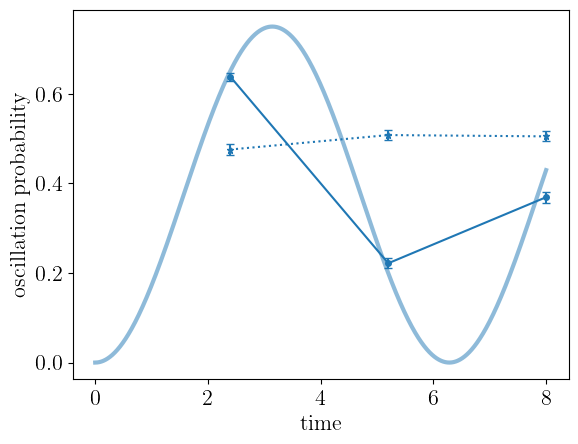

In [245]:
# IBM Kyiv - no EC

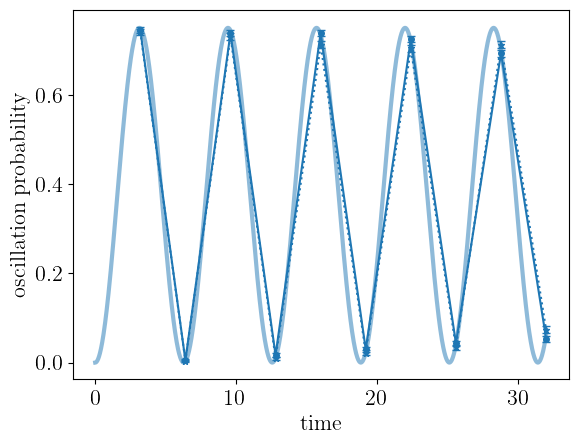

In [225]:
# IBM Sherbrooke

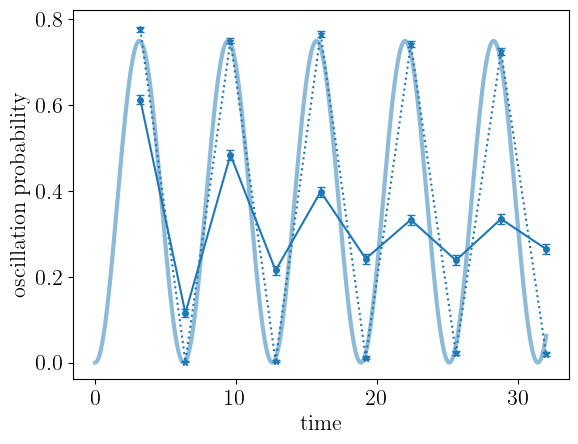

In [86]:
# AER with artifically large noise

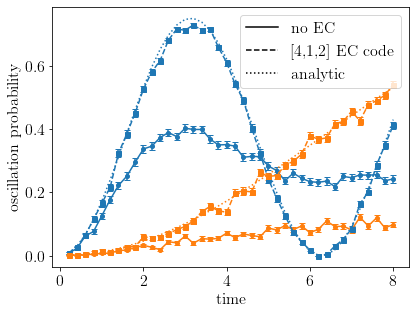

### Verification of Some Results from the Literature

In [1916]:
# make sure we use the same gate definitions as https://arxiv.org/abs/2207.03189
# (up to overall phase factors)

# U Gate
theta=-np.pi/6
phi=np.pi/6

qc=qk.QuantumCircuit(1)
qc.u(theta, phi - np.pi/2, -phi + np.pi/2, 0)
print(np.array(qk.quantum_info.Operator(qc)))
print(np.array([[np.cos(theta/2),                      -1j*np.exp(-1j*phi) * np.sin(theta/2)],
                [-1j*np.exp(1j*phi) * np.sin(theta/2), np.cos(theta/2)]]))  # eq. 26
print()

# ZZ Gate
qc=qk.QuantumCircuit(2)
qc.rzz(np.pi/2, 0, 1)
print(np.array(qk.quantum_info.Operator(qc)))
print(np.exp(-1j*np.pi/4) * np.diag([1, 1j, 1j, 1]))  # eq. 27


[[ 0.96592583+0.j          0.12940952+0.22414387j]
 [-0.12940952+0.22414387j  0.96592583+0.j        ]]
[[ 0.96592583+0.j          0.12940952+0.22414387j]
 [-0.12940952+0.22414387j  0.96592583+0.j        ]]

[[0.70710678-0.70710678j 0.        +0.j         0.        +0.j
  0.        +0.j        ]
 [0.        +0.j         0.70710678+0.70710678j 0.        +0.j
  0.        +0.j        ]
 [0.        +0.j         0.        +0.j         0.70710678+0.70710678j
  0.        +0.j        ]
 [0.        +0.j         0.        +0.j         0.        +0.j
  0.70710678-0.70710678j]]
[[0.70710678-0.70710678j 0.        +0.j         0.        +0.j
  0.        +0.j        ]
 [0.        +0.j         0.70710678+0.70710678j 0.        +0.j
  0.        +0.j        ]
 [0.        +0.j         0.        +0.j         0.70710678+0.70710678j
  0.        +0.j        ]
 [0.        +0.j         0.        +0.j         0.        +0.j
  0.70710678-0.70710678j]]


In [2012]:
# comparing eqs. 23 and 24 of https://arxiv.org/abs/2207.03189
J_dt = np.pi/7

qc1=qk.QuantumCircuit(2)
qc1.rxx(J_dt, 0, 1)
qc1.ryy(J_dt, 0, 1)
qc1.rzz(J_dt, 0, 1)
qc1.draw()
op1 = qk.quantum_info.Operator(qc1)
#print(np.abs(op1))
#print(np.angle(op1))
#isa_circ1 = qk.transpile(qc1, basis_gates=['cx','rz','rx','ry'])
#isa_circ1.draw()

qc2=qk.QuantumCircuit(2)
phi = -(1 * J_dt + np.pi/2)
qc2.rz(-np.pi/2, 1)
qc2.cx(1, 0)
qc2.rz( phi, 0)
qc2.ry(-phi, 1)
qc2.cx(0, 1)
qc2.ry( phi, 1)
qc2.cx(1, 0)
qc2.rz(np.pi/2, 0)
op2 = qk.quantum_info.Operator(qc2)
print(np.abs(op1))
print(np.abs(op2) - np.abs(op1))
print((np.angle(op2) + np.angle(op1))/np.pi)

[[1.         0.         0.         0.        ]
 [0.         0.90096887 0.43388374 0.        ]
 [0.         0.43388374 0.90096887 0.        ]
 [0.         0.         0.         1.        ]]
[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  5.55111512e-17]
 [ 0.00000000e+00  2.22044605e-16 -1.11022302e-16  0.00000000e+00]
 [ 0.00000000e+00 -2.22044605e-16  1.11022302e-16  0.00000000e+00]
 [ 5.72195850e-17  0.00000000e+00  0.00000000e+00  0.00000000e+00]]
[[ 0.25        0.          0.         -0.25      ]
 [ 0.          0.25        0.25        0.        ]
 [ 0.          0.25        0.25        0.        ]
 [ 0.82797913  0.          0.          0.25      ]]


In [1998]:
# verification of fig. 7 of https://arxiv.org/abs/2207.03189
J_dt = np.pi/7

qc1=qk.QuantumCircuit(2)
qc1.rxx(2*J_dt, 0, 1)
qc1.ryy(2*J_dt, 0, 1)
qc1.rzz(2*J_dt, 0, 1)
qc1.draw()
op1 = qk.quantum_info.Operator(qc1)

qc2=qk.QuantumCircuit(2)
alpha = J_dt
qc2.u(-np.pi/2, np.pi/2 - np.pi/2, -np.pi/2 + np.pi/2, 0)
qc2.rzz(np.pi/2, 0, 1)
qc2.u( np.pi/2, np.pi   - np.pi/2, -np.pi   + np.pi/2, 0)
qc2.rz(2*alpha-1.5*np.pi, 0)
qc2.u(2*alpha,  np.pi/2 - np.pi/2, -np.pi/2 + np.pi/2, 1)
qc2.rz(-1.5*np.pi, 1)
qc2.rzz(np.pi/2, 0, 1)
qc2.u(-np.pi/2, np.pi/2 - np.pi/2, -np.pi/2 + np.pi/2, 0)
qc2.u(2*alpha,  np.pi/2 - np.pi/2, -np.pi/2 + np.pi/2, 1)
qc2.rz(-0.5*np.pi, 1)
qc2.rzz(np.pi/2, 0, 1)
qc2.u(np.pi/2,  np.pi   - np.pi/2, -np.pi   + np.pi/2, 0)
op2 = qk.quantum_info.Operator(qc2)
print(np.abs(op2) - np.abs(op1))
print((np.angle(op2) - np.angle(op1))/np.pi)

[[-2.22044605e-16  6.20633538e-17  1.14439170e-16  8.09207131e-17]
 [ 1.11022302e-16 -3.33066907e-16 -1.11022302e-16  1.49468349e-16]
 [ 9.81307787e-18 -1.11022302e-16 -1.11022302e-16  3.00222453e-16]
 [ 4.04603566e-17  2.35513869e-16  2.16777975e-16 -2.22044605e-16]]
[[ 1.         -0.35241638  0.92202087  0.07797913]
 [-0.5        -1.          1.         -0.12888106]
 [-0.5         1.         -1.          0.18716704]
 [-0.42202087  0.25        0.72114206  1.        ]]


### Self-Interacting Neutrinos

#### Function Library

In [12]:
def print_expected_complexity(n_qubits):
    """Print expected circuit parameters such as number of gates,
       number of non-local gates, etc.
       
       Parameters:
           n_qubits: number of neutrino modes (qubits)
           
       Returns:
           [number of physical 2-qubit interactions,
            number of non-local gates,
            depth of a single u_{ij} operation,
            total circuit depth before optimization,
            total circuit depth after optimization
                (combining 1-qubit gates from adjacent steps)"""
    
    Nint = int(n_qubits * (n_qubits-1)/2)
    Nnl = Nint * 3
    d_uij = 16
    Nd = d_uij * n_qubits
    Ndo = (d_uij-4) * n_qubits + 4

    print('--- Expectation: ')
    print('Number qubits:\t\t\t N =',n_qubits)
    print('Number interactions:\t\t Nint = N*(N-1)/2 =', Nint)
    print('Number non-local gates:\t\t Nnl = 3*Nint =', Nnl)
    print('Single u_ij circuit depth:\t d_uij =',d_uij)
    print('Total circuit depth:\t\t Nd = d_uij*N =',Nd)
    print('Total circuit depth optimized:\t Ndo = (d_uij-4)*N + 4 =',Ndo)
    
    return [Nint, Nnl, d_uij, Nd, Ndo]

# ----------------------------------------------------------------------------

def setup_circuit(this_t_step, error_mitigation=[], noise_level=None, algorithm='opt', vacuum_term='opt', flavor=None, alpha=None):
    """
    Set up a quantum circuit to simulate collective neutrino oscillations.
    
    Parameters:
        this_t_step:      the time step for which to generate the circuit
        error_mitigation: a list of keywords indicating the error mitigation strategies to use
                          'zero-noise-extrapolation': use zero-noise extrapolation
                              noise_level specifies the number of sampling points with
                              with artifically increased noise
                          'readout-mitigation': run calibration circuits to measure (and then mitigate
                              readout error)
        noise_level:       0 = standard run
                          >0 = add extra noise (for later extrapolation to zero noise)
                               noise_level=1 corresponds to two dummy RXX gates
                               for each pair of qubits
                          this argument is ignored if 'zero-noise-extrapolation' is not in error_mitigation
        algorithm:        'standard': naive Trotterization
                          'opt-ZZ':   optimized algorithm with ZZ as basis gate from fig. 7 of
                                      https://arxiv.org/abs/2207.03189
                          'opt-CX':   optimized algorithm with CX as basis gate from eq. 24 of
                                      https://arxiv.org/abs/2207.03189
                          'opt':      Malte's optimized algorithm
                          'opt-2beam': tailored algorithm for the 2-beam scenario from https://arxiv.org/abs/hep-ph/0304055
        vacuum_term:      'separate' or 'standard':
                              in each Trotter step, first apply vacuum term, then 2-qubit terms
                          'opt' or '2-qubit' or '2qubit' or 'interleaved':
                              interleave vacuum and 2-qubit operations, see eq. 9
                              of https://arxiv.org/abs/2102.12556. This corresponds to
                              2nd-order Trotterization
        flavor:           the initial flavor state of each neutrino in the system
                              (list of entries of the form 'e', 'ebar', 'x', 'xbar', 'a', 'abar')
                          default: None - use 'e' flavor for all neutrinos
        alpha:            the rotation angle definition the 'a' mixed flavor state.
                          default: None
    
    Returns:
        the Qiskit circuit object
    """

    if algorithm == 'opt-2-beam':
        algorithm = 'opt-2beam'
    if algorithm == 'opt-2beam':
        vacuum_term = 'standard'
    
    qr = qk.QuantumRegister(n_qubits, 'q')
    cr = qk.ClassicalRegister(n_qubits, 'c')
    qc = qk.QuantumCircuit(qr, cr)

    # prepare initial state
    for j in np.nonzero(np.char.find(flavor, 'x') == 0)[0]:  # initial state for \nu_x and \bar\nu_x
        qc.x(j)
    for j in np.nonzero(np.char.find(flavor, 'a') == 0)[0]:  # initial state in flavor superposition cos(a) |e> + sin(a) |mu>
        qc.ry(2*alpha, j)
    for j in np.nonzero(nubar_mask)[0]:  # we use Duan and Fuller's convention here where \nu_e = |0> and \bar\nu_e = |1>
        qc.x(j)
        
    # determine ordering of nonlocal gates
    qubit_pairs = np.array([(k,j) for j in range(n_qubits) for k in range(j)])
    
    
    # Trotterization
    # --------------
    # see https://arxiv.org/abs/2102.12556 and https://arxiv.org/abs/2207.03189
    # for the Hamiltonian implemented here
    current_order = np.arange(0, n_qubits)
    sub_qc = qk.QuantumCircuit(qr[:n_qubits])
    if readout_method == 'aer':
        sub_qc.save_state(label='0-' + str(current_order.tolist())) # take snapshot of initial state

    for i in range(this_t_step):
        dt = L/t_steps

        # FIXME FIXME
        global toy_model
        if toy_model == 'bipolar':
            global J
            J_orig = J.copy()
    #         J = np.zeros_like(J_orig)
    #         n_nu = n_qubits//2
    #         for j in range(n_nu):
    #             k = (j+i) % n_nu
    #         # for j, k in enumerate(rnd.permutation(range(n_nu))):
    #             J[j,k] = J[k,j] = J_orig[j,k]
    #             J[j,n_nu+k] = J[n_nu+k,j] = J_orig[j,n_nu+k]
    # #            J[n_nu+j,n_nu+k] = J[n_nu+k,n_nu+j] = J_orig[n_nu+j,n_nu+k]
    #         J*=1
        
        # standard oscillation term
        if vacuum_term == 'standard' or vacuum_term == 'separate':
            for q in range(n_qubits):
                j = current_order[q]
                sub_qc.rx(-dt*Delta[j]*b[0], q) # note that b[1] = 0, so we can skip the ry rotation
                sub_qc.rz(-dt*Delta[j]*b[2], q)
        elif vacuum_term == 'opt' or vacuum_term == '2-qubit' or vacuum_term == '2qubit' or vacuum_term == 'interleaved':
            vacuum_term = 'opt'
        else:
            raise ValueError(f'Invalid approach to the vacuum term: vacuum_term = {vacuum_term}.')
                            
        # self-interaction term
        # switching the order of nonlocal gates in every other time step helps avoid unnecessary swaps
        current_qubit_pairs = qubit_pairs if i % 2 == 0 else qubit_pairs[::-1]
        if algorithm == 'standard':
            for j, k in current_qubit_pairs:
                if vacuum_term == 'opt':
                    sub_qc.rx(-dt*Delta[j]*b[0]/(n_qubits-1), j)     # standard oscillation terms (see Roggero's paper
                    sub_qc.rz(-dt*Delta[j]*b[2]/(n_qubits-1), j)     # which argue that it is advantageous to implement this
                    sub_qc.rx(-dt*Delta[k]*b[0]/(n_qubits-1), k)     # here in a manifestly pairwise way)
                    sub_qc.rz(-dt*Delta[k]*b[2]/(n_qubits-1), k)     # note that b[1] = 0, so we can skip the ry rotation
                if J[j,k] == 0:
                    continue
                    
                sub_qc.rxx(-dt*J[j,k], qr[j], qr[k])
                sub_qc.ryy(-dt*J[j,k], qr[j], qr[k])
                sub_qc.rzz(-dt*J[j,k], qr[j], qr[k])
                
        # optimized algorithm in terms of CX from https://arxiv.org/abs/2207.03189, eq. 24
        elif algorithm == 'opt-CX':
            for j, k in current_qubit_pairs:
                if vacuum_term == 'opt':
                    sub_qc.rx(-dt*Delta[j]*b[0]/(n_qubits-1), j)
                    sub_qc.rz(-dt*Delta[j]*b[2]/(n_qubits-1), j)
                    sub_qc.rx(-dt*Delta[k]*b[0]/(n_qubits-1), k)
                    sub_qc.rz(-dt*Delta[k]*b[2]/(n_qubits-1), k)
                if J[j,k] == 0:
                    continue
                phi = -(dt * J[j,k] + np.pi/2)  # eq. 24 in 2207.03189 says 2*dt, but I think this is wrong
                sub_qc.rz(-np.pi/2, qr[k])
                sub_qc.cx(qr[k], qr[j])
                sub_qc.rz( phi, qr[j])
                sub_qc.ry(-phi, qr[k])
                sub_qc.cx(qr[j], qr[k])
                sub_qc.ry( phi, qr[k])
                sub_qc.cx(qr[k], qr[j])
                sub_qc.rz(np.pi/2, qr[j])        

        # optimized algorithm in terms of ZZ from https://arxiv.org/abs/2207.03189, fig. 7
        elif algorithm == 'opt-ZZ':
            for j, k in current_qubit_pairs:
                if vacuum_term == 'opt':
                    sub_qc.rx(-dt*Delta[j]*b[0]/(n_qubits-1), j)
                    sub_qc.rz(-dt*Delta[j]*b[2]/(n_qubits-1), j)
                    sub_qc.rx(-dt*Delta[k]*b[0]/(n_qubits-1), k)
                    sub_qc.rz(-dt*Delta[k]*b[2]/(n_qubits-1), k)
                if J[j,k] == 0:
                    continue
                phi = -0.5 * J[j,k] * dt  # FIXME I don't understand why the factor 0.5 is necessary
                sub_qc.u(-np.pi/2, np.pi/2 - np.pi/2, -np.pi/2 + np.pi/2, qr[j])
                sub_qc.rzz(np.pi/2, qr[j], qr[k])
                sub_qc.u( np.pi/2, np.pi   - np.pi/2, -np.pi   + np.pi/2, qr[j])
                sub_qc.rz(2*phi-1.5*np.pi, qr[j])
                sub_qc.u(2*phi,  np.pi/2 - np.pi/2, -np.pi/2 + np.pi/2, qr[k])
                sub_qc.rz(-1.5*np.pi, qr[k])
                sub_qc.rzz(np.pi/2, qr[j], qr[k])
                sub_qc.u(-np.pi/2, np.pi/2 - np.pi/2, -np.pi/2 + np.pi/2, qr[j])
                sub_qc.u(2*phi,  np.pi/2 - np.pi/2, -np.pi/2 + np.pi/2, qr[k])
                sub_qc.rz(-0.5*np.pi, qr[k])
                sub_qc.rzz(np.pi/2, qr[j], qr[k])
                sub_qc.u(np.pi/2,  np.pi   - np.pi/2, -np.pi   + np.pi/2, qr[j])

        # see Malte's notebook optimized_network.ipynb
        elif algorithm == 'opt':
            logical_to_neutrino = lambda p, q: (current_order[p], current_order[q])
            for layer in range(n_qubits):
                for q in range(layer%2, n_qubits-1, 2):
                    j, k = logical_to_neutrino(q, q+1)
                    if vacuum_term == 'opt':
                        sub_qc.rx(-dt*Delta[j]*b[0] / (n_qubits-1), q)     # standard oscillation terms (see Roggero's paper
                        sub_qc.rz(-dt*Delta[j]*b[2] / (n_qubits-1), q)     # which argue that it is advantageous to implement this
                        sub_qc.rx(-dt*Delta[k]*b[0] / (n_qubits-1), q+1)   # here in a manifestly pairwise way)
                        sub_qc.rz(-dt*Delta[k]*b[2] / (n_qubits-1), q+1)   # note that b[1] = 0, so we can skip the ry rotation
                    u_ij(sub_qc, q, q+1, -dt*J[j,k] - np.pi/2)  # the extra pi/2 implements the SWAP
                    current_order[q], current_order[q+1] = current_order[q+1], current_order[q]

        elif algorithm == 'opt-2beam':
            # check if only the first row and column of J have non-zero entries
            if np.sum(np.abs(J[1:,1:])) != 0 or np.sum(np.diagonal(np.abs(J))) != 0:
                raise ValueError('J has the wrong structure for the optimized 2-beam algorithm')

            # in this scenario, a single neutrino (#0, corresponding to beam 1) interacts with an ensemble
            # of other neutrinos #1 - #(n_qubits-1), corresponding to beam 2)
            r = range(n_qubits-1) if i%2==0 else reversed(range(n_qubits-1))
            for q in r:
                u_ij(sub_qc, q, q+1, -dt*J[0,q+1] - np.pi/2)  # the extra pi/2 implements the SWAP
                current_order[q], current_order[q+1] = current_order[q+1], current_order[q]
        else:
            raise ValueError(f'Invalid algorithm: {algorithm}.')

        # FIXME FIXME
        if toy_model == 'bipolar':
            J = J_orig

        # add extra noise (to later allow for extrapolation to zero noise)
        if 'zero-noise-extrapolation' in error_mitigation and noise_level is not None:
            qubit_pairs_noise = [ rnd.choice(range(n_qubits), size=2, replace=False) for j in range(noise_level)]
                                                # get random qubit pairs, one for each noise level
            for j, k in qubit_pairs_noise:
                r = 2*np.pi * rnd.random()
                sub_qc.barrier()
                sub_qc.rxx( r, qr[j], qr[k])
                sub_qc.barrier()
                sub_qc.id(qr[j])
                sub_qc.id(qr[k])
                sub_qc.barrier()
                sub_qc.rxx(-r, qr[j], qr[k])
                sub_qc.barrier()
#                 sub_qc.cx(qr[j], qr[k])
#                 sub_qc.id(qr[j])
#                 sub_qc.id(qr[k])
#                 sub_qc.cx(qr[j], qr[k])

        if readout_method == 'aer':
            # save the state of the simulation and encode the current ordering of qubits in the label
            sub_qc.save_state(label=str(i+1) + '-' + str(current_order.tolist()))
    # end for (time steps)

    # add sub-circuit we just constructed
    # (we do this separately in case we need to replicate the subcircuit multiple times at
    # some point for error correction purposes)
    qc.compose(sub_qc, qubits=range(0,n_qubits), inplace=True)

    # the final measurement
    #qc.measure([qr[j] for j in current_order], [cr[j] for j in range(n_qubits)])
    qc.measure([qr[j] for j in range(n_qubits)], [cr[j] for j in current_order])

    return qc

# ----------------------------------------------------------------------------

def setup_circuit_bell(this_t_step, flavor=None, alpha=None):
    """
    Set up a quantum circuit to simulate collective neutrino oscillations, encoding
    each logical qubit in the two Bell states of two physical qubits
    
    Parameters:
        this_t_step:      the time step for which to generate the circuit
        flavor:           the initial flavor state of each neutrino in the system
                              (list of entries of the form 'e', 'ebar', 'x', 'xbar', 'a', 'abar')
                          default: None - use 'e' flavor for all neutrinos
        alpha:            the rotation angle definition the 'a' mixed flavor state.
                          default: None
    
    Returns:
        the Qiskit circuit object
    """

    qr = qk.QuantumRegister(2*n_qubits, 'q')
    cr = qk.ClassicalRegister(2*n_qubits, 'c')
    qc = qk.QuantumCircuit(qr, cr)

    # prepare initial state
    for j in np.nonzero(np.char.find(flavor, 'x') == 0)[0]:  # initial state for \nu_x and \bar\nu_x
        qc.x([2*j])
    for j in np.nonzero(np.char.find(flavor, 'a') == 0)[0]:  # initial state in flavor superposition cos(a) |e> + sin(a) |mu>
        qc.ry(2*alpha, 2*j)
    # for j in np.nonzero(nubar_mask)[0]:  # FIXME Is it correct to comment this out?
    #     qc.x(2*j])

    # Bell encoding
    for j in range(n_qubits):
        qc.h(2*j)
        qc.cx(2*j, 2*j+1)
    
    # Trotterization
    # --------------
    # see https://arxiv.org/abs/2102.12556 and https://arxiv.org/abs/2207.03189
    # for the Hamiltonian implemented here
    current_order = np.arange(0, n_qubits)
    if readout_method == 'aer':
        sub_qc.save_state(label='0-' + str(current_order.tolist())) # take snapshot of initial state

    for i in range(this_t_step):
        dt = L/t_steps

        # FIXME FIXME
        global toy_model
        if toy_model == 'bipolar':
            global J
            J_orig = J.copy()
    #         J = np.zeros_like(J_orig)
    #         n_nu = n_qubits//2
    #         for j in range(n_nu):
    #             k = (j+i) % n_nu
    #         # for j, k in enumerate(rnd.permutation(range(n_nu))):
    #             J[j,k] = J[k,j] = J_orig[j,k]
    #             J[j,n_nu+k] = J[n_nu+k,j] = J_orig[j,n_nu+k]
    # #            J[n_nu+j,n_nu+k] = J[n_nu+k,n_nu+j] = J_orig[n_nu+j,n_nu+k]
    #         J*=1

        # mapping between neutrinos and logical qubits
        logical_to_neutrino = lambda p, q: (current_order[p], current_order[q])
        for layer in range(n_qubits):
            for q in range(layer%2, n_qubits-1, 2):
                j, k = logical_to_neutrino(q, q+1)
                rx_bell(qc, -dt*Delta[j]*b[0] / (n_qubits-1), q)     # standard oscillation terms (see Roggero's paper
                rz_bell(qc, -dt*Delta[j]*b[2] / (n_qubits-1), q)     # which argue that it is advantageous to implement this
                rx_bell(qc, -dt*Delta[k]*b[0] / (n_qubits-1), q+1)   # here in a manifestly pairwise way)
                rz_bell(qc, -dt*Delta[k]*b[2] / (n_qubits-1), q+1)   # note that b[1] = 0, so we can skip the ry rotation

                rxx_bell(qc, -dt*J[j,k] - np.pi/2, q, q+1)
                ryy_bell(qc, -dt*J[j,k] - np.pi/2, q, q+1)
                rzz_bell(qc, -dt*J[j,k] - np.pi/2, q, q+1)
                # u_ij_bell(qc, -dt*J[j,k] - np.pi/2, q, q+1)  # the extra pi/2 implements the SWAP
                current_order[q], current_order[q+1] = current_order[q+1], current_order[q]

        # FIXME FIXME
        if toy_model == 'bipolar':
            J = J_orig

        if readout_method == 'aer':
            # save the state of the simulation and encode the current ordering of qubits in the label
            sub_qc.save_state(label=str(i+1) + '-' + str(current_order.tolist()))
    # end for (time steps)

    # Bell decoding
    for j in range(n_qubits):
        qc.cx(2*j, 2*j+1)
        qc.h(2*j)
    
    # the final measurement
    #qc.measure([qr[j] for j in current_order], [cr[j] for j in range(n_qubits)])
    qc.measure([qr[j] for j in range(2*n_qubits)], np.array([[cr[2*j], cr[2*j+1]] for j in current_order]).flatten())

    return qc

In [ ]:
print_expected_complexity(4)

In [13]:
def plot_extrapolation(all_counts, n_noisy_gates, sort_by='final-state', fits=None):
    """In the context of the zero-noise extrapolation, plot the extrapolation
       of counts to zero noise for each time sample.
    
       Arguments:
           all_counts:    the count rates from the quantum simulation
           n_noisy_gates: the number of noisy gates for each noise level
           sort_by:       'final-state': one plot per final state
                          'time-step':   one plot per time step
           fits:          fit functions to plot along with the data)
                          For each time step and each final state, this dictionary should
                          contain a pair (fit function, parameters)
    """
    time_samples = np.unique(np.array(list(all_counts.keys()))[:,1])
    final_states = set([k for job_id in all_counts for k in all_counts[job_id].keys()])
    
    # one plot per final state
    my_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    if sort_by == 'final-state' or sort_by == 'final_state' or sort_by == 'fs':
        num_plots = len(final_states)
        num_cols  = 3
        num_rows  = (num_plots + num_cols - 1) // num_cols
        fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
        axes      = axes.flatten()
        for i, final_state in enumerate(final_states):
            ax = axes[i]
            for j, time in enumerate(time_samples):
                noise_levels = []
                counts = []
                errors = []
                for job_id in all_counts:
                    if job_id[1] == time:
                        noise_levels.append(n_noisy_gates[job_id[0], job_id[1]])
                        counts.append(all_counts[job_id].get(final_state, 0))
                        errors.append(np.sqrt(all_counts[job_id].get(final_state, 1)))  # Poisson error bar

                ax.errorbar(noise_levels, counts, yerr=errors, fmt='o', c=my_colors[j%len(my_colors)], label=f'Time {time}')
                if fits is not None:
                    fit_func, fit_params = fits[time][final_state]
                    nl_range = np.linspace(0, noise_levels[-1], 100)
                    ax.plot(nl_range, fit_func(nl_range, fit_params[0], fit_params[1]), c=my_colors[j%len(my_colors)])

            ax.set_title(f'Final State {final_state}')
            ax.set_xlabel('Noise Level (n_noisy_gates)')
            ax.set_ylabel('Counts')
            ax.set_xlim(left=0)
            ax.set_ylim(bottom=0)
#            ax.legend()
        
    # one plot per time step
    elif sort_by == 'time-step' or sort_by == 'ts' or sort_by == 't':
        num_plots = len(time_samples)
        num_cols  = 3
        num_rows  = (num_plots + num_cols - 1) // num_cols
        fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
        axes      = axes.flatten()
        for i, time in enumerate(time_samples):
            ax = axes[i]
            for final_state in final_states:
                noise_levels = []
                counts = []
                errors = []
                for job_id in all_counts:
                    if job_id[1] == time:
                        noise_levels.append(n_noisy_gates[job_id[0], job_id[1]])
                        counts.append(all_counts[job_id].get(final_state, 0))
                        errors.append(np.sqrt(all_counts[job_id].get(final_state, 1)))  # Poisson error bar

                ax.errorbar(noise_levels, counts, yerr=errors, fmt='o', label=final_state)
            ax.set_title(f'Time {time}')
            ax.set_xlabel('Noise Level (n_noisy_gates)')
            ax.set_ylabel('Counts')
            ax.set_xlim(left=0)
            ax.set_yscale('log')
    #        ax.legend()
            
    else:
        raise ValueError(f'Invalid value for parameter sort_by: {sort_by}.')
    
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()

#### Simulations of Toy Systems

In [15]:
# physics simulation parameters
L           = 20.                     # baseline
t_steps     = 20                      # number of time steps in the Trotterization
t_samples   = 20                      # number of sampling points in time (for each sampling point,
                                      #   we create a circuit that runs the simulation out to that time)
n_flavors   = 2                       # 1 = \nu_e only
                                      # 2 = \nu_e and \bar\nu_e
                                      # 4 = \nu_e, \bar\nu_e, \nu_x, \bar\nu_x
                                      # (may be overridden for certain values of toy_model below)

# Run parameters
n_shots = 1024                        # number of runs to collect statistics
readout_method  = 'estimator'                 # Qiskit run mode:
                                      #     'aer': use the AER simulator
                                      #     'sampler': use Qiskit's SamplerV2 class (simulator + real hardware)
                                      #     'estimator': use Qiskit's EstimatorV2 class (simulator + real hardware)
                                      #     'twirling': run on a sampler, but include Pauli twirling (simulator + real hardware)
                                      #     'bell': encode each logical qubit in a Bell state

# Error mitigation
error_mitigation = []                 # 'zero-noise-extrapolation': use zero-noise extrapolation
                                      #     noise_level below specifies the number of sampling points with
                                      #     with artifically increased noise
                                      # 'readout-mitigation': run calibration circuits to measure (and then mitigate
                                      #     readout error)
noise_level = None #[0,1,2,3,4,5,6]         # for the zero-noise extrapolation. If > 0, add artificial noise
                                      # (by adding dummy operations) for zero-noise extrapolation
                                      # ignored if 'zero-noise-extrapolation' is not in error_mitigation

# Optimization levels
algorithm = 'opt'                     # Implementation of the algorithm (ordering of 2-qubit gates)
                                      #   'standard': naive Trotterization
                                      #   'opt-ZZ':   optimized algorithm with ZZ as basis gate from fig. 7 of
                                      #               https://arxiv.org/abs/2207.03189
                                      #   'opt-CX':   optimized algorithm with CX as basis gate from eq. 24 of
                                      #               https://arxiv.org/abs/2207.03189
                                      #   'opt':      Malte's optimized algorithm
vacuum_term = 'opt'                   # 'separate' or 'standard': in each Trotter step, first apply vacuum term, then 2-qubit terms
                                      # 'opt' or '2-qubit' or '2qubit' or 'interleaved':
                                      #     interleave vacuum and 2-qubit operations, see eq. 9 of https://arxiv.org/abs/2102.12556
opt_level = 2                         # transpiler optimization level (will be set to 0 if noise_level is not None
                                      #   or if using remote lxplus backend)
backend_name = 'aer'                  # The backend (simulator or real hardware) to use

# FIXME FIXME
algorithm='opt'
backend_name = 'aer'
#readout_method = 'sampler'
#error_mitigation = ['readout_mitigation']

# implement the Hamiltonian according to https://arxiv.org/abs/2102.12556
toy_model = 'bipolar'                 # bipolar: 2-flavor (\nu_e + \bar\nu_e) system with angle-averaged self-interaction term
                                      # 2-beam:  the two neutrino beam model from https://arxiv.org/abs/hep-ph/0304055
if toy_model == 'bipolar':
    n_flavors = 2
    E_table, theta_table, phi_table = [x.ravel() for x in np.meshgrid(
                  0.1 * np.ones((5)),                     # range of energies
                  np.array([0.]) * np.pi/180.,            #          zenith angle
                  np.array([0.]) * np.pi/180.)]           #          azimuth angle
elif toy_model == '2-beam':
    n_flavors = 2
    E_table, theta_table, phi_table = [x.ravel() for x in np.meshgrid(
                  0.1 * np.ones((8)),                     # range of energies
                  np.array([0.]) * np.pi/180.,            #          zenith angle
                  np.array([0.]) * np.pi/180.)]           #          azimuth angle
else:
    E_table, theta_table, phi_table = [x.ravel() for x in np.meshgrid(
                  np.linspace(0.5,3,2),                   # range of energies
                  np.linspace(-30, 30, 2) * np.pi/180.,   #          zenith angle
                  np.array([0.]) * np.pi/180.)]           #          azimuth angle
#     E_table, theta_table, phi_table = [x.ravel() for x in np.meshgrid(
#                   np.array([1.]),                         # range of energies
#                   np.linspace(-30, 30, 5) * np.pi/180.,   #          zenith angle
#                   np.array([0.]) * np.pi/180.)]           #          azimuth angle
n_modes     = len(E_table)
n_qubits    = n_modes * n_flavors     # number of qubits
E_table     = np.tile(E_table,     n_flavors)         # repeat tables for each flavor
theta_table = np.tile(theta_table, n_flavors)
phi_table   = np.tile(phi_table,   n_flavors)
flavor      = np.array(['e']*n_modes  + ['ebar']*n_modes + ['x']*n_modes  + ['xbar']*n_modes)[:n_qubits] # flavor corresponding to each qubit
nu_mask     = np.array([True]*n_modes + [False]*n_modes  + [True]*n_modes + [False]*n_modes) [:n_qubits] # True for nu, False for nubar
nubar_mask  = np.logical_not(nu_mask)                                                                    # False for nu, True for nubar

# oscillation parameters
theta       = np.pi/10                # mixing angle
dmsq        = 1.0                     # mass-squared difference
Delta       = dmsq/(2*E_table)        # vacuum oscillation frequency
b           = np.array([np.sin(2*theta), 0, -np.cos(2*theta)]) # the structure of the vacuum Hamiltonian in the Pauli basis
alpha       = None

# initial neutrino spectrum
T_e         = 3*u.MeV                 # electron neutrino temperature, from https://arxiv.org/abs/hep-ph/9907423
eta_e       = 4                       # electron neutrino pinching parameter
T_ebar      = 6*u.MeV                 # electron anti-neutrino temperature
eta_ebar    = 2.2                     # electron anti-neutrino pinching parameter
T_x         = 8*u.MeV                 # \nu_x temperature
eta_x       = 1.                      # \bar\nu_x pinching parameter
dNdE_e      = lambda E: 4*np/pi*E**2 / (1 + np.exp(E/T_e    - eta_e))
dNdE_ebar   = lambda E: 4*np/pi*E**2 / (1 + np.exp(E/T_ebar - eta_ebar))
dNdE_x      = lambda E: 4*np/pi*E**2 / (1 + np.exp(E/T_x    - eta_x))

# compute the matrix parameterizing neutrino self-interactions (\sqrt{2} G_F (1 - \cos\theta_{ij}))
x_hat       = np.array([              # unit vector in the direction of the flux in each bin
                  np.sin(theta_table)*np.cos(phi_table),
                  np.sin(theta_table)*np.sin(phi_table),
                  np.cos(theta_table) ])
J           = 1 - np.sum(x_hat[:,:,None] * x_hat[:,None,:], axis=0) \
                          / (np.linalg.norm(x_hat[:,:,None],axis=0) * np.linalg.norm(x_hat[:,None,:],axis=0))
if toy_model == 'bipolar':
    L         = 0.5
    t_steps   = 20
    t_samples = 20
    theta     = np.pi/2 - 0.01
    
    # t_steps = 2  # FIXME FIXME FIXME ... this is only to keep things manageable and to test the Bell state implementation
    # t_samples = 2  # we introduce large Trotter errors here, but for the comparison between noisy/noiseless runs, we don't care
    
    Delta  = dmsq / (2*E_table) * np.where(nu_mask, 1., -1.)  # minus sign for the kinetic terms for antineutrinos
    b      = np.array([np.sin(2*theta), 0, -np.cos(2*theta)]) # the structure of the vacuum Hamiltonian in the Pauli basis
    J      = 10 * np.ones((n_qubits, n_qubits))
#    J[-1,:] = 0. # create imbalance between \nu and \bar\nu
#    J[:,-1] = 0.
    # J[np.ix_(nu_mask,nu_mask)] *= 0
    # J[np.ix_(nubar_mask,nubar_mask)] *= 0
elif toy_model == '2-beam':
    L           = 0.2
    t_steps     = 20
    t_samples   = 20
    L=0.1
    t_steps=10
    t_samples=5
    theta      = 0. * np.pi/180.
    alpha      = 30 * np.pi/180.
    b          = np.array([np.sin(2*theta), 0, -np.cos(2*theta)]) # the structure of the vacuum Hamiltonian in the Pauli basis
    nu_mask    = np.array([True]*n_qubits)   # in this scenario, we work with two neutrino flavors; no antineutrinos
    nubar_mask = np.array([False]*n_qubits)

    # scenario with one particle in beam 1, many in beam 2
    algorithm = 'opt-2beam'
    flavor     = np.array(['e']*1  + ['a']*(n_qubits-1))         # assume the 2nd beam is in a state cos(a)*|e> + sin(a)*|x>
    J          = 50/n_qubits * np.ones((n_qubits, n_qubits))
    J[0,0]     = 0.
    J[1:,1:]   = 0.

    # scenario with equal numbers of particles in both beams
    # flavor     = np.array(['e']*n_modes  + ['a']*n_modes)        # assume the 2nd beam is in a state cos(a)*|e> + sin(a)*|x>
    # J          = 50/n_qubits * np.ones((n_qubits, n_qubits))
    # J[:n_qubits//2,:n_qubits//2] = 0.
    # J[n_qubits//2:,n_qubits//2:] = 0.

if readout_method == 'bell' and re.match("^fake_.*|^ibm_.*", backend_name):
    n_shots *= 20
    print(f"  Increasing number of shots to {n_shots} for Bell state algorithm.")


In [16]:
# Connect to backend
backend = get_backend(backend_name)

if type(backend) == aer.AerSimulator:
    backend.set_options(matrix_product_state_max_bond_dimension=2,
                        matrix_product_state_truncation_threshold = 1e-8,
                        chop_threshold = 1e-5,
                        mps_log_data = True)

# Determine optimal mapping between logical and physical qubits
try:
    qubit_map = shortest_weighted_chain_on_device(backend, n_qubits)
except AttributeError:
    print("Cannot determine qubit mapping based on noise levels. This is normal when running on a simulator, but shouldn't happen on real hardware.")
    qubit_map = range(n_qubits)
if qubit_map is None:
    raise ValueError(f'Could not find mapping for {n_qubits} qubits.')

# choose optimised algorithm with saved intermediate states for AER simulations
# if type(backend) ==  aer.AerSimulator:
#     readout_method = 'aer'

# create circuit and launch jobs
# ------------------------------

jobs   = {}
counts = {}
evs    = {}
stds   = {}
qc_opt = {}
qc     = {}
isa_circ = {}
isa_qc_opt = {}
print(f'Simulating {n_qubits} logical qubits, {t_steps} time steps, backend {backend.name} ...')
print(f'toy_model={toy_model}, algorithm={algorithm}, vacuum_term={vacuum_term}, readout={readout_method}')
with qkrun.Batch(backend=backend):
    if 'zero-noise-extrapolation' not in error_mitigation or noise_level is None:
        noise_levels = [0]
    elif type(noise_level) == int:
        noise_levels = [noise_level]
    elif hasattr(noise_level, '__iter__'):
        noise_levels = noise_level
    else:
        raise ValueError(f'noise level {noise_level} not understood.')

    # first, we prepare all jobs to avoid the session being closed when too much time elapses between submissions
    for nl in noise_levels: 
        print(f'Setting added noise level = {nl}.')
        t_list = list(reversed(np.linspace(t_steps,t_steps//t_samples,t_samples,dtype=int)))
        for this_t_step in t_list:  # loop over no. of steps to map out oscillations as function of L                    
            # for the AER simulator, we need to run only once as intermediate density matrices are saved
            if readout_method == 'aer' and this_t_step != t_steps:
                continue
                
            print(f"preparing circuit for time step #{this_t_step} ({n_qubits} qubits)")
            if len(noise_levels) == 1:
                job_id = (this_t_step,)
            else:
                job_id = (nl, this_t_step)
                
            # create and transpile quantum circuit
            if readout_method == 'bell':
                qc[job_id] = setup_circuit_bell(this_t_step=this_t_step, flavor=flavor, alpha=alpha)
            else:
                qc[job_id] = setup_circuit(this_t_step=this_t_step, error_mitigation=error_mitigation, vacuum_term=vacuum_term, noise_level=nl, algorithm=algorithm,
                                           flavor=flavor, alpha=alpha)
#             pm       = qk.transpiler.preset_passmanagers.generate_preset_pass_manager(backend=backend, optimization_level=opt_level)
#             isa_circ[this_t_step] = pm.run(qc[this_t_step])
            initial_layout = qk.transpiler.Layout({qc[job_id].qubits[j]: q for j, q in enumerate(qubit_map)})
            if type(backend) ==  aer.AerSimulator:
                isa_circ[job_id] = qc[job_id]
            else:
                try:
                    isa_circ[job_id] = qk.transpile(qc[job_id], backend=backend, optimization_level=opt_level, initial_layout=initial_layout)
                except IndexError:
                    print("  WARNING: transpilation failed. Will retry ignoring initial_layout.")
                    isa_circ[job_id] = qk.transpile(qc[job_id], backend=backend, optimization_level=opt_level)

            # remember circuit for later
            qc_opt[job_id] = qc[job_id]
            isa_qc_opt[job_id] = isa_circ[job_id]

    for job_id in qc:
        print(f"submitting job {job_id} to {backend.name} (n_logical={n_qubits}, n_physical={qc[job_id].num_qubits}, "
            + f"n_layers={qc[job_id].depth()}, n_2qubit={sum(1 for instr in qc[job_id].data if len(instr.qubits) >= 2)}")
        print(f"  (transpiled: n_layers={isa_circ[job_id].depth()}, n_2qubit={sum(1 for instr in isa_circ[job_id].data if len(instr.qubits) >= 2)}")

        if readout_method == 'aer':
            #raise Warning("readout_method=='aer' not working properly yet - density matrices don't make sense")
            if type(backend) != aer.AerSimulator:
                raise ValueError(f'when readout_method=="aer", the backend must be an AerSimulator.')
            jobs[job_id] = backend.run(qc[job_id], readout_method='statevector', shots=n_shots)
            
        # Run circuit using SamplerV2
        elif readout_method == 'sampler' or readout_method == 'bell':
            if not hasattr(backend, 'configuration') or backend.configuration().simulator == True or backend.backend_name.startswith('fake'):
                sampler = qkrun.SamplerV2(mode=backend, options={"default_shots": n_shots})
                sampler.options.simulator.seed_simulator = 42
            else:
                sampler = qkrun.SamplerV2(options={"default_shots": n_shots})
                sampler.options.dynamical_decoupling.enable = True
                sampler.options.twirling.enable_gates = True
                sampler.options.twirling.enable_measure = True
                sampler.options.experimental.execution_path = 'gen3-turbo' # FIXME
            jobs[job_id] = sampler.run([isa_circ[job_id]])

        # Run using EstimatorV2
        elif readout_method == 'estimator':
            if not hasattr(backend, 'configuration') or backend.configuration().simulator == True or backend.backend_name.startswith('fake'):
                estimator = qkrun.EstimatorV2(mode=backend, options={"default_shots": n_shots})
            else:
                estimator = qkrun.EstimatorV2(options={"default_shots": n_shots,
                                                       "resilience_level": 2}) # switch on TRES, ZNE, twirling? # FIXME FIXME
                # estimator.options.resilience.zne_mitigation = True     # note: PEA *significantly* increases runtime (factor ~20)
                # estimator.options.resilience.zne.amplifier = "pea"

            # Extract mapping to classical bits from the measurements instructions in the circuit
            clbit_to_physical = {}
            for instr in isa_circ[job_id].data:
                if instr.name == "measure":
                    physical_q = isa_circ[job_id].find_bit(instr.qubits[0]).index  # logical qubit index
                    classical_c = isa_circ[job_id].find_bit(instr.clbits[0]).index
                    clbit_to_physical[classical_c] = physical_q
        
            # Build observables: Z on each measured physical qubit
            observables = [ qk.quantum_info.SparsePauliOp(["I"*(isa_circ[job_id].num_qubits-q-1) + "Z" + "I"*q])
                                for q in [clbit_to_physical[c] for c in range(len(clbit_to_physical))] ]
            jobs[job_id] = estimator.run([(isa_circ[job_id].remove_final_measurements(inplace=False), observables)])
                    # remember that in the string argument to SparsePauliOp,
                    # the last character corresponds to qubit #0
                    
        # run a tensor network simulation using the Quimb package
        elif readout_method == 'quimb':
            raise ValueError('Quimb support not implemented yet.')

        elif readout_method == 'twirling':
            n_twirls = 50

            # Pauli twirling
            pm_twirl    = qk.transpiler.PassManager([PauliTwirl()])
            twirled_qcs = [pm_twirl.run(qc[job_id]) for _ in range(50)]

            # transpile
#                 pm          = qk.transpiler.preset_passmanagers.generate_preset_pass_manager(backend=backend, optimization_level=opt_level)
#                 isa_qcs     = [pm.run(this_qc) for this_qc in twirled_qcs]
            isa_qcs     = [ qk.transpile(this_qc, backend=backend, optimization_level=opt_level, initial_layout=initial_layout) for this_qc in twirled_qcs]

            # run
            sampler = qkrun.SamplerV2(mode=backend)
            sampler.options.default_shots = n_shots // n_twirls
            if not hasattr(backend, 'configuration') or backend.configuration().simulator == True:
                sampler.options.simulator.seed_simulator = 42
            else:
                sampler.options.dynamical_decoupling.enable = True
                sampler.options.dynamical_decoupling.sequence_type = "XpXm"
                sampler.options.twirling.enable_gates = True
                sampler.options.twirling.enable_measure = True

            for k, this_qc in enumerate(isa_qcs):
                jobs[job_id + (k,)] = sampler.run([this_qc])

        else:
            raise ValueError(f'unknown readout_method: {readout_method}.')
        # end if (readout_method==...)
    # end for (job_id)
    
    wait_for_jobs(jobs)
# end with qk.Batch()


# collect results
# ---------------
print(f"Collecting results ...")
all_counts = {}
counts     = {}
if readout_method == 'aer':
    rho            = {}
    qubit_ordering = {}
    for job_id in jobs:
        for this_t_step in [0] + t_list:
            k = (this_t_step, *job_id[1:])

            # get the saved state (in the form of a density matrix), and extract
            # the coresponding qubit ordering from the label
            rho[k], qubit_ordering[k] = next((r, eval(m.group(1))) for k, r in jobs[job_id].result().data().items() \
                                             if (m := re.match(r'^' + str(this_t_step) + '-(\[.+\])', k)))

            # generate samples
            all_counts[k] = rho[k].sample_counts(shots=n_shots)

            # apply the qubit ordering to the counts
            all_counts[k] = { ''.join(bitstring[i] for i in qubit_ordering[k]): counts \
                                            for bitstring, counts in all_counts[k].items() }
    counts = all_counts
elif readout_method == 'sampler':
    for job_id in jobs:
        if jobs[job_id].status() in [qk.providers.jobstatus.JobStatus.DONE, 'DONE']:
            all_counts[job_id] = jobs[job_id].result()[0].data.c.get_counts()
                # note: when using measure_all(), the results are stored in data.meas;
                #       when using measure(), they are in data.c
    counts = all_counts
elif readout_method == 'bell':
    for job_id in jobs:
        if jobs[job_id].status() in [qk.providers.jobstatus.JobStatus.DONE, 'DONE']:
            all_counts[job_id] = jobs[job_id].result()[0].data.c.get_counts()

    # remove all entries that were not in the |00>+|11> or |00>-|11> Bell state (they must be due to noise)
    # after the Bell decoding, these invalid states are characterized by q_{2j+1} == 0.
    # Keep in mind, that in Qiskit bitstrings, the *rightmost* bit is #0,though
    for t in all_counts.keys():
        counts[t] = { s[1::2]: c for s, c in all_counts[t].items() if all(s[2*j] == '0' for j in range(len(s) // 2)) }
    n_total_shots = sum(n for c in all_counts.values() for n in c.values())
    n_discarded_shots = n_total_shots - sum(n for c in counts.values() for n in c.values())
    print(f'  Discarded {n_discarded_shots} out of {n_total_shots} shots ({100*n_discarded_shots/n_total_shots:.1f}%) due to noise.')
elif readout_method == 'estimator':
    for job_id in jobs:
        if jobs[job_id].status() in [qk.providers.jobstatus.JobStatus.DONE, 'DONE']:
            evs[job_id]  = jobs[job_id].result()[0].data['evs']
            stds[job_id] = jobs[job_id].result()[0].data['stds']
elif readout_method == 'twirling':
    all_counts = {}
    for job_id in jobs:
        if jobs[job_id].status() in [qk.providers.jobstatus.JobStatus.DONE, 'DONE']:
            all_counts[job_id] = jobs[job_id].result()[0].data.c.get_counts()
    final_states = set([k for job_id in all_counts for k in all_counts[job_id].keys()])  # list of all final states ['000','001','010',...]
    for job_id in np.unique(np.array(list(all_counts.keys()))[:,:-1]):
        counts[job_id] = {s : np.sum([ (all_counts[jj][s] if s in all_counts[jj] else 0) for jj in all_counts if jj[:-1]==job_id ]) for s in final_states }

/var/folders/mn/vwbz05810sq7zq664_pw0ll40000gn/T/ipykernel_73615/3814323510.py:20: DeprecationWarning: The "ibm_quantum" channel option is deprecated and will be sunset on 1 July. After this date, "ibm_cloud", "ibm_quantum_platform", and "local" will be the only valid channels. Open Plan users should migrate now.  All other users should review the migration guide (https://quantum.cloud.ibm.com/docs/migration-guides/classic-iqp-to-cloud-iqp)to learn when to migrate.
  service = qkrun.QiskitRuntimeService(name='ibm-quantum-qti', instance='cern/neutrinooscillat/joachimproj') # quantum.ibm.com - CERN QTI access


Cannot determine qubit mapping based on noise levels. This is normal when running on a simulator, but shouldn't happen on real hardware.
Simulating 10 logical qubits, 20 time steps, backend aer_simulator ...
toy_model=bipolar, algorithm=opt, vacuum_term=opt, readout=estimator
Setting added noise level = 0.
preparing circuit for time step #1 (10 qubits)
preparing circuit for time step #2 (10 qubits)
preparing circuit for time step #3 (10 qubits)
preparing circuit for time step #4 (10 qubits)
preparing circuit for time step #5 (10 qubits)
preparing circuit for time step #6 (10 qubits)
preparing circuit for time step #7 (10 qubits)
preparing circuit for time step #8 (10 qubits)
preparing circuit for time step #9 (10 qubits)
preparing circuit for time step #10 (10 qubits)
preparing circuit for time step #11 (10 qubits)
preparing circuit for time step #12 (10 qubits)
preparing circuit for time step #13 (10 qubits)
preparing circuit for time step #14 (10 qubits)
preparing circuit for time st

base_primitive._run:WARNING:2025-06-06 10:20:54,159: Even though a session/batch context manager is open this job will run in job mode because the estimator primitive was initialized outside the context manager. Move the estimator initialization inside the context manager to run in a session/batch.


submitting job (1,) to aer_simulator (n_logical=10, n_physical=10, n_layers=181, n_2qubit=135
  (transpiled: n_layers=181, n_2qubit=135
submitting job (2,) to aer_simulator (n_logical=10, n_physical=10, n_layers=356, n_2qubit=270
  (transpiled: n_layers=356, n_2qubit=270


base_primitive._run:WARNING:2025-06-06 10:20:54,351: Even though a session/batch context manager is open this job will run in job mode because the estimator primitive was initialized outside the context manager. Move the estimator initialization inside the context manager to run in a session/batch.


...

submitting job (19,) to aer_simulator (n_logical=10, n_physical=10, n_layers=3331, n_2qubit=2565
  (transpiled: n_layers=3331, n_2qubit=2565


base_primitive._run:WARNING:2025-06-06 10:21:15,441: Even though a session/batch context manager is open this job will run in job mode because the estimator primitive was initialized outside the context manager. Move the estimator initialization inside the context manager to run in a session/batch.


submitting job (20,) to aer_simulator (n_logical=10, n_physical=10, n_layers=3506, n_2qubit=2700
  (transpiled: n_layers=3506, n_2qubit=2700


base_primitive._run:WARNING:2025-06-06 10:21:17,733: Even though a session/batch context manager is open this job will run in job mode because the estimator primitive was initialized outside the context manager. Move the estimator initialization inside the context manager to run in a session/batch.


Jobs status: 0 QUEUED, 17 DONE, 3 RUNNING, 0 CANCELLED, 0 ERROR.
Jobs status: 0 QUEUED, 17 DONE, 3 RUNNING, 0 CANCELLED, 0 ERROR.
Jobs status: 0 QUEUED, 18 DONE, 2 RUNNING, 0 CANCELLED, 0 ERROR.
Jobs status: 0 QUEUED, 19 DONE, 1 RUNNING, 0 CANCELLED, 0 ERROR.
Jobs status: 0 QUEUED, 19 DONE, 1 RUNNING, 0 CANCELLED, 0 ERROR.
Jobs status: 0 QUEUED, 20 DONE, 0 RUNNING, 0 CANCELLED, 0 ERROR.


In [19]:
# zero-noise extrapolation
# ------------------------

if 'zero-noise-extrapolation' in error_mitigation and hasattr(noise_level, '__iter__'):
    print(f"Zero-noise extrapolation ...")
    
    # for each noise level, count the number of noisy gates (standard + deliberately added)
    n_noisy_gates = {}
    for nl, t in all_counts.keys():
        n_noisy_gates[nl,t] = isa_qc_opt[nl,t].num_nonlocal_gates()

    # extrapolate counts to zero noisy gates - polynomial fit
#     def zne_fit(points):
#         my_fit_func   = lambda r, a0, a1: a0 + a1 * r
#         my_fit_params = opt.curve_fit(my_fit_func, points[:,0], points[:,1],
#                                       p0=(points[0,1], 1/points[-1,0]),
#                                       bounds=([-10*max(points[:,1]), -np.inf], [10*max(points[:,1]), np.inf]),
#                                       sigma=1/np.sqrt(np.fmax(1, points[:,1])), absolute_sigma=True)[0]
#         return my_fit_func, my_fit_params

    # extrapolate counts to zero noisy gates - exponential fit
    def zne_fit(points):
        my_fit_func   = lambda r, A, alpha: points[-1,1] + A * np.exp(-alpha * r)
        my_fit_params = opt.curve_fit(my_fit_func, points[:,0], points[:,1],
                                      p0=(points[-1,1], 1/points[-1,0]),
                                      bounds=([-3*max(points[:,1]), -3/max(points[:,0])], [3*max(points[:,1]), 3/max(points[:,0])]),
                                      sigma=1/np.sqrt(np.fmax(1, points[:,1])), absolute_sigma=True)[0]
        return my_fit_func, my_fit_params
        
    # apply extrapolation
    def extrapolate_to_zero(points):
        my_fit_func, my_fit_params = zne_fit(points)
        return max(0, my_fit_func(0, *my_fit_params))
    final_states = set([k for job_id in all_counts for k in all_counts[job_id].keys()])  # list of all final states ['000','001','010',...]
    all_zne_fits        = {}
    extrapolated_counts = {}
    for t_step in np.unique(np.array(list(all_counts.keys()))[:,1:]):
        all_zne_fits[t_step]        = {s : zne_fit(np.array([
                                               ( [n_noisy_gates[jj[0], jj[1]],
                                                  all_counts[jj][s] if s in all_counts[jj] else 0]) for jj in all_counts if jj[1:]==t_step
                                           ])) for s in final_states }
        extrapolated_counts[t_step] = {s : extrapolate_to_zero(np.array([
                                               ( [n_noisy_gates[jj[0], jj[1]],
                                                  all_counts[jj][s] if s in all_counts[jj] else 0]) for jj in all_counts if jj[1:]==t_step
                                           ])) for s in final_states }
    counts = extrapolated_counts
    
    # create plots
    plot_extrapolation(all_counts, n_noisy_gates, sort_by='fs', fits=all_zne_fits)        
    
# convert single-entry keys from tuples to simple numbers
counts = { (key[0] if isinstance(key,tuple) and len(key)==1 else key) : value for key, value in counts.items() }

# Mitigation of readout errors using M3 (https://github.com/Qiskit/qiskit-addon-mthree)
if readout_method == 'estimator':
    pass
elif readout_method == 'bell':
    projected_counts = {}
    P   = {}
    err = {}
    for k in counts.keys():
        projected_counts[k] = project_counts(counts[k])
        P[k] = 1 - np.array([ p[1]/(p[0]+p[1]) for p in projected_counts[k] ])  # oscillation probability
        err[k] = np.array([ np.sqrt( p[1] * (1/(p[0]+p[1]) - p[1]/(p[0]+p[1])**2)**2
                                   + p[0] * (1/(p[0]+p[1])**2)**2 )  for p in projected_counts[k] ])
else:
    import mthree
    mitigator = mthree.M3Mitigation(backend) # create mitigator object targeting a given backend
    if 'readout-mitigation' in error_mitigation:
        mitigator.cals_from_system(range(n_qubits), shots=1000) # Compute 1Q calibration matrices (default: all qubits, 10,000 shots)
    else:
        mitigator.cals_from_matrices([np.identity(2)] * backend.num_qubits)
    
    # Apply mitigation to a given dict of raw counts over the specified qubits
    P   = {}
    err = {}
    for ii, k in enumerate(counts):
        m3_quasi_prob = mitigator.apply_correction(qk.result.Counts(counts[k]), range(n_qubits), return_mitigation_overhead=True)
        P[k], err[k] = m3_quasi_prob.expval_and_stddev(["I"*i + "Z" + "I"*(n_qubits-i-1) for i in range(n_qubits)])
        P[k] = 0.5 * (1 + P[k])    # convert from eigenvalues of Z to actual probabilities
        err[k] = err[k] * np.ones_like(P[k])
        

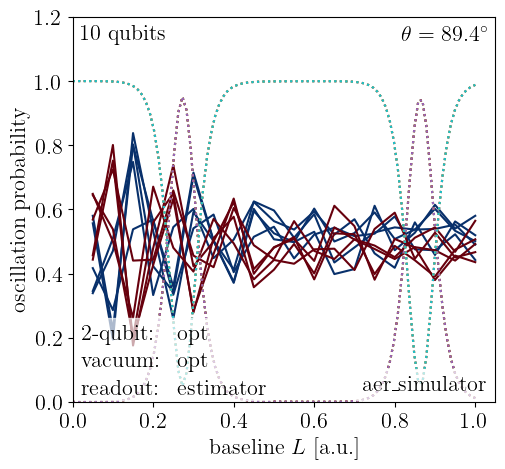

In [20]:
plt.figure(figsize=(12,5))

# plot energy spectrum
# plt.subplot(121)
# for j in range(len(E_table)):
#     plt.errorbar(E_table[j], P[t_steps][j], err[t_steps][j], ls='', capsize=3, marker='.', markersize=10,
#                  color='blue' if flavor[j]=='e' else 'red')
# #plt.plot(np.unique(E_table), np.sin(2*theta)**2 * np.sin(dmsq*L/(4*np.unique(E_table)))**2, label='vacuum osc.')
# plt.xlabel('energy')
# plt.ylabel('oscillation probability')
# plt.ylim(0,1)
# #plt.legend(loc='lower right')

# plot oscillation probability as a function of time
plt.subplot(122)
if n_flavors > 1:
    my_colors2  = {'e':    matplotlib.colormaps['Blues'], #matplotlib.colormaps['Greens'],
                   'ebar': matplotlib.colormaps['Reds'], #matplotlib.colormaps['Purples'],
                   'x':    matplotlib.colormaps['Reds'],
                   'xbar': matplotlib.colormaps['Oranges'],
                   'a':    matplotlib.colormaps['Reds']}
    nc = len(np.unique(E_table))
    my_colors = [my_colors2[flavor[i]]((j+1)/nc) for i, j in enumerate(np.searchsorted(np.unique(E_table), E_table))]
else:
    my_colors = [plt.rcParams['axes.prop_cycle'].by_key()['color'][j] for j in np.searchsorted(np.unique(E_table), E_table)]
#my_colors = ['black',u'#E24A33', u'#348ABD', u'#988ED5', u'#777777', u'#FBC15E', u'#8EBA42', u'#FFB5B8']
my_ls      = ['-','--',':','-.']
flavor_labels  = {'e': '$\\nu_e$', 'ebar': '$\\bar\\nu_e$', 'x': '$\\nu_x$', 'xbar': '$\\bar\\nu_x$', 'a': '$\\nu_\\alpha$'}
    
# plot results from quantum simulation
if readout_method == 'estimator':
    L_table = np.array([ k[0]*L/t_steps for k in evs.keys() ])
    for j in range(n_qubits):
        plt.plot(L_table, [0.5*(1+evs[k][j]) for k in evs.keys()], color=my_colors[j],
                 label=f'{flavor_labels[flavor[j]]:s}, $E = {E_table[j]:.2f}$, $\\theta = {theta_table[j]:.2f}$')
else:
    L_table = np.array([ k*L/t_steps for k in counts.keys() ])
    for j in range(n_qubits):
#        plt.errorbar(L_table, [P[k][j] for k in counts.keys()], [err[k][j] for k in counts.keys()],
#                     ls='', capsize=3, marker='.', markersize=10, color=my_colors[j])
        plt.plot(L_table, [P[k][j] for k in counts.keys()], color=my_colors[j],
                 label=f'{flavor_labels[flavor[j]]:s}, $E = {E_table[j]:.2f}$, $\\theta = {theta_table[j]:.2f}$')
#                     color=my_colors[flavor[j]]((j%n_modes)/n_modes),

# Analytic results in the Raffelt-Sigl polarization vector formalism
if toy_model == 'bipolar':       
#     # RS prediction from dedicated routine (2 modes)
#     L_table_hires = np.linspace(0, L_table[-1], 1000)
#     sol           = P_osc_RS_bipolar(L_table_hires, theta=theta, Delta=[Delta[0]]*2, lam=0.,
#                                      J=np.array([[J[0,0], J[0,n_modes]], [J[n_modes,0], J[n_modes,n_modes]]]))
#     P_table       = np.reshape(sol.y, (2,3,len(L_table_hires)))
#     plt.plot(L_table_hires, 0.5*(1-P_table[0,2,:]), color='#0000bb', ls=':', label=r'$\nu$')
#     plt.plot(L_table_hires, 0.5*(1-P_table[1,2,:]), color='#bb0000', ls=':', label=r'$\bar\nu$')
    
    # RS prediction from generic routine (N modes)
    L_table_hires = np.linspace(0, L_table[-1], 100)
    sol           = P_osc_RS(L_table_hires, theta, Delta, 0., J)
    P_table       = np.reshape(sol.y, (2*n_modes,3,len(L_table_hires)))
    for k in range(len(P_table)):
        plt.plot(L_table_hires, 0.5*(1-P_table[k,2,:]), ls=':')

elif toy_model == '2-beam':
    L_table_hires = np.linspace(0, L_table[-1], 200)
    ini_state = np.array([1+0j, 0+0j, np.cos(alpha)+0j, np.sin(alpha)+0j])   # (beam 1, beam 2)
    def rhs_2beam(t, y):
        N2 = np.count_nonzero(flavor=='a')

        # n+n scenario (equal number of neutrinos in both beams)
        m = n_qubits // 2
        H11, H12, H21, H22 = J[:m,:m], J[:m,m:], J[m:,:m], J[m:,m:]
        if np.sum(np.abs(H11))==0. and np.sum(np.abs(H22))==0. and np.all(H12==H21):
            H = N2 * J[0,n_qubits-1] * linalg.block_diag([[np.abs(y[2])**2,    y[2]*np.conj(y[3])],
                                                          [np.conj(y[2])*y[3], np.abs(y[3])**2]],
                                                         [[np.abs(y[0])**2,    y[0]*np.conj(y[1])],
                                                          [np.conj(y[0])*y[1], np.abs(y[1])**2]])
        else:
            H11, H12, H21, H22 = J[:1,:1], J[:1,1:], J[1:,:1], J[1:,1:]
            if np.sum(np.abs(H11))==0. and np.sum(np.abs(H22))==0. and np.all(H12==H21):
                # (1+n) scenario (only one neutrino in beam 1, many in beam 2)
                H = N2 * J[0,n_qubits-1] * linalg.block_diag([[np.abs(y[2])**2,    y[2]*np.conj(y[3])],
                                                              [np.conj(y[2])*y[3], np.abs(y[3])**2]],
                                                             [[1,0],
                                                              [0,1]])
            else:
                raise ValueError('J has an unknown form')

        return -1j * H @ y
    sol = integ.solve_ivp(rhs_2beam, (0, L), ini_state, t_eval=L_table_hires, readout_method='BDF')
    plt.plot(sol.t, np.abs(sol.y[0])**2)
    plt.plot(sol.t, np.abs(sol.y[2])**2)
    
    # L_table_hires = np.linspace(0, L_table[-1], 100)
    # sol           = P_osc_RS(L_table_hires, theta, Delta, 0., J, initial_flavors=flavor, alpha=alpha)
    # P_table       = np.reshape(sol.y, (n_qubits,3,len(L_table_hires)))
    # for j in range(n_qubits):
    #     plt.plot(L_table_hires, 0.5*(1+P_table[j,2,:]), color=my_colors[j], ls=my_ls[j%len(my_ls)])
        
else:
    L_table_hires = np.linspace(0, L_table[-1], 200)
    sol           = P_osc_RS(L_table_hires, theta, Delta, 0., J, initial_flavors=flavor, alpha=alpha)
    P_table       = np.reshape(sol.y, (n_qubits,3,len(L_table_hires)))
    E_unique, k_table = np.unique(E_table, return_index=True)
    for j, k in enumerate(k_table):
        plt.plot(L_table_hires, 0.5*(1-P_table[k,2,:]), color=my_colors[j], ls=my_ls[j], label=f'$E = {E_unique[k]}$')

plt.xlabel('baseline $L$ [a.u.]')
plt.ylabel('oscillation probability')
plt.annotate(f'\\begin{{tabular}}{{ll}}2-qubit:&{algorithm}\\\\vacuum:&{vacuum_term}\\\\readout:&{readout_method}\\end{{tabular}}',
             (0.02,0.02), xycoords='axes fraction',
             ha='left', va='bottom', backgroundcolor='#ffffffaa')
plt.annotate(f'{backend.name}', (0.98,0.02), xycoords='axes fraction',
             ha='right', va='bottom', backgroundcolor='#ffffffaa')
plt.annotate(f'{n_qubits} qubits', (0.02,0.98), xycoords='axes fraction',
             ha='left', va='top', backgroundcolor='#ffffffaa')
plt.annotate(f'$\\theta = {theta*180/np.pi:.1f}^\\circ$', (0.98,0.98), xycoords='axes fraction',
             ha='right', va='top', backgroundcolor='#ffffffaa')
plt.ylim(0, 1.2)
plt.xlim(left=0)

#plt.annotate(f'backend: {backend.name}', (0.98,0.98), xycoords='axes fraction', ha='right', va='top')
#plt.legend(loc='upper left', fontsize=12)
#plt.savefig('sn-quant-toy-model.pdf')
plt.show()

/Users/jkopp/.pyenv/versions/3.9.0/lib/python3.9/site-packages/scipy/integrate/_ivp/base.py:23: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(fun(t, y), dtype=dtype)


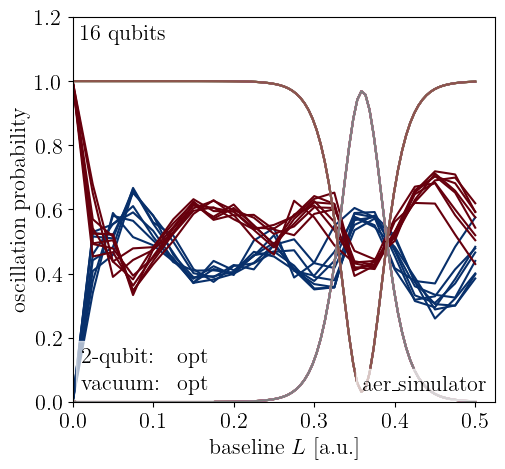

In [45]:
# all-to-all interactions in each step

/Users/jkopp/.pyenv/versions/3.9.0/lib/python3.9/site-packages/scipy/integrate/_ivp/base.py:23: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(fun(t, y), dtype=dtype)


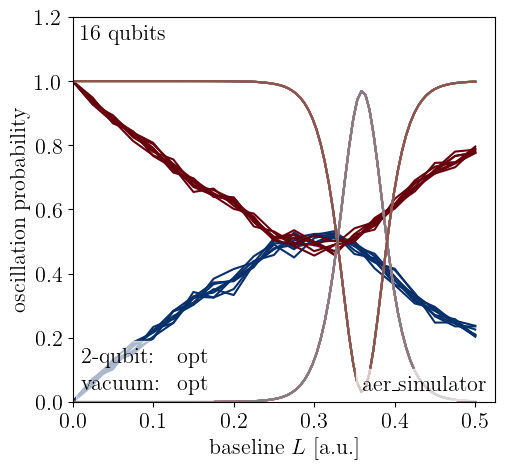

In [38]:
# interaction with 1 nu, 1 nu-bar per step

/Users/jkopp/.pyenv/versions/3.9.0/lib/python3.9/site-packages/scipy/integrate/_ivp/base.py:23: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(fun(t, y), dtype=dtype)


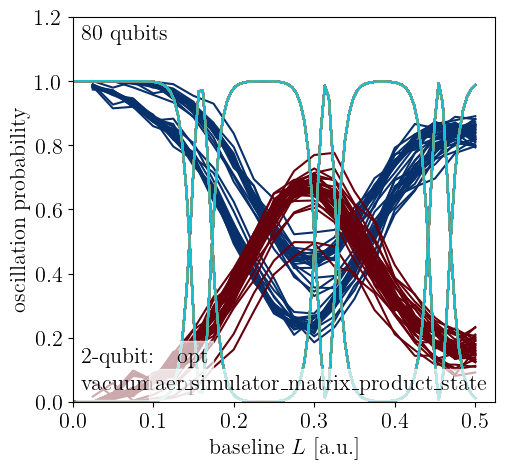

In [27]:
# interaction with 1 nu, 1 nu-bar per step

/Users/jkopp/.pyenv/versions/3.9.0/lib/python3.9/site-packages/scipy/integrate/_ivp/base.py:23: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(fun(t, y), dtype=dtype)


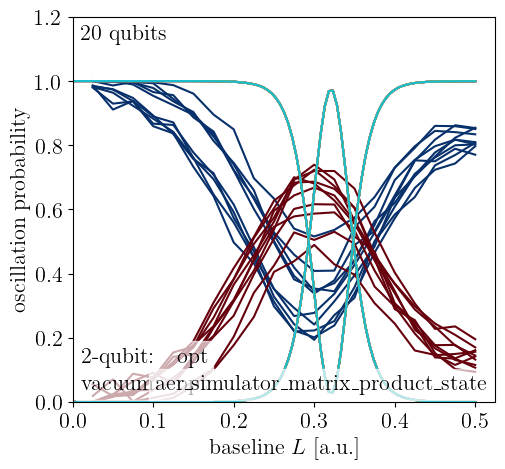

#### Archived Results

##### Experiments with Bell States

The following is for a bipolar oscillation scenario (which doesn't reproduce the mean-field result). See `sn-quant-2025-05-19.ipynb` for a snapshot of the code at the time these plots were generated.

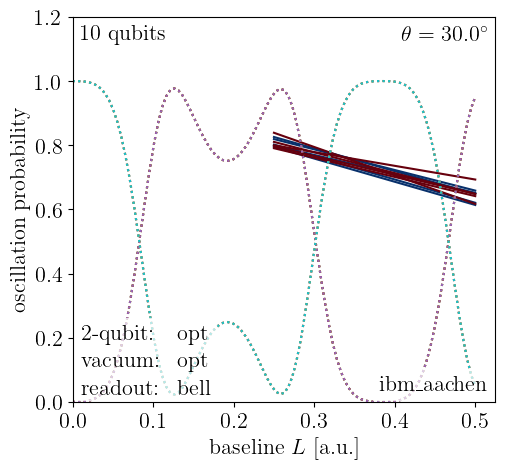

In [105]:
# Bell runs
# ---------
# with twirling and measurement mitigation + gen3-turbo execution pass

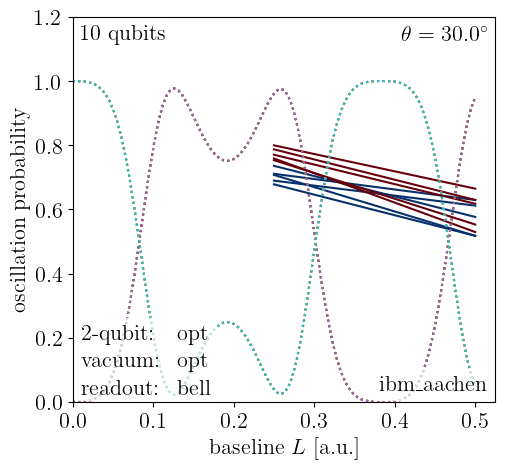

In [101]:
# with twirling and measurement mitigation

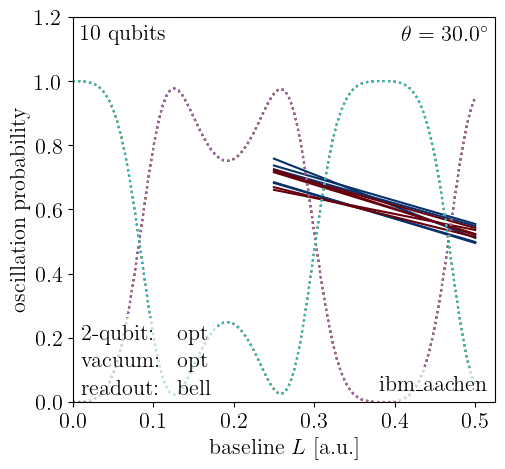

In [25]:
# w/ twirling

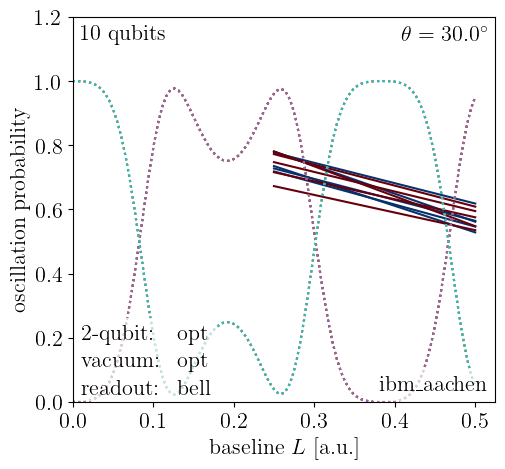

In [22]:
# w/o twirling

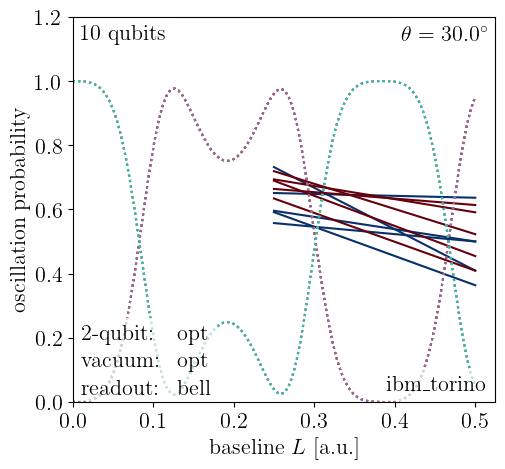

In [33]:
# submitting job (1,) to ibm_torino (n_logical=10, n_physical=20, n_layers=446, n_2qubit=1730
#   (transpiled: n_layers=502, n_2qubit=829
# submitting job (2,) to ibm_torino (n_logical=10, n_physical=20, n_layers=881, n_2qubit=3440
#   (transpiled: n_layers=987, n_2qubit=1644

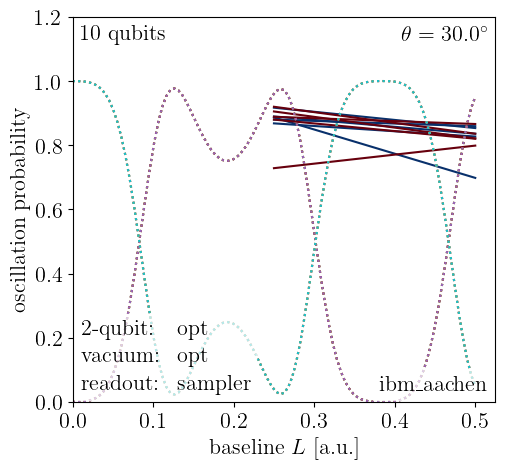

In [109]:
# normal (non-Bell) runs
# ----------------------
# noisy simulation with mitigation (dynamical decoupling, readout mitigation, gen3-turbo, twirling)

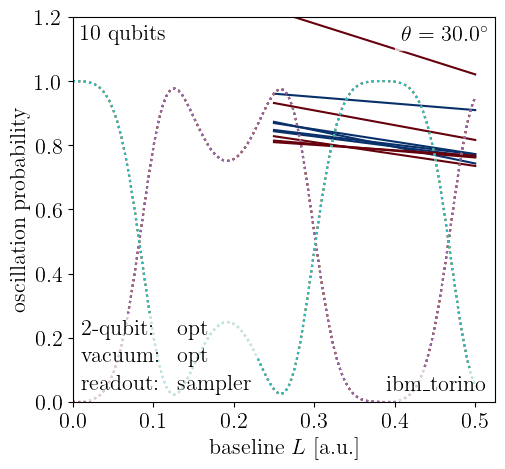

In [291]:
# noisy simulation with only dynamical decoupling

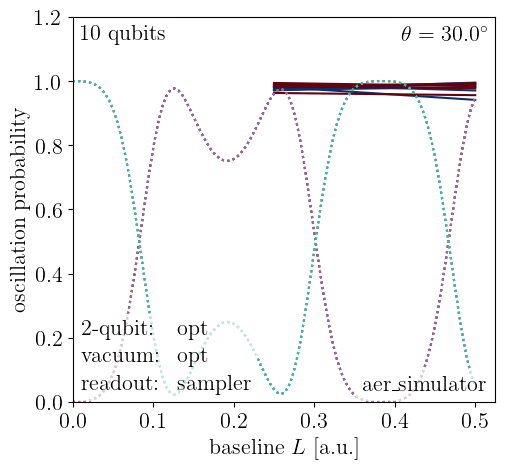

In [319]:
# noiseless simulation

##### Other results

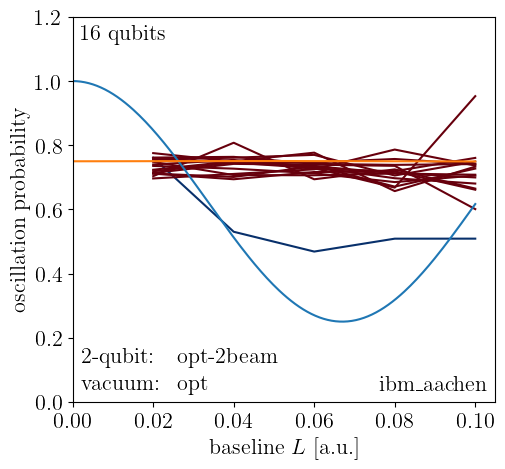

In [132]:
# resilience 2 + PEA

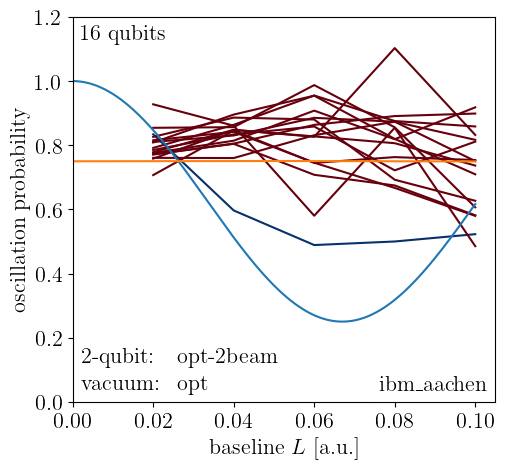

In [128]:
# resilience 2, no other EC

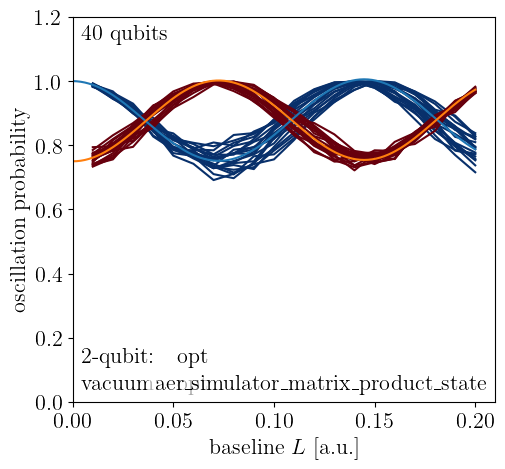

In [112]:
# 2-beam scenario (n+n neutrinos), alpha=30 degrees

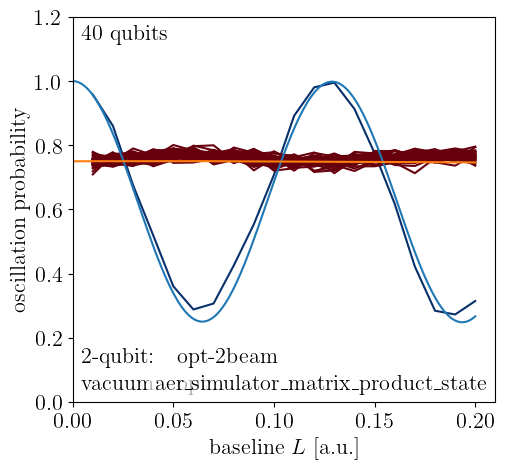

In [95]:
# 2-beam scenario (1+n neutrinos), alpha=30 degrees

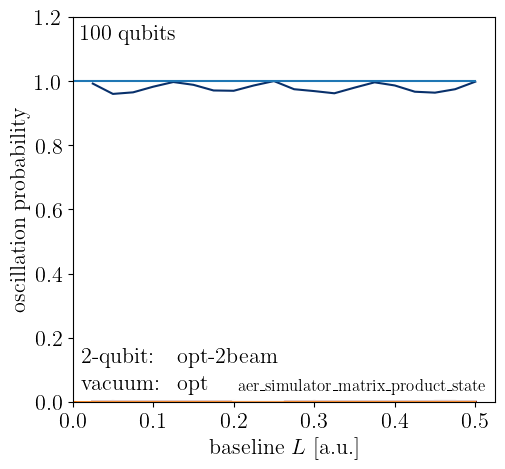

In [53]:
# 2-beam scenario (1+n neutrinos), alpha=0.

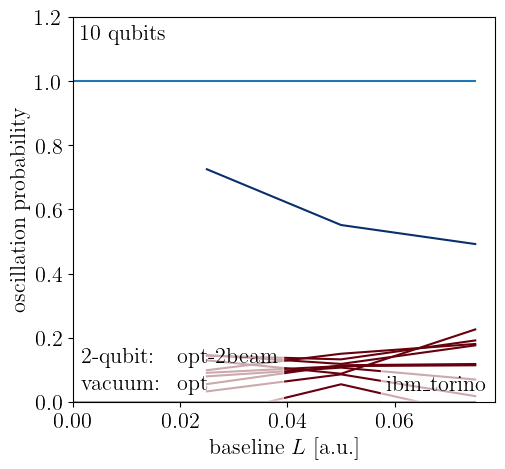

In [283]:
# IBM Torino 05.05.2025 (Estimator resilience 2 + PEA, opt-2beam)

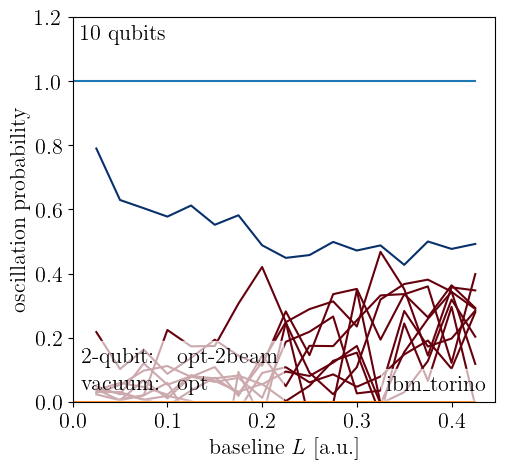

In [273]:
# IBM Torino 06.05.2025 (Estimator resilience 2, opt-2beam)

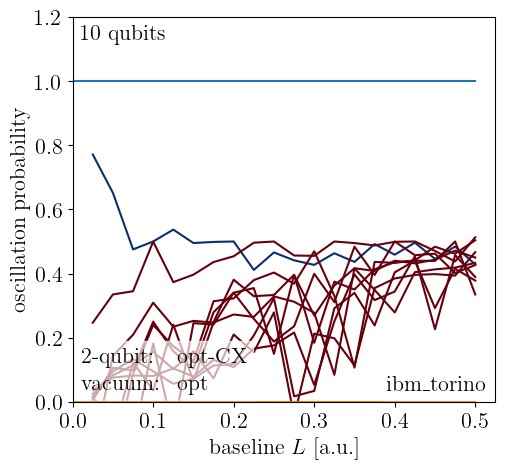

In [162]:
# IBM Torino 05.05.2025 (Estimator resilience 2, opt-CX)

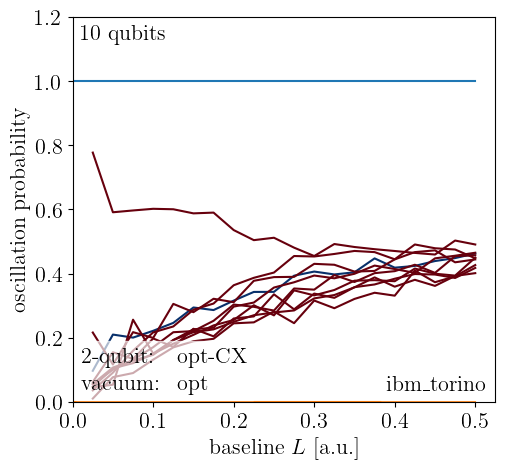

In [253]:
# IBM Torino 30.05.2025 (readout mitigation, Pauli Twirling, opt)

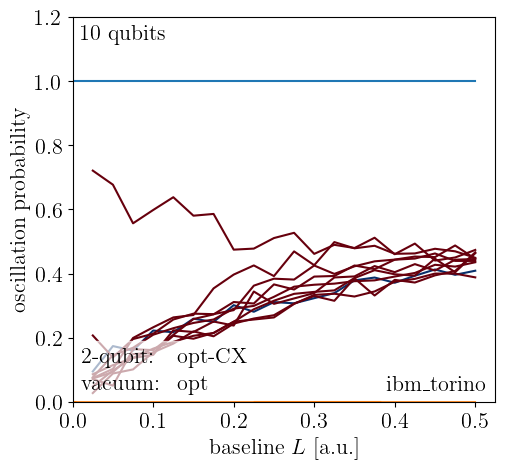

In [246]:
# IBM Torino 27.05.2025 (readout mitigation, opt-CX)

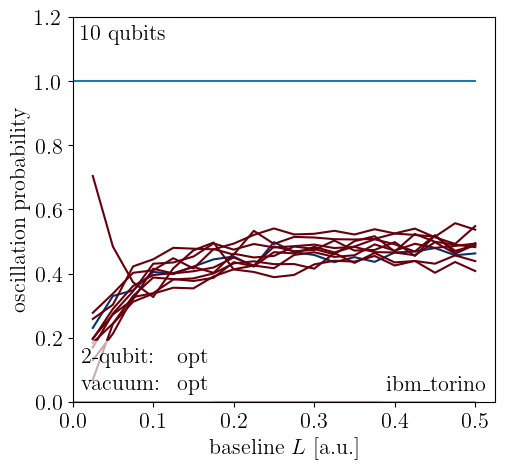

In [242]:
# IBM Torino 27.05.2025 (no EC, opt)

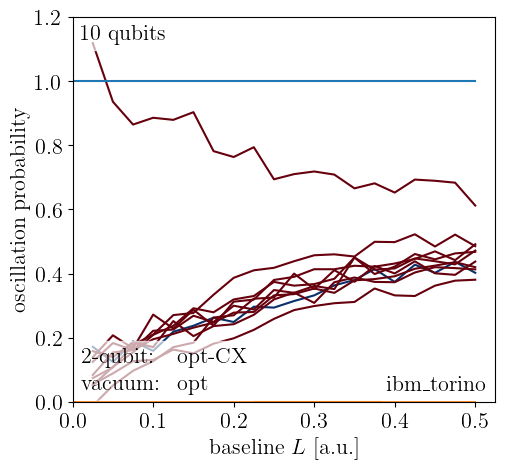

In [237]:
# IBM Torino 25.05.2025 (no EC, opt-CX)

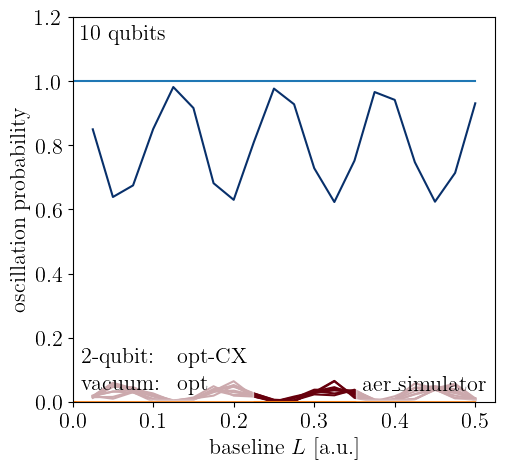

In [302]:
# noiseless AER (Estimator)

/Users/jkopp/.pyenv/versions/3.9.0/lib/python3.9/site-packages/scipy/integrate/_ivp/base.py:23: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(fun(t, y), dtype=dtype)


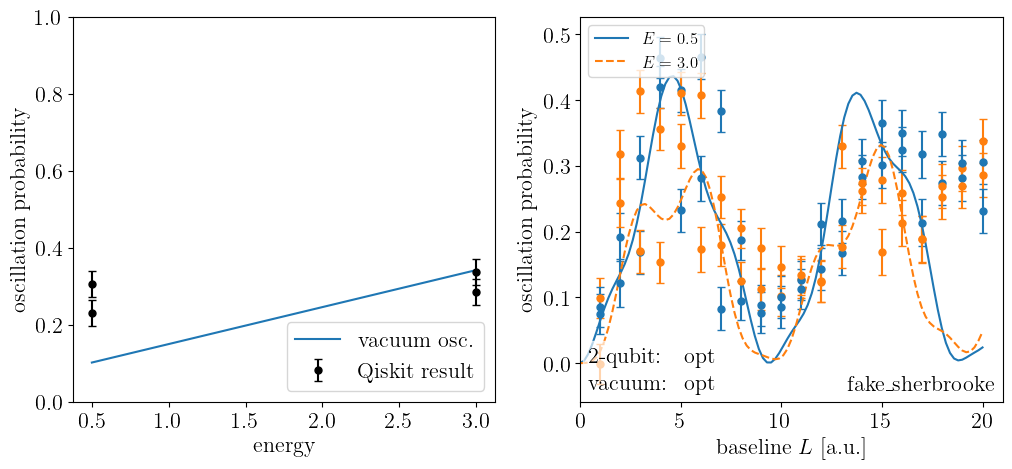

/Users/jkopp/.pyenv/versions/3.9.0/lib/python3.9/site-packages/scipy/integrate/_ivp/base.py:23: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(fun(t, y), dtype=dtype)


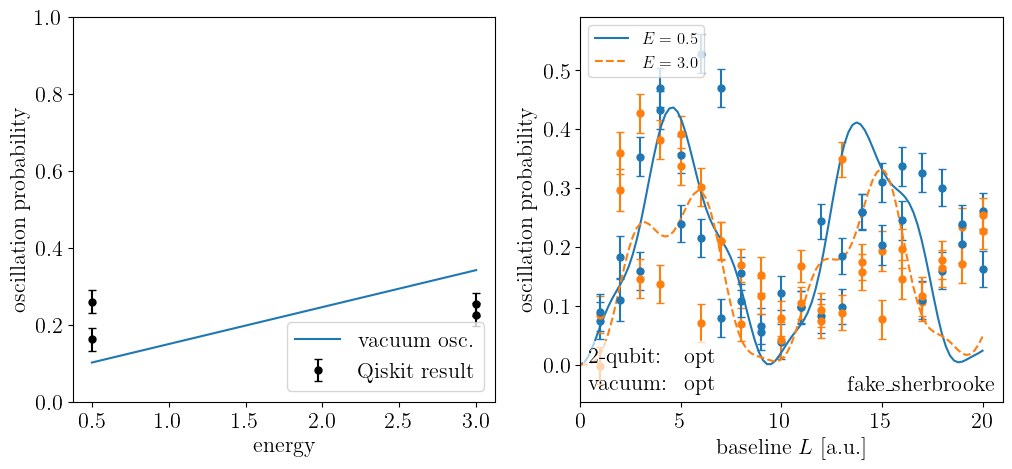

/Users/jkopp/.pyenv/versions/3.9.0/lib/python3.9/site-packages/scipy/integrate/_ivp/base.py:23: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(fun(t, y), dtype=dtype)


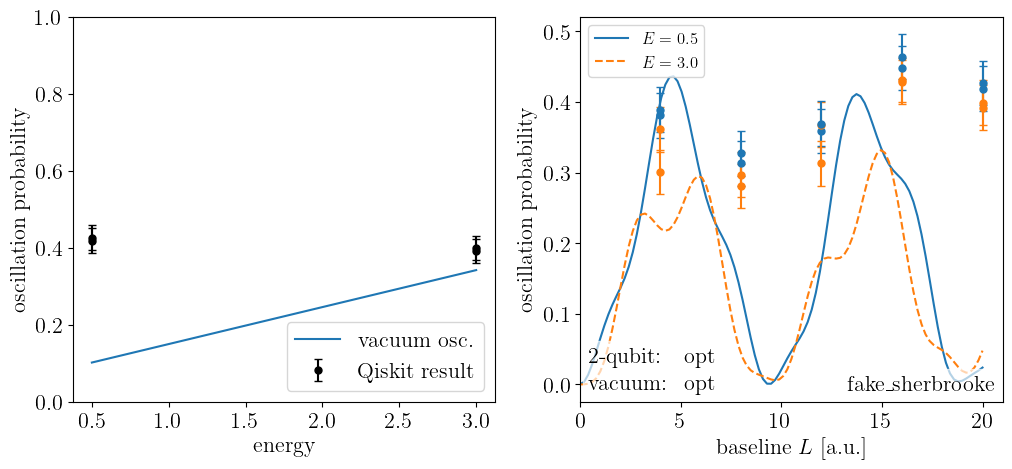

In [639]:
# no noise mitigation

/Users/jkopp/.pyenv/versions/3.9.0/lib/python3.9/site-packages/scipy/integrate/_ivp/base.py:23: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(fun(t, y), dtype=dtype)


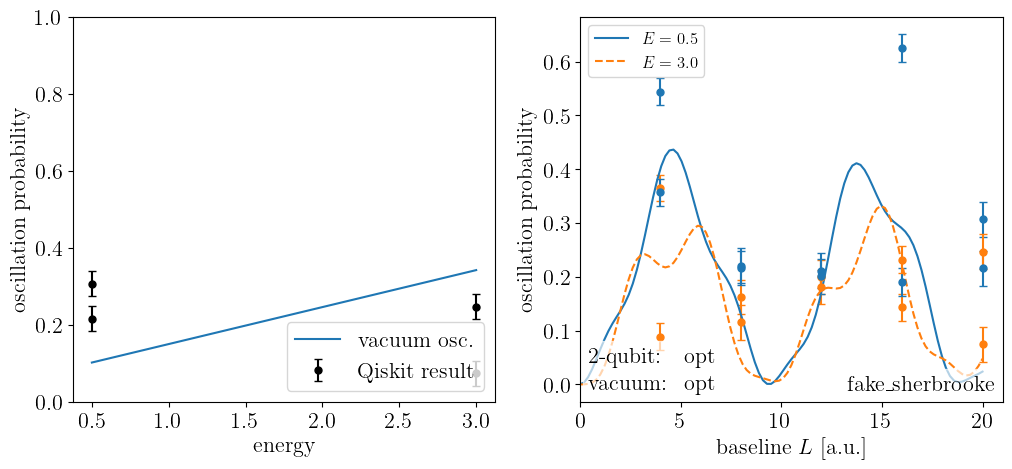

In [633]:
# ROM, ZNE exp

/Users/jkopp/.pyenv/versions/3.9.0/lib/python3.9/site-packages/scipy/integrate/_ivp/base.py:23: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(fun(t, y), dtype=dtype)


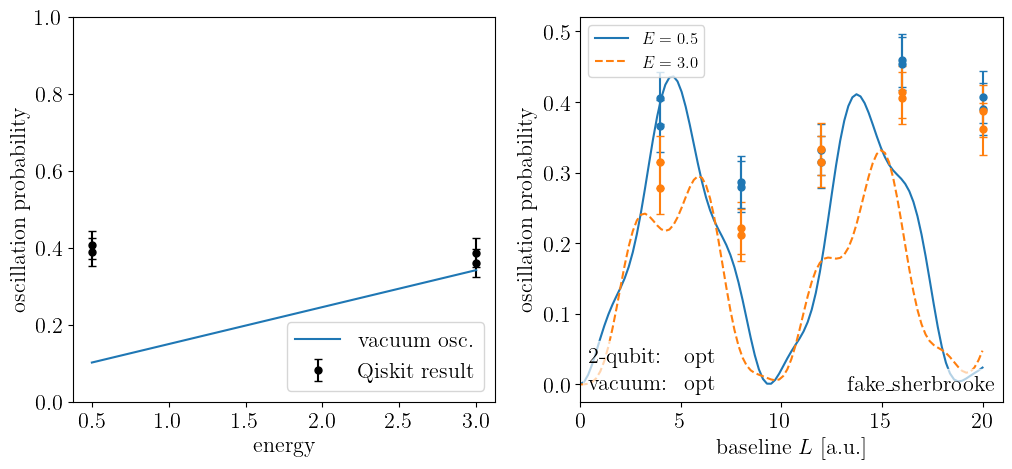

In [631]:
# ROM, ZNE linear

/Users/jkopp/.pyenv/versions/3.9.0/lib/python3.9/site-packages/scipy/integrate/_ivp/base.py:23: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(fun(t, y), dtype=dtype)


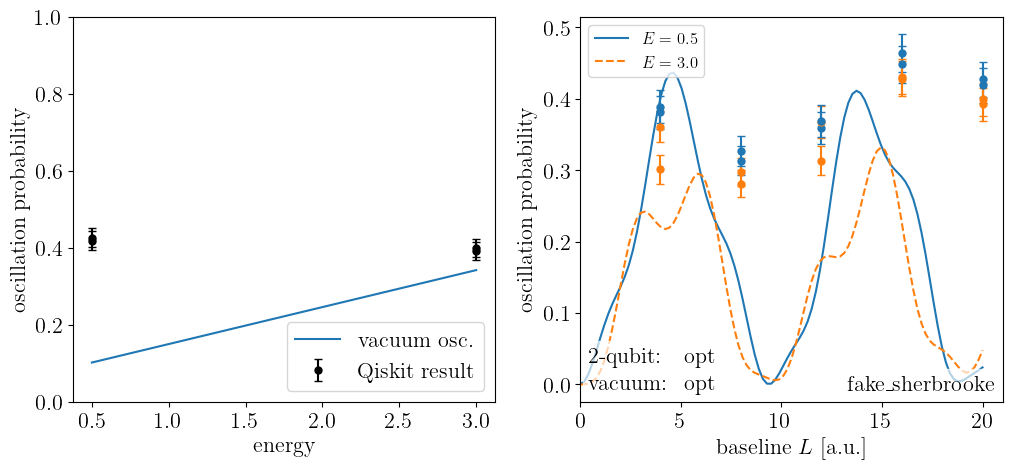

In [195]:
# no noise mitigation

#### Bipolar Experiments

In [14]:
def U_self_int(theta):
    """the exponential of the neutrino interaction Hamiltonian,
       see Friedland & Lunardini, https://arxiv.org/abs/hep-ph/0304055
    """
    return np.array([[np.exp(-1j*theta), 0,                          0,                          0],
                     [0,                 0.5*( 1+np.exp(-1j*theta)), 0.5*(-1+np.exp(-1j*theta)), 0],
                     [0,                 0.5*(-1+np.exp(-1j*theta)), 0.5*( 1+np.exp(-1j*theta)), 0],
                     [0,                 0,                          0,                          np.exp(-1j*theta)]])

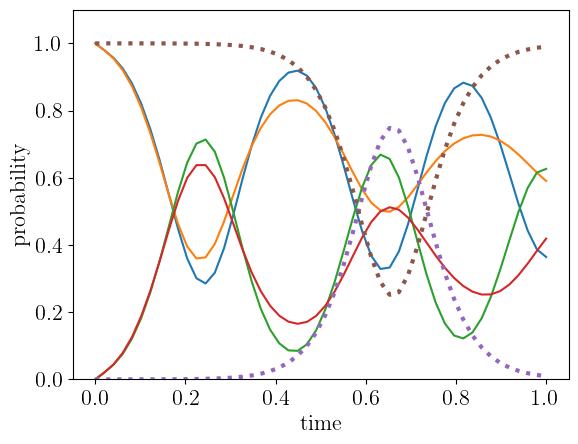

In [490]:
# self-interacting 4-neutrino system
L          = 1
t_steps    = 50
theta      = np.pi/2 - 0.01
dmsq       = 1.0
Delta      = dmsq / (2*0.1) * np.array([1.,1.,-1.,-1.])  # minus sign for the kinetic terms for antineutrinos
b          = np.array([np.sin(2*theta), 0, -np.cos(2*theta)]) # the structure of the vacuum Hamiltonian in the Pauli basis
J          = 5 * np.ones((4, 4))
nu_mask    = [True,True,False,False]
nubar_mask = [False,False,True,True]

# mean-field solution
L_table = np.linspace(0, L, t_steps)
sol     = P_osc_RS(L_table, theta, np.array([Delta[0], -Delta[0]]), 0., 2*abs(J[::2,::2])) # factor 2 because we compare to a system with 2 nu + 2 nubar
P_table = np.reshape(sol.y, (2,3,len(L_table)))

# J[:,nubar_mask] *= -1    # minus sign for the effect of anti-neutrino modes on both neutrino and anti-neutrino modes
#                          # note that, in the quantum computing, we use the convention of Hannestad Raffelt Sigl Wong (https://arxiv.org/abs/astro-ph/0608695),
#                          # where both P and \bar{P} point in the positive z-direction for the electron flavour. In contrast, in P_osc_RS, we use the
#                          # convention from Duan, Fuller, Carlson (https://arxiv.org/abs/1001.2799), where the P(\bar\nu_e) points in the negative z-direction.

# as neutrinos don't interact with themselves in the quantum algorithm, their same-sign partner is given double weight
# J[np.ix_(nu_mask,nu_mask)]       *= 2
# J[np.ix_(nubar_mask,nubar_mask)] *= 2

# determine step size based on derivative of classical solution
L_table_quant  = np.concatenate(([0], np.cumsum(1/np.abs(np.diff(P_table[0,2])))))
L_table_quant *= L_table[-1]/L_table_quant[-1]
L_table_quant = L_table# FIXME FIXME
dt_table       = np.diff(L_table_quant)

# loop over time steps
n_qubits = 4
qc = qk.QuantumCircuit(n_qubits)
for j in np.nonzero(nubar_mask): # we use Duan and Fuller's convention here where \nu_e = |0> and \bar\nu_e = |1>
    qc.x(j)
for i in range(len(dt_table)):
    dt = dt_table[i]

    # artificially remove entanglement by resetting each qubit to a non-entangled state
    qc_no_save = qc.remove_final_measurements(inplace=False)
    qc_no_save.data = [inst for inst in qc.data if inst.operation.name != 'save_density_matrix']
    sv = qk.quantum_info.Statevector(qc_no_save)
    rho = [ np.array(qk.quantum_info.partial_trace(sv, [j for j in range(n_qubits) if j != k])) for k in range(n_qubits) ]
    p   = [ np.real(np.array([ np.trace(sigma_1@rho[k]), np.trace(sigma_2@rho[k]), np.trace(sigma_3@rho[k]) ])) for k in range(n_qubits) ]
    
    # # p[2] = np.array([-P_table[1,0,i], -P_table[1,1,i], -P_table[1,2,i]])
    # # # p[2] = np.array([p[0][0], -p[0][1], p[0][2]])
    # p[1] = p[0]
    # p[3] = p[2]

    # # p[0] = np.array([P_table[0,0,i], P_table[0,1,i], P_table[0,2,i]])
    # # p[1] = p[0]
    # # p[3] = p[2]

    # reset qubits to a non-entangled state to emulate the mean-field picture
    qc.reset(range(n_qubits))
    for j in range(n_qubits):
        qc.ry(np.arccos(p[j][2]), j)
        qc.rz(np.arctan2(p[j][1], p[j][0]), j)

    # print(i, p[0], p[1], p[2], p[3])
    # print(i, P_table[0,:,i], P_table[1,:,i])
    
    qc.save_density_matrix(label=str(i+1))

    # strict mean-field: single-qubit evolution only, no entangling gates
    # for j in range(4):
    #     qc.rx(-dt*Delta[j]*b[0], j)
    #     qc.rz(-dt*Delta[j]*b[2], j)
    # for j in range(4):
    #     for k in range(4):
    #         # qc.rx(-dt*J[j,k] * P_table[k//2,0,i], j)
    #         # qc.ry(-dt*J[j,k] * P_table[k//2,1,i], j)
    #         # qc.rz(-dt*J[j,k] * P_table[k//2,2,i], j)
            
    #         qc.rx(-dt*J[j,k] * p[k][0], j)
    #         qc.ry(-dt*J[j,k] * p[k][1], j)
    #         qc.rz(-dt*J[j,k] * p[k][2], j)
    
    # for j in range(4):
    #     for k in range(j+1,4):
    #         qc.rx(-dt*Delta[j]*b[0]/3, j)
    #         qc.rz(-dt*Delta[j]*b[2]/3, j)
    #         qc.rx(-dt*Delta[k]*b[0]/3, k)
    #         qc.rz(-dt*Delta[k]*b[2]/3, k)

    #         qc.rx(-dt*J[j,k] * p[k][0], j)
    #         qc.ry(-dt*J[j,k] * p[k][1], j)
    #         qc.rz(-dt*J[j,k] * p[k][2], j)
    #         qc.rx(-dt*J[k,j] * p[j][0], k)
    #         qc.ry(-dt*J[k,j] * p[j][1], k)
    #         qc.rz(-dt*J[k,j] * p[j][2], k)

    # evolution allowing for entanglement
    for j in range(4):
        for k in range(j+1,4):
            qc.rx(-dt*Delta[j]*b[0]/3, j)
            qc.rz(-dt*Delta[j]*b[2]/3, j)
            qc.rx(-dt*Delta[k]*b[0]/3, k)
            qc.rz(-dt*Delta[k]*b[2]/3, k)
            # qc.unitary(U_self_int(-dt*J[j,k]), [j, k])  # FIXME I don't understand why I need an extra factor of 2 here
            qc.rxx(-dt*J[j,k], j, k)      # self-interaction
            qc.ryy(-dt*J[j,k], j, k)
            qc.rzz(-dt*J[j,k], j, k)
# end for (time steps)

# save final state
qc.save_density_matrix(label=str(i+2))

# run simulation    
sim = aer.AerSimulator(method="statevector", precision="double", zero_threshold=1e-14, validation_threshold=1e-12)
result = sim.run(qc).result()

# extract and plot results
n_qubits = qc.num_qubits
rho_reduced = [ { k : np.array(qk.quantum_info.partial_trace(result.data()[k], [q for q in range(n_qubits) if q != j])) for k in result.data().keys() } for j in range(n_qubits) ]
pp = np.array([ [[float(k), rho_reduced[j][k][0,0]] for k in rho_reduced[j].keys() ] for j in range(n_qubits) ])
pp = np.abs(np.take_along_axis(pp, pp[:,:,0].argsort(axis=1)[:,:,None], axis=1))
for j in range(n_qubits):
    plt.plot(L_table_quant, pp[j,:,1])
for k in range(len(P_table)):
    plt.plot(L_table, 0.5*(1-P_table[k,2,:]), ls=':', lw=3)
plt.ylim(0,1.1)
plt.xlabel('time')
plt.ylabel('probability')
plt.show()

#### Miscellaneous Tests

In [388]:
# the correct (?) interaction term
def U(theta):
    return np.array([[np.exp(-1j*theta), 0,                          0,                          0],
                     [0,                 0.5*( 1+np.exp(-1j*theta)), 0.5*(-1+np.exp(-1j*theta)), 0],
                     [0,                 0.5*(-1+np.exp(-1j*theta)), 0.5*( 1+np.exp(-1j*theta)), 0],
                     [0,                 0,                          0,                          np.exp(-1j*theta)]])
    
qc = qk.QuantumCircuit(2)
qc.unitary(U(np.pi/2), [0, 1])
backend = get_backend('aer')
isa_qc = qk.transpile(qc, basis_gates=['cx','cz','cy','rxx','ryy','rzz','rx','ry','rz','x','y','z','s','sx','ecr'])
isa_qc.draw()

global phase: π/8
       ┌────────┐ ┌──────────┐┌───────────┐┌────────────┐┌────────────┐»
q_0: ──┤ Rz(-π) ├─┤ Rx(-π/4) ├┤0          ├┤ Rz(2.1007) ├┤ Ry(1.4238) ├»
     ┌─┴────────┴┐├─────────┬┘│  Rxx(π/2) │└┬─────────┬─┘└┬──────────┬┘»
q_1: ┤ Ry(-3π/4) ├┤ Rz(π/2) ├─┤1          ├─┤ Ry(π/2) ├───┤ Rz(-π/4) ├─»
     └───────────┘└─────────┘ └───────────┘ └─────────┘   └──────────┘ »
«     ┌─────────────┐┌───────────┐┌─────────────┐┌────────────┐┌──────────────┐»
«q_0: ┤ Rz(-1.0409) ├┤0          ├┤ Rz(-2.8567) ├┤ Ry(2.5936) ├┤ Rz(-0.28492) ├»
«     └─────────────┘│  Rxx(π/2) │├─────────────┤└┬──────────┬┘└┬────────────┬┘»
«q_1: ───────────────┤1          ├┤ Rz(0.61548) ├─┤ Ry(2π/3) ├──┤ Rz(2.5261) ├─»
«                    └───────────┘└─────────────┘ └──────────┘  └────────────┘ »
«     ┌───────────┐┌──────────┐ ┌────────┐
«q_0: ┤0          ├┤ Rx(-π/4) ├─┤ Rz(-π) ├
«     │  Rxx(π/2) │├─────────┬┘┌┴────────┤
«q_1: ┤1          ├┤ Ry(π/2) ├─┤ Rz(π/4) ├
«     └───────────┘└─────────┘ └─────────┘

#### Plot for ERC Proposal

/var/folders/mn/vwbz05810sq7zq664_pw0ll40000gn/T/ipykernel_57031/1281010776.py:23: RuntimeWarning: invalid value encountered in sqrt
  err[k] = [ np.sqrt(p[1]/(p[0]+p[1])**2 + p[1]**2/(p[0]+p[1])**3)  for p in projected_counts[k] ]
/Users/jkopp/.pyenv/versions/3.9.0/lib/python3.9/site-packages/scipy/integrate/_ivp/base.py:23: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(fun(t, y), dtype=dtype)


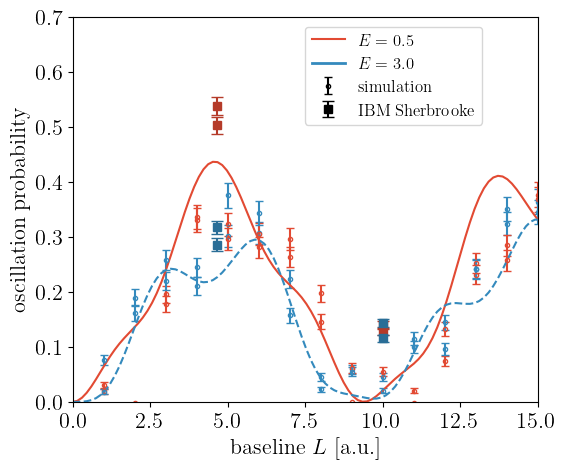

In [302]:
my_colors1 = [u'#E24A33', u'#348ABD', u'#988ED5', u'#777777', u'#FBC15E', u'#8EBA42', u'#FFB5B8']
my_colors2 = ['black',u'#E24A33', u'#348ABD', u'#988ED5', u'#777777', u'#FBC15E', u'#8EBA42', u'#FFB5B8']
my_ls      = ['-','--',':','-.']
plt.figure(figsize=(6,5))

input_files = [base_dir + "/data/qiskit-counts-sim.dat", base_dir + "/data/qiskit-counts-data.dat"]
for i, fname in enumerate(input_files):
    # load counts from file
    with open(fname, "rb") as f:
        [job_ids,
         L, t_steps, t_samples, n_flavors,
         E_table, theta_table, phi_table,
         n_modes, n_qubits,
         counts] = pickle.load(f)
        
    # plot oscillation probability as a function of time
    projected_counts = {}
    P                = {}
    err              = {}
    for k in counts.keys():
        projected_counts[k] = project_counts(counts[k])
        P[k] = [ p[1]/(p[0]+p[1]) for p in projected_counts[k] ]  # oscillation probability
        err[k] = [ np.sqrt(p[1]/(p[0]+p[1])**2 + p[1]**2/(p[0]+p[1])**3)  for p in projected_counts[k] ]

    # plot results from quantum simulation
    my_colors = my_colors1 #if i==0 else my_colors2
    L_table = np.array([ k*L/t_steps for k in counts.keys() ])
    for j in range(n_qubits):
        c = np.array(colors.hex2color(my_colors[np.where(E_table[j]==np.unique(E_table))[0][0]]))
        if i==0:
            plt_sim = plt.errorbar(L_table, [P[k][j] for k in counts.keys()], [err[k][j] for k in counts.keys()],
                                   color=c, ls='', capsize=3, marker='.', markersize=6, markerfacecolor='none',
                                   label='sim.')
        else:
            plt_data = plt.errorbar(L_table, [P[k][j] for k in counts.keys()], [err[k][j] for k in counts.keys()],
                                    color=0.8*c, ls='', capsize=4, marker='s', markersize=6,
                                    label='data')

# Calculation in the Raffelt-Sigl polarization vector formalism
L_table_hires = np.linspace(0, 30, 200)
sol           = P_osc_RS(L_table_hires, theta, Delta, 0., J)
P_table       = np.reshape(sol.y, (n_modes,3,len(L_table_hires)))
E_unique, k_table = np.unique(E_table, return_index=True)
for j, k in enumerate(k_table):
    plt.plot(L_table_hires, 0.5*(1-P_table[k,2,:]), color=my_colors1[j], ls=my_ls[j], label=f'$E = {E_unique[k]}$')

plt.xlabel('baseline $L$ [a.u.]')
plt.ylabel('oscillation probability')
plt.xlim(0,15)
plt.ylim(0, .7)
plt.xlim(left=0)

handles, labels = plt.gca().get_legend_handles_labels()
legend_sim  = plt.errorbar([-1,-1], [-1,-1], [1,1], color='black', ls='', capsize=3, marker='.', markersize=6, markerfacecolor='none',
                           label='simulation')
legend_data = plt.errorbar([-1,-1], [-1,-1], [1,1], color='black', ls='', capsize=4, marker='s', markersize=6,
                           label='IBM Sherbrooke')

legend_elements = [ matplotlib.lines.Line2D([0], [0], color=my_colors1[0], label=labels[0]),
                    matplotlib.lines.Line2D([0], [0], color=my_colors1[1], lw=2, label=labels[1]),
                    legend_sim, legend_data ]
plt.legend(handles=legend_elements, loc=(0.5,0.72), fontsize=12)

#plt.legend(loc='upper right', fontsize=12)
#plt.savefig('sn-quant-toy-model.pdf')
plt.show()

### Optimization of the Hamiltonian

In the following, we consider a system of two modes with $n_1$, $n_2$ neutrinos, respectively. We would like to represent this system with just 2 qubits. This is not possible exactly, so our goal is to find the best approximation we can.

Useful reference: https://uvadlc-notebooks.readthedocs.io/en/latest/tutorial_notebooks/JAX/tutorial4/Optimization_and_Initialization.html

In [405]:
import jax
import jax.numpy as jnp

def H(nq, theta, Delta, J):
    """Returns the Hamiltonian of the system.
    
       Arguments:
           nq:    number of qubits in each mode
           theta: the 2-flavor mixing angle
           Delta: the oscillation frequency (Delta m^2 / (2 E)) in each mode,
           J:     the self-interaction strength"""

    d = np.array(([Delta[0]] * nq[0]) + ([Delta[1]] * nq[1]))
    H = 0.5 * np.sin(2*theta) * np.sum([ d[j] * ft.reduce(np.kron, [sigma_1 if k==j else sigma_0 for k in range(np.sum(nq))])
                                       for j in range(sum(nq)) ], axis=0) \
      - 0.5 * np.cos(2*theta) * np.sum([ d[j] * ft.reduce(np.kron, [sigma_3 if k==j else sigma_0 for k in range(np.sum(nq))])
                                       for j in range(sum(nq)) ], axis=0) \
      + J * np.sum([ ft.reduce(np.kron, [s if k1==j1 else sigma_0 for k1 in range(nq[0])]
                                      + [s if k2==j2 else sigma_0 for k2 in range(nq[1])])
                         for j1 in range(nq[0]) for j2 in range(nq[1]) for s in [sigma_1,sigma_2,sigma_3]], axis=0)
    return H

def H_eff(a):
    """Returns the Hamiltonian of the effective 2-qubit system.
    
       Arguments:
           a:        vector of 6 auxiliary parameters"""

    return jnp.kron(sigma_0, 0.5*(a[0]*sigma_1 + a[1]*sigma_3)) \
         + jnp.kron(0.5*(a[0]*sigma_1 + a[1]*sigma_3), sigma_0)
#FIXME FIXME FIXME
#    return jnp.kron(sigma_0, 0.5*(a[0]*sigma_1 + a[1]*sigma_2 + a[2]*sigma_3)) \
#         + jnp.kron(0.5*(a[3]*sigma_1 + a[4]*sigma_2 + a[5]*sigma_3), sigma_0) \

H_eff.n_params = 6

H_eff.n_params = 2 # FIXME FIXME FIXME

def S_eff(a, t, n_layers=4):
    """Returns the S-matrix of the effective 2-qubit system.
    
       Arguments:
           a:        vector of auxiliary parameters
           t:        the time variable (or rather array of time stamps)
           n_layers: number of layers"""

    id2 = jnp.diag(jnp.array([1,1]))[:,:,None]  # 2d identity matrix; 3rd dimension is time, which isn't relevant here
    def u(theta, phi, lam):                     # 3-parameter U gate
        return jnp.array([[jnp.cos(0.5*theta*t),                  -jnp.exp(1j*lam*t)*jnp.sin(0.5*theta*t)],
                          [jnp.exp(1j*phi*t)*jnp.sin(0.5*theta*t), jnp.exp(1j*(phi+lam)*t)*jnp.cos(0.5*theta*t)]])
    def crx10(theta):                  # controlled RX gate (qubit #1 = control)
        I = jnp.ones(len(t))
        O = np.zeros(len(t))
        c = jnp.cos(0.5*theta*t)
        s = -1j * jnp.sin(0.5*theta*t)
        return jnp.array([ [I, O, O, O],
                           [O, c, O, s],
                           [O, O, I, O],
                           [O, s, O, c] ])
    def crx01(lam):                   # controlled RX gate (qubit #0 = control)
        I = jnp.ones(len(t))
        O = np.zeros(len(t))
        c = jnp.cos(0.5*theta*t)
        s = -1j * jnp.sin(0.5*theta*t)
        return jnp.array([ [I, O, O, O],
                           [O, I, O, O],
                           [O, O, c, s],
                           [O, O, s, c] ])
    def crz10(lam):                   # controlled RZ gate (qubit #1 = control)
        I = jnp.ones(len(t))
        O = np.zeros(len(t))
        E = jnp.exp(-0.5j*lam*t)
        return jnp.array([ [I, O, O, O  ],
                           [O, E, O, O  ],
                           [O, O, I, O  ],
                           [O, O, O, 1/E] ])
        return jnp.diag(jnp.array([jnp.ones(len(t)), jnp.exp(-0.5j*lam*t), jnp.ones(len(t)), jnp.exp(0.5j*lam*t)]))
    def crz01(lam):                   # controlled RZ gate (qubit #0 = control)
        I = jnp.ones(len(t))
        O = np.zeros(len(t))
        E = jnp.exp(-0.5j*lam*t)
        return jnp.array([ [I, O, O, O  ],
                           [O, I, O, O  ],
                           [O, O, E, O  ],
                           [O, O, O, 1/E] ])
    
    I   = jnp.ones(len(t))
    O   = np.zeros(len(t))
    res = jnp.array([ [I, O, O, O],
                      [O, I, O, O],
                      [O, O, I, O],
                      [O, O, O, I] ])
    k   = 0
    for n in range(n_layers):
        res = jnp.einsum('ijk,jlk->ilk', res, jnp.kron(id2, u(a[k+0], a[k+1], a[k+2])))
        res = jnp.einsum('ijk,jlk->ilk', res, jnp.kron(u(a[k+3], a[k+4], a[k+5]), id2))
        res = jnp.einsum('ijk,jlk->ilk', res, crz01(a[k+6]))
        res = jnp.einsum('ijk,jlk->ilk', res, crz10(a[k+7]))        
#         res = res @ jnp.kron(id2, u(a[k+0], a[k+1], a[k+2])) \
#                   @ jnp.kron(u(a[k+3], a[k+4], a[k+5]), id2) \
#                   @ crz01(a[k+6]) @ crz10(a[k+7])
        k   = k + S_eff.n_params_per_layer
    return jnp.transpose(res, (-1,0,1))

S_eff.n_params_per_layer = 8

    
#     qc = qk.QuantumCircuit(2)
#     qc.u(a[0], a[1], a[2], 0)
#     qc.u(a[3], a[4], a[5], 1)
#     qc.crz(a[6], 0, 1)
#     qc.crz(a[7], 1, 0)
#     return qk.quantum_info.Operator(qc)

#     estimator = qk.primitives.Estimator()
#     qg = qalgo.gradients.ParamShiftEstimatorGradient(qc)

#     d = np.array(([Delta[0]] * nq[0]) + ([Delta[1]] * nq[1]))
#     H = np.sin(2*theta) * np.sum([ d[j] * ft.reduce(np.kron, [sigma_1 if k==j else sigma_0 for k in range(np.sum(nq))])
#                                        for j in range(sum(nq)) ], axis=0) \
#       - np.cos(2*theta) * np.sum([ d[j] * ft.reduce(np.kron, [sigma_3 if k==j else sigma_0 for k in range(np.sum(nq))])
#                                        for j in range(sum(nq)) ], axis=0) \
#       + J * np.sum([ ft.reduce(np.kron, [s if k1==j1 else sigma_0 for k1 in range(nq[0])]
#                                       + [s if k2==j2 else sigma_0 for k2 in range(nq[1])])
#                          for j1 in range(nq[0]) for j2 in range(nq[1]) for s in [sigma_1,sigma_2,sigma_3]], axis=0)
#     return H

def psi_out(psi_in, t, H):
    """Time-evolves an n-qubit state.
    
       Arguments:
           psi_in: the input state, a 2^n-dimensional vector
           t:      the duration of the time evolution
           H:      the Hamiltonian matrix that should be used to time-evolve the system"""

    S = jax.scipy.linalg.expm(-1j * H[None,:,:] * t[:,None,None])
    return jnp.dot(S, psi_in)

def prob_0(psi, jj):
    """Return the fraction of neutrinos in the modes with indices j to be in the 0 state.
       
       Arguments
           psi: the neutrino state
           jj:  a list of qubit indices"""

    n     = int(np.round(np.log2(psi.shape[-1])))    # infer number of qubits
    coeff = np.array([ np.sum([ 1-int(b) for b in np.array(list(np.binary_repr(k, width=n)))[jj] ]) for k in range(psi.shape[-1]) ])
                # number of qubits with indices in jj that are zero in each state
    return 1/len(jj) * jnp.sum(coeff[None,:] * jnp.abs(psi)**2, axis=1)

# def psi_out(psi_in, t, nq, theta, Delta, J):
#     """Time-evolves an n-qubit state.
    
#        Arguments:
#            psi_in: the input state, a 2^n-dimensional vector
#            t:      the duration of the time evolution
#            nq:     number of qubits in each mode
#            theta:  the 2-flavor mixing angle
#            Delta:  the oscillation frequency (Delta m^2 / (2 E)) in each mode,
#            J:      the self-interaction strength"""
    
#     n = sum(nq)   # total number of qubits
#     S = linalg.expm(-1j * H(nq, theta, Delta, J) * t)
#     return S @ psi_in

# def lf(tt, nq, theta, Delta, J, a_eff, n_layers=4):
#     """Loss function comparing the time-evolution of the full system (nq[0] qubits
#        in the first mode, nq[1] qubits in the second) to the time-evolution of
#        a reduced system with just one qubit in each mode.
       
#        Arguments:
#            tt:       array of time points at which to evaluate the solution
#            nq:       number of qubits in each mode
#            theta:    the 2-flavor mixing angle
#            Delta:    the oscillation frequency (Delta m^2 / (2 E)) in each mode,
#            J:        the self-interaction strength for the full system
#            a_eff:    the parameters of the effective 2-qubit system
#            n_layers: number of layers in H_eff"""
    
#     psi0     = jnp.array([1.] + [0.]*(2**sum(nq)-1))   # initial state for the full system
#     psi0_eff = jnp.array([1.] + [0.]*3)                # initial state for the effective system
#     psiout_table     = jnp.array([ psi_out(psi0,     t, H(nq, theta, Delta, J)) for t in tt ])
#     psiout_eff_table = jnp.array([ psi_out(psi0_eff, t, H_eff(a_eff, n_layers)) for t in tt ])
    
#     return jnp.sum(jnp.array([ (prob_0(p,range(nq[0]))       - prob_0(p_eff,[0]))**2
#                              + (prob_0(p,range(nq[0],nq[1])) - prob_0(p_eff,[1]))**2
#                         for p, p_eff in zip(psiout_table, psiout_eff_table) ]))

In [484]:
import flax.training.train_state
from jax import lax
import optax
import tqdm

# train optimal parameters of H_eff
nq       = [1, 2]    # numbers of qubits in the two modes
theta    = np.pi/7
Delta    = [1., 1.]
J        = 0 # FIXME FIXME 1.
n_layers = 4

# optimizer class from https://uvadlc-notebooks.readthedocs.io/en/latest/tutorial_notebooks/JAX/tutorial4/Optimization_and_Initialization.html?
# class Optimizer(NamedTuple):
#     # Given the parameters, initialize any optimizer state as tuple
#     init : Callable[[PyTree], tuple]
#     # Given the gradients, optimizer state, and evt. parameters, return
#     # the parameter updates and new optimizer state
#     update : Callable[[PyTree, tuple, Optional[PyTree]], Tuple[PyTree, tuple]]
        
# def sgd(lr):
#     def init(params):
#         return tuple()

#     def update(updates, state, params=None):
#         updates = tree_map(lambda u: -lr * u, updates)
#         return updates, state

#     return Optimizer(init, update)

# generate training data set
n_train      = 8000
n_val        = 2000
n_epochs     = 8
n_batches    = 10
batch_size   = n_train // n_batches
t_max        = 2*np.pi
t_max=0.5*np.pi # FIXME FIXME FIXME
psi0         = jnp.array([1.] + [0.]*(2**sum(nq)-1))   # initial state for the full system
psi0_eff     = jnp.array([1.] + [0.]*3)                # initial state for the effective system
t_table      = rnd.uniform(t_max, size=n_train+n_val)
psiout_table = psi_out(psi0, t_table, H(nq, theta, Delta, J))
prob_table   = jnp.array([prob_0(psiout_table,np.arange(nq[0])),
                          prob_0(psiout_table,nq[0]+np.arange(nq[1]))]).T


In [514]:
def apply_H_eff(params, tt):
    a_eff   = params['params']
    psi_eff = psi_out(psi0_eff, tt, H_eff(a_eff))
    return jnp.array([prob_0(psi_eff,[0]), prob_0(psi_eff,[1])]).T

def apply_S_eff(params, tt):
    a_eff   = params['params']
    psi_eff = jnp.dot(S_eff(a_eff, tt, n_layers=n_layers), psi0_eff)
    return jnp.array([prob_0(psi_eff,[0]), prob_0(psi_eff,[1])]).T

def my_loss(params, batch):
    t_slice, targets_slice = batch
    predictions = state.apply_fn(params, t_slice)
#    loss        = jnp.sum((predictions - targets_slice)**2)
    loss        = optax.l2_loss(predictions=predictions, targets=targets_slice).mean()
    print(np.array(loss))
    return loss

@jax.jit
def train_step(state, batch):
    grad_fn = jax.grad(my_loss)
    grads   = grad_fn(state.params, batch)
    state   = state.apply_gradients(grads=grads)
    return state

# effective 2-qubit system described by H_eff
tx        = optax.adam(1e-3)
#tx        = optax.sgd(1e-2, momentum=0.3)
a_eff_ini = rnd.normal(0., 1., size=H_eff.n_params)
                # improve using https://uvadlc-notebooks.readthedocs.io/en/latest/tutorial_notebooks/JAX/tutorial4/Optimization_and_Initialization.html?
a_eff_ini = 1.2*jnp.array([Delta[0]*np.sin(2*theta), Delta[0]*np.cos(2*theta)]) # FIXME FIXME FIXME
state     = flax.training.train_state.TrainState.create(apply_fn=apply_H_eff,
                                                        params={'params': a_eff_ini},
                                                        tx=tx)

# effective 2-qubit system described by S_eff
# tx        = optax.adam(1e-3)
# a_eff_ini = rnd.normal(0., 1., size=n_layers*S_eff.n_params_per_layer)
#                 # improve using https://uvadlc-notebooks.readthedocs.io/en/latest/tutorial_notebooks/JAX/tutorial4/Optimization_and_Initialization.html?
# state     = flax.training.train_state.TrainState.create(apply_fn=apply_S_eff,
#                                                         params={'params': a_eff_ini},
#                                                         tx=tx)

# main training loop
losses = []
for epoch in range(n_epochs):
    for batch in tqdm.tqdm(range(n_batches), desc=f"Epoch {epoch+1}", leave=False):
        i_lo  = batch * batch_size
        i_hi  = min(len(t_table), (batch+1) * batch_size)
        state = train_step(state, [t_table[i_lo:i_hi], prob_table[i_lo:i_hi]])
#        losses.append(my_loss(state.params, [t_table[i_lo:i_hi], prob_table[i_lo:i_hi]]))
        
a_eff_opt = state.params['params']
    

TracerArrayConversionError: The numpy.ndarray conversion method __array__() was called on traced array with shape float32[].
See https://jax.readthedocs.io/en/latest/errors.html#jax.errors.TracerArrayConversionError

In [501]:
print(a_eff_ini)
print(a_eff_opt)

[0.93819785 0.7481878 ]
[0.89054275 0.8048804 ]


In [502]:
losses

[Array(3.9155138, dtype=float32),
 Array(0., dtype=float32),
 Array(0., dtype=float32),
 Array(0., dtype=float32),
 Array(0., dtype=float32),
 Array(0., dtype=float32),
 Array(0., dtype=float32),
 Array(0., dtype=float32),
 Array(0., dtype=float32),
 Array(0., dtype=float32),
 Array(3.9018059, dtype=float32),
 Array(0., dtype=float32),
 Array(0., dtype=float32),
 Array(0., dtype=float32),
 Array(0., dtype=float32),
 Array(0., dtype=float32),
 Array(0., dtype=float32),
 Array(0., dtype=float32),
 Array(0., dtype=float32),
 Array(0., dtype=float32),
 Array(3.89117, dtype=float32),
 Array(0., dtype=float32),
 Array(0., dtype=float32),
 Array(0., dtype=float32),
 Array(0., dtype=float32),
 Array(0., dtype=float32),
 Array(0., dtype=float32),
 Array(0., dtype=float32),
 Array(0., dtype=float32),
 Array(0., dtype=float32),
 Array(3.881337, dtype=float32),
 Array(0., dtype=float32),
 Array(0., dtype=float32),
 Array(0., dtype=float32),
 Array(0., dtype=float32),
 Array(0., dtype=float32),
 Ar

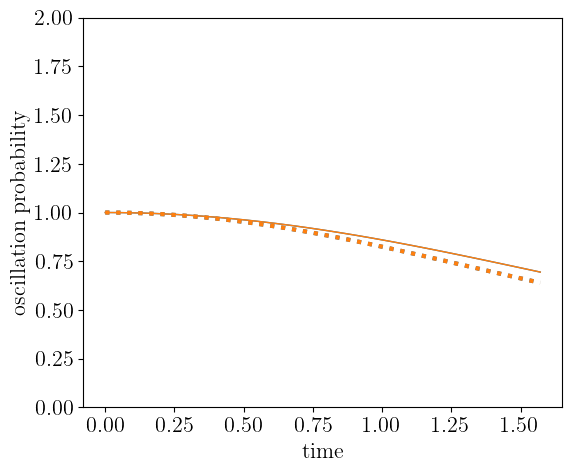

In [498]:
t_table          = np.linspace(0, t_max, 80)
psi0             = np.array([1.] + [0.]*(2**sum(nq)-1)) # initial state for the full system
psi0_eff         = np.array([1.] + [0.]*3)              # initial state for the effective system
psiout_table     = psi_out(psi0,     t_table, H(nq, theta, Delta, J))
psiout_eff_table = psi_out(psi0_eff, t_table, H_eff(a_eff_opt))

my_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
fig = plt.figure(figsize=(6,5))
k = 0
for j in range(2):
    plt.plot(t_table, prob_0(psiout_table,     k+np.arange(nq[j])), color=my_colors[j], ls='-', lw=1)
    plt.plot(t_table, prob_0(psiout_eff_table, [j]),                color=my_colors[j], ls=':', lw=3)
    k = k + nq[j]
plt.xlabel('time')
plt.ylabel('oscillation probability')
plt.ylim(0,2)
plt.tight_layout()
plt.show()